# CSE 4836 - Pattern Recognition Lab 03


# Introduction

# Ran Locally due to Cuda errors and dataset download issues

In this lab, you will investigate what fully connected neural networks learn on CIFAR-10 and how gradients move through those networks. You will begin with the single class templates learned by a linear classifier, inspect hidden-neuron features across neural-network layers, compare networks with different depth and width, visualize backpropagation through a small computation graph, and diagnose gradient flow in real CIFAR-10 networks.

Most training, data-loading, and plotting code is provided. Your code changes are intentionally small. Your main responsibility is to run controlled experiments, inspect the generated visualizations, and explain what evidence they provide about representations and optimization.


# Setup


In [1]:
from pathlib import Path

DATA_DIR = Path("datasets")
OUTPUT_DIR = Path("lab03_outputs")
CIFAR10_DIR = DATA_DIR / "cifar10"

print(f"Data directory: {CIFAR10_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Data directory: datasets/cifar10
Output directory: lab03_outputs


# Import Libraries and Configure the Experiment


In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms

from IPython.display import Image, display
from torch.nn import Module
from torch.utils.data import DataLoader, Subset
from torchviz import make_dot
from torchvision.datasets import ImageFolder

GLOBAL_SEED = 0
CIFAR10_CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


/mnt/Work/Environments/Ubuntu/Conda/envs/ml/lib/python3.11/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda


# Shared CIFAR-10 Components

These components follow the same interfaces used in Lab 02. `LinearClassifier` produces one score per class, `AccuracyAnalyzer` evaluates predictions, and `run_gradient_descent_optimizer` performs the repeated training steps. The helpers are provided so later cells can focus on model behavior rather than boilerplate.


## Reproducibility Helpers

`set_seed` controls Python, NumPy, CPU, CUDA, and data-loader randomness so controlled comparisons can be repeated.

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = False
    torch.use_deterministic_algorithms(False)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    random.seed(worker_seed)
    np.random.seed(worker_seed)


## `LinearClassifier`

`LinearClassifier` flattens each image and produces one class score from one learned weight template per class.

In [4]:
class LinearClassifier(Module):
    def __init__(self, n_features, n_classes, sigma=0.01):
        super().__init__()

        self.n_features = n_features
        self.n_classes = n_classes

        self.w = nn.Parameter(torch.randn(n_classes, n_features) * sigma)
        self.b = nn.Parameter(torch.zeros(n_classes))

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return x @ self.w.T + self.b

## Analyzer Classes

`ModelPerformanceAnalyzer` collects predictions from a data loader. `AccuracyAnalyzer` computes the fraction of correct predictions.

In [5]:
class ModelPerformanceAnalyzer:
    def test(self, model, testloader, device):
        model.eval()

        y_true = []
        y_pred = []

        with torch.no_grad():
            for x, y in testloader:
                x = x.to(device)
                y = y.to(device)

                scores = model(x)
                y_hat = torch.argmax(scores, dim=-1)

                y_true.append(y.cpu())
                y_pred.append(y_hat.cpu())

        y_true = torch.cat(y_true)
        y_pred = torch.cat(y_pred)

        return self.compute(y_true, y_pred)

    def compute(self, y_true, y_pred):
        raise NotImplementedError(f"{self.__class__.__name__}.compute() must be implemented")


class AccuracyAnalyzer(ModelPerformanceAnalyzer):
    def compute(self, y_true, y_pred):
        return (y_true == y_pred).float().mean().item()

## CIFAR-10 Loader

`load_cifar10` creates reproducible training and test loaders from the already-extracted local CIFAR-10 folder.


In [6]:
def load_cifar10(
    data_dir,
    batch_size,
    num_workers,
    seed,
    train_size=None,
    test_size=None,
):
    transform = transforms.ToTensor()
    generator = torch.Generator()
    generator.manual_seed(seed)

    dataset_dir = Path(data_dir) / "cifar10"
    train_dir = dataset_dir / "train"
    test_dir = dataset_dir / "test"

    if not train_dir.exists() or not test_dir.exists():
        raise FileNotFoundError(f"Expected CIFAR-10 ImageFolder data at {dataset_dir}")

    trainset = ImageFolder(root=train_dir, transform=transform)
    testset = ImageFolder(root=test_dir, transform=transform)

    if train_size is not None:
        trainset = Subset(trainset, range(min(train_size, len(trainset))))

    if test_size is not None:
        testset = Subset(testset, range(min(test_size, len(testset))))

    trainloader = DataLoader(
        trainset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=generator,
    )
    testloader = DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        worker_init_fn=seed_worker,
        generator=generator,
    )

    return trainloader, testloader


## Training Helper

`run_gradient_descent_optimizer` contains the repeated optimization boilerplate and returns the loss and test-accuracy history.

In [7]:
def run_gradient_descent_optimizer(
    model,
    trainloader,
    testloader,
    num_epochs,
    loss_fn,
    optimizer,
    analyzer,
    device,
):
    epoch_losses = []
    test_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            batch_loss = loss_fn(scores, y)

            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()

            epoch_loss += batch_loss.item()

        epoch_loss /= len(trainloader)
        test_accuracy = analyzer.test(model, testloader, device)

        epoch_losses.append(epoch_loss)
        test_accuracies.append(test_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs}: "
            f"loss={epoch_loss:.4f}, test_accuracy={test_accuracy:.4f}"
        )

    return epoch_losses, test_accuracies

## Linear-Classifier Visualizers

These helpers normalize learned weights for display and plot training history. Plotting remains separate from model computation.

In [8]:
def normalize_image_for_display(image):
    image = image - image.min()
    image = image / image.max().clamp_min(1e-8)
    return image


def visualize_linear_templates(model, class_names, output_file):
    templates = model.w.detach().cpu().reshape(len(class_names), 3, 32, 32)

    figure, axes = plt.subplots(2, 5, figsize=(15, 8), layout="constrained")

    for class_id, axis in enumerate(axes.flat):
        template = normalize_image_for_display(templates[class_id])
        template = template.permute(1, 2, 0)

        axis.imshow(template)
        axis.set_title(class_names[class_id])
        axis.axis("off")

    figure.suptitle("One Learned Linear Template per CIFAR-10 Class", fontsize=18)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)


def visualize_training_history(epoch_losses, test_accuracies, output_file):
    epochs = range(1, len(epoch_losses) + 1)
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, epoch_losses, marker="o")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].grid(alpha=0.25)

    axes[1].plot(epochs, test_accuracies, marker="o")
    axes[1].set_title("Test Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)

    figure.tight_layout()
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [9]:
set_seed(GLOBAL_SEED)
trainloader, testloader = load_cifar10(
    DATA_DIR,
    batch_size=512,
    num_workers=2,
    seed=GLOBAL_SEED,
)

# 01. Linear Classifier Templates

A linear classifier stores one weight vector for each CIFAR-10 class. Because each vector directly multiplies input pixels, it can be reshaped into a `3 x 32 x 32` image. The resulting image is one learned class template, not a collection of separate object-part detectors.

This section is a completed demonstration. Inspect the templates and use them as the baseline for the neural-network feature visualizations that follow.


## Prepare and Train the Linear Classifier


In [10]:
set_seed(GLOBAL_SEED)
linear_classifier = LinearClassifier(3 * 32 * 32, len(CIFAR10_CLASS_NAMES)).to(device)
linear_optimizer = torch.optim.SGD(
    linear_classifier.parameters(),
    lr=0.01,
    weight_decay=1e-4,
)
linear_losses, linear_accuracies = run_gradient_descent_optimizer(
    linear_classifier,
    trainloader,
    testloader,
    num_epochs=20,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=linear_optimizer,
    analyzer=AccuracyAnalyzer(),
    device=device,
)

Epoch 01/20: loss=2.1229, test_accuracy=0.2905
Epoch 02/20: loss=1.9768, test_accuracy=0.3261
Epoch 03/20: loss=1.9234, test_accuracy=0.3368
Epoch 04/20: loss=1.8908, test_accuracy=0.3451
Epoch 05/20: loss=1.8706, test_accuracy=0.3588
Epoch 06/20: loss=1.8540, test_accuracy=0.3579
Epoch 07/20: loss=1.8414, test_accuracy=0.3648
Epoch 08/20: loss=1.8323, test_accuracy=0.3644
Epoch 09/20: loss=1.8232, test_accuracy=0.3706
Epoch 10/20: loss=1.8160, test_accuracy=0.3779
Epoch 11/20: loss=1.8097, test_accuracy=0.3792
Epoch 12/20: loss=1.8045, test_accuracy=0.3770
Epoch 13/20: loss=1.7994, test_accuracy=0.3763
Epoch 14/20: loss=1.7954, test_accuracy=0.3780
Epoch 15/20: loss=1.7901, test_accuracy=0.3832
Epoch 16/20: loss=1.7868, test_accuracy=0.3838
Epoch 17/20: loss=1.7823, test_accuracy=0.3835
Epoch 18/20: loss=1.7793, test_accuracy=0.3823
Epoch 19/20: loss=1.7768, test_accuracy=0.3872
Epoch 20/20: loss=1.7743, test_accuracy=0.3906


## Analyze Results


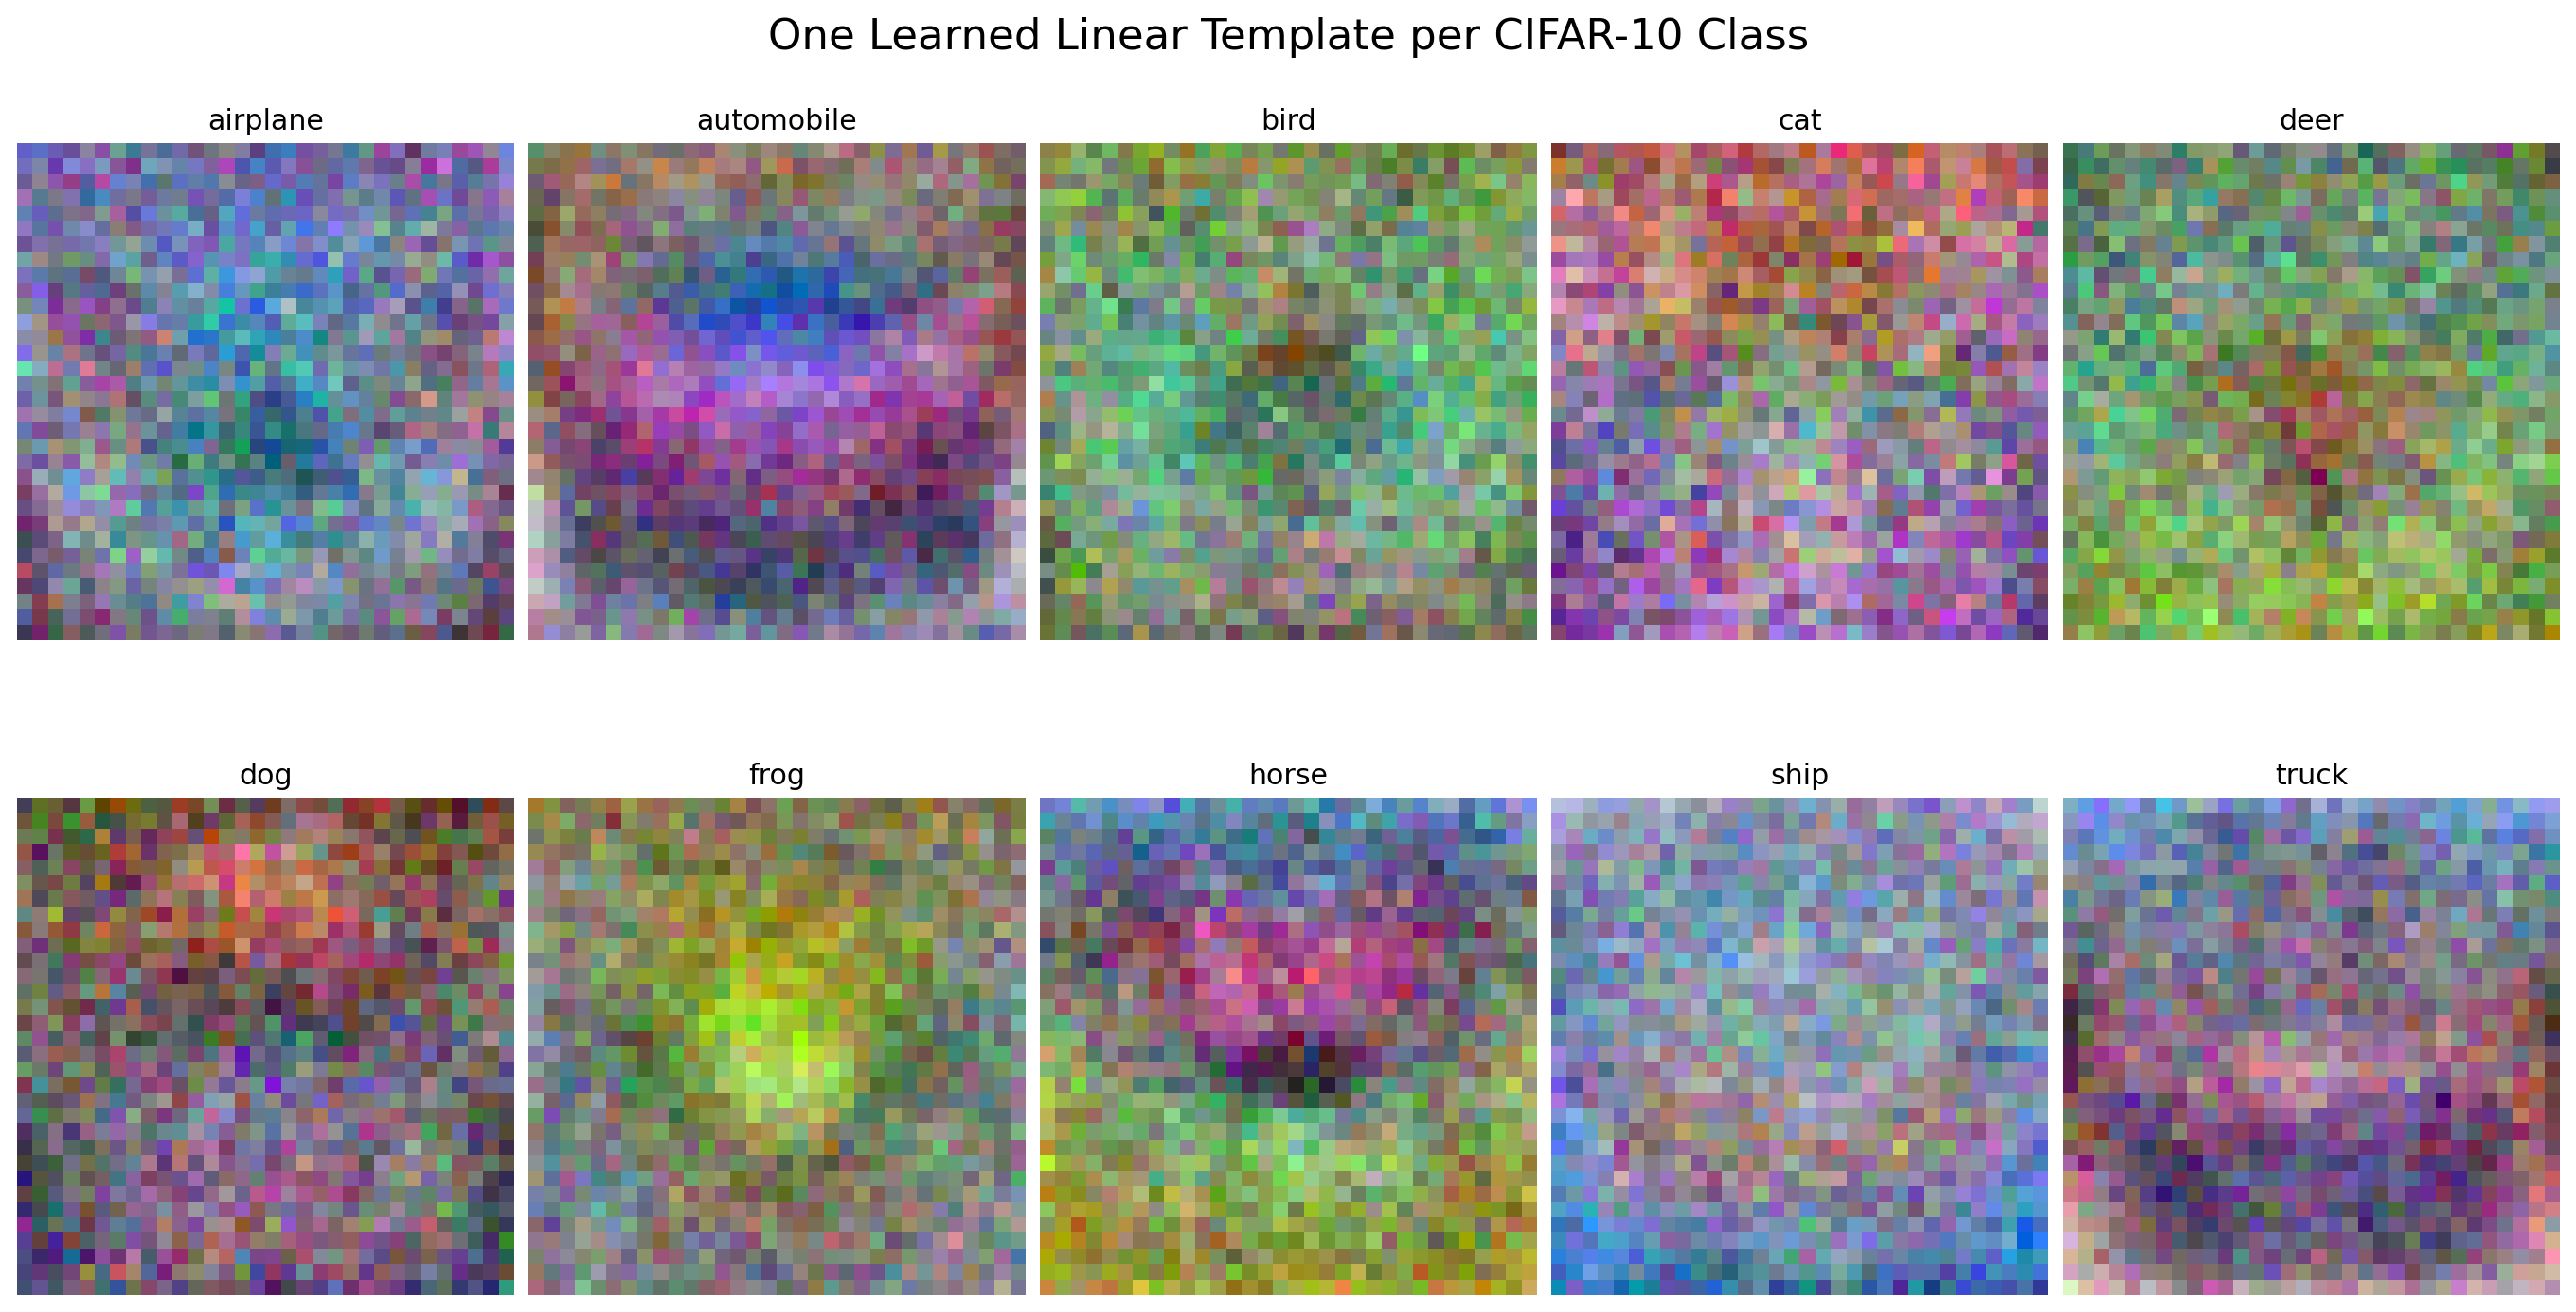

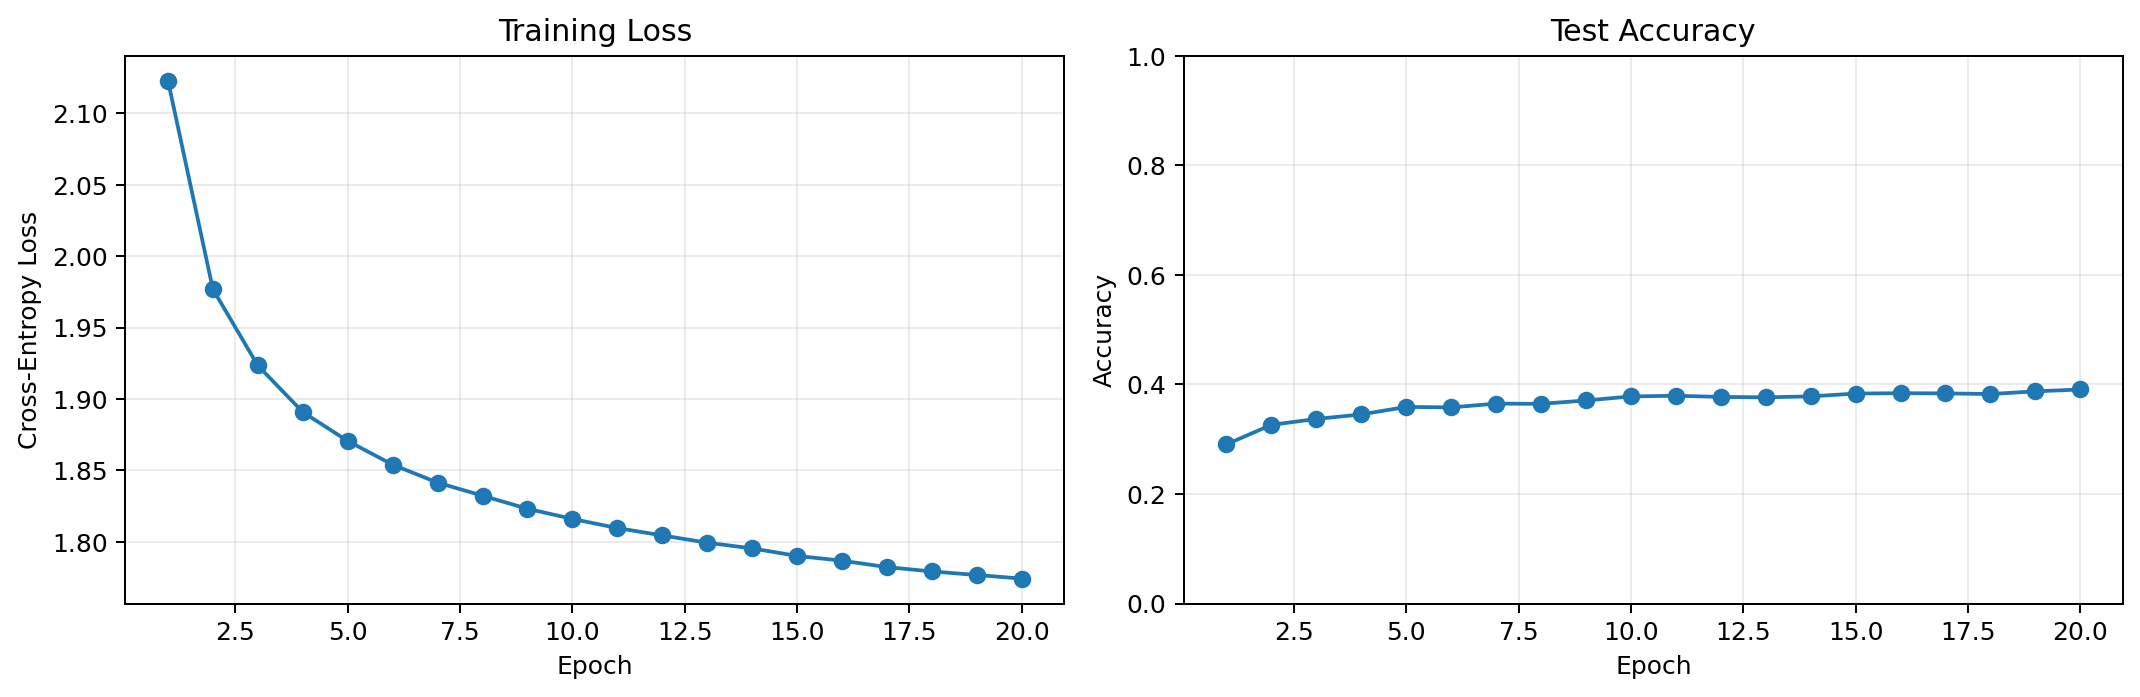

In [11]:
linear_output_dir = Path(OUTPUT_DIR) / "01_linear_classifier"
linear_output_dir.mkdir(parents=True, exist_ok=True)

visualize_linear_templates(
    linear_classifier,
    CIFAR10_CLASS_NAMES,
    linear_output_dir / "01_linear_class_templates.png",
)
visualize_training_history(
    linear_losses,
    linear_accuracies,
    linear_output_dir / "02_training_history.png",
)

display(Image(filename=linear_output_dir / "01_linear_class_templates.png"))
display(Image(filename=linear_output_dir / "02_training_history.png"))

# Task 01 Report

* Several templates show a dominant central structure with green backgrounds, which indicates that most of them are in greenish outdoor environment where objects are at center of the image.

* Linear classifier learns only one template per class, so it cannot represent variations in pose and background within the same class. Images of same class with varied poses or backgrounds may not match the single template well, which causes poor classification.

* The low approximate 40% accuracy shows that linear classifier can not successfully handle diverse images. Because linear models only learn one template, they cannot recognize objects in different poses or backgrounds from that template.

# 02. Layerwise Features in a Neural Network

`NeuralNetwork` composes several `LinearClassifier` layers with ReLU activations. A first-layer neuron's weights still connect directly to pixels and can therefore be reshaped into an image. Deeper-layer weights connect to earlier neurons instead of pixels, so their behavior is visualized using the CIFAR-10 images that activate them most strongly.

`LayerActivationCollector` uses a forward hook to save one layer's activations. The remaining helpers select high-variance neurons, retrieve their top-activating images, and summarize their average activation by class.


## `NeuralNetwork`

`NeuralNetwork` builds a fully connected network from a list of hidden-layer sizes and applies ReLU after every hidden layer.

In [12]:
class NeuralNetwork(nn.Module):
    def __init__(self, n_features, n_classes, hidden_layer_sizes):
        super().__init__()

        layer_sizes = [n_features] + hidden_layer_sizes + [n_classes]

        self.layers = nn.ModuleList()
        for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
            self.layers.append(LinearClassifier(in_size, out_size))

    def forward(self, x):
        num_layers = len(self.layers)

        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i != num_layers - 1:
                x = torch.relu(x)

        return x


def unwrap_model(model):
    if isinstance(model, nn.DataParallel):
        return model.module
    return model

## `LayerActivationCollector`

`LayerActivationCollector` registers a forward hook on one layer and stores that layer's post-ReLU activations.

In [13]:
class LayerActivationCollector:
    def __init__(self, model, layer_id):
        self.activations = None
        layer = unwrap_model(model).layers[layer_id]
        self.handle = layer.register_forward_hook(self.save_activations)

    def save_activations(self, module, inputs, output):
        self.activations = torch.relu(output.detach())

    def remove(self):
        self.handle.remove()

## Neuron-Selection Helpers

These helpers select neurons with varied responses, retrieve their strongest activating images, and summarize their activation by class.

### `find_high_variance_neurons`

In [14]:
def find_high_variance_neurons(model, dataloader, layer_id, num_neurons, device):
    collector = LayerActivationCollector(model, layer_id)
    activation_sum = None
    activation_square_sum = None
    num_samples = 0

    model.eval()
    with torch.no_grad():
        for x, _ in dataloader:
            model(x.to(device, non_blocking=True))
            activations = collector.activations

            batch_sum = activations.sum(dim=0).cpu()
            batch_square_sum = activations.square().sum(dim=0).cpu()

            if activation_sum is None:
                activation_sum = batch_sum
                activation_square_sum = batch_square_sum
            else:
                activation_sum += batch_sum
                activation_square_sum += batch_square_sum

            num_samples += activations.shape[0]

    collector.remove()

    activation_mean = activation_sum / num_samples
    activation_variance = activation_square_sum / num_samples - activation_mean.square()
    return torch.topk(activation_variance, num_neurons).indices.tolist()

### `collect_top_activating_images`

In [15]:
def validate_neuron_indices(model, layer_id, neuron_indices):
    model = unwrap_model(model)
    if layer_id < 0 or layer_id >= len(model.layers):
        raise ValueError(f"Layer {layer_id} is out of range for {len(model.layers)} layers")

    layer_width = model.layers[layer_id].n_classes
    invalid_indices = [index for index in neuron_indices if index < 0 or index >= layer_width]
    if invalid_indices:
        raise ValueError(
            f"Invalid neuron indices for layer {layer_id}: {invalid_indices}. "
            f"Layer {layer_id} has {layer_width} units, so valid indices are 0 to {layer_width - 1}."
        )


def collect_top_activating_images(
    model,
    dataloader,
    layer_id,
    neuron_indices,
    num_images,
    device,
):
    validate_neuron_indices(model, layer_id, neuron_indices)
    collector = LayerActivationCollector(model, layer_id)
    neuron_indices_device = torch.tensor(neuron_indices, device=device, dtype=torch.long)

    top_scores = {
        neuron_id: torch.empty(0)
        for neuron_id in neuron_indices
    }
    top_images = {
        neuron_id: torch.empty(0, 3, 32, 32)
        for neuron_id in neuron_indices
    }
    top_labels = {
        neuron_id: torch.empty(0, dtype=torch.long)
        for neuron_id in neuron_indices
    }

    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x_device = x.to(device, non_blocking=True)
            model(x_device)
            activations = collector.activations.index_select(1, neuron_indices_device).cpu()

            for column, neuron_id in enumerate(neuron_indices):
                scores = torch.cat([top_scores[neuron_id], activations[:, column]])
                images = torch.cat([top_images[neuron_id], x])
                labels = torch.cat([top_labels[neuron_id], y])

                keep = min(num_images, len(scores))
                selected = torch.topk(scores, keep).indices

                top_scores[neuron_id] = scores[selected]
                top_images[neuron_id] = images[selected]
                top_labels[neuron_id] = labels[selected]

    collector.remove()
    return top_images, top_labels, top_scores


### `collect_class_activation_profiles`

In [16]:
def collect_class_activation_profiles(
    model,
    dataloader,
    layer_id,
    neuron_indices,
    num_classes,
    device,
):
    validate_neuron_indices(model, layer_id, neuron_indices)
    collector = LayerActivationCollector(model, layer_id)
    neuron_indices_device = torch.tensor(neuron_indices, device=device)
    class_activation_sums = torch.zeros(len(neuron_indices), num_classes)
    class_counts = torch.zeros(num_classes)

    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            model(x.to(device, non_blocking=True))
            activations = collector.activations.index_select(1, neuron_indices_device).cpu()

            for class_id in range(num_classes):
                mask = y == class_id
                if mask.any():
                    class_activation_sums[:, class_id] += activations[mask].sum(dim=0)
                    class_counts[class_id] += mask.sum()

    collector.remove()
    return class_activation_sums / class_counts.clamp_min(1)

## Layerwise Feature Visualizers

First-layer weights can be reshaped into input images. Deeper layers are visualized through top-activating dataset images and class-activation profiles.

### `visualize_first_layer_features`

In [17]:
def visualize_first_layer_features(
    model,
    neuron_indices,
    top_images,
    top_labels,
    top_scores,
    class_names,
    output_file,
):
    model = unwrap_model(model)
    num_neurons = len(neuron_indices)
    num_images = len(next(iter(top_images.values())))
    figure, axes = plt.subplots(
        num_neurons,
        num_images + 1,
        figsize=(2.3 * (num_images + 1), 2.3 * num_neurons),
        layout="constrained",
    )
    axes = np.asarray(axes, dtype=object).reshape(num_neurons, num_images + 1)

    for row, neuron_id in enumerate(neuron_indices):
        weight_image = model.layers[0].w[neuron_id].detach().cpu().reshape(3, 32, 32)
        weight_image = normalize_image_for_display(weight_image).permute(1, 2, 0)

        axes[row, 0].imshow(weight_image)
        axes[row, 0].set_ylabel(f"Neuron {neuron_id}", fontsize=11)
        axes[row, 0].set_title("Input weights" if row == 0 else "")
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        for column in range(num_images):
            image = top_images[neuron_id][column].permute(1, 2, 0)
            label = class_names[top_labels[neuron_id][column].item()]
            score = top_scores[neuron_id][column].item()

            axes[row, column + 1].imshow(image)
            axes[row, column + 1].set_title(f"{label}\n{score:.1f}", fontsize=9)
            axes[row, column + 1].axis("off")

    figure.suptitle("First Hidden Layer: Learned Input Features and Top Activating Images", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_top_activating_images`

In [18]:
def visualize_top_activating_images(
    layer_id,
    neuron_indices,
    top_images,
    top_labels,
    top_scores,
    class_names,
    output_file,
    title_prefix=None,
):
    num_neurons = len(neuron_indices)
    num_images = len(next(iter(top_images.values())))
    figure, axes = plt.subplots(
        num_neurons,
        num_images,
        figsize=(2.2 * num_images, 2.2 * num_neurons),
        layout="constrained",
    )
    axes = np.asarray(axes, dtype=object).reshape(num_neurons, num_images)

    for row, neuron_id in enumerate(neuron_indices):
        for column in range(num_images):
            image = top_images[neuron_id][column].permute(1, 2, 0)
            label = class_names[top_labels[neuron_id][column].item()]
            score = top_scores[neuron_id][column].item()

            axes[row, column].imshow(image)
            axes[row, column].set_title(f"{label}\n{score:.1f}", fontsize=9)
            axes[row, column].axis("off")

        axes[row, 0].set_ylabel(f"Neuron {neuron_id}", fontsize=11)

    title = f"Hidden Layer {layer_id + 1}: Top Activating CIFAR-10 Images"
    if title_prefix is not None:
        title = f"{title_prefix}\n{title}"
    figure.suptitle(title, fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_class_activation_profiles`

In [19]:
def visualize_class_activation_profiles(
    layer_id,
    neuron_indices,
    class_activation_profiles,
    class_names,
    output_file,
    title_prefix=None,
):
    normalized_profiles = class_activation_profiles / class_activation_profiles.amax(
        dim=1,
        keepdim=True,
    ).clamp_min(1e-8)

    figure, axis = plt.subplots(
        figsize=(12, 0.65 * len(neuron_indices) + 2.5),
        layout="constrained",
    )
    image = axis.imshow(normalized_profiles, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

    axis.set_xticks(range(len(class_names)), labels=class_names, rotation=35, ha="right")
    axis.set_yticks(
        range(len(neuron_indices)),
        labels=[f"Neuron {neuron_id}" for neuron_id in neuron_indices],
    )
    title = f"Hidden Layer {layer_id + 1}: Mean Activation by CIFAR-10 Class"
    if title_prefix is not None:
        title = f"{title_prefix}\n{title}"
    axis.set_title(title)
    figure.colorbar(image, ax=axis, label="Activation relative to this neuron's maximum")

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

## Prepare and Train the Neural Network


In [20]:
set_seed(GLOBAL_SEED)
feature_model = NeuralNetwork(
    n_features=3 * 32 * 32,
    n_classes=len(CIFAR10_CLASS_NAMES),
    hidden_layer_sizes=[1024, 512, 256],
).to(device)
feature_optimizer = torch.optim.Adam(
    feature_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
feature_losses, feature_accuracies = run_gradient_descent_optimizer(
    feature_model,
    trainloader,
    testloader,
    num_epochs=30,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer=feature_optimizer,
    analyzer=AccuracyAnalyzer(),
    device=device,
)

Epoch 01/30: loss=2.0308, test_accuracy=0.3079
Epoch 02/30: loss=1.8388, test_accuracy=0.3594
Epoch 03/30: loss=1.7291, test_accuracy=0.3855
Epoch 04/30: loss=1.6557, test_accuracy=0.4048
Epoch 05/30: loss=1.6016, test_accuracy=0.4190
Epoch 06/30: loss=1.5562, test_accuracy=0.4377
Epoch 07/30: loss=1.5065, test_accuracy=0.4521
Epoch 08/30: loss=1.4813, test_accuracy=0.4516
Epoch 09/30: loss=1.4508, test_accuracy=0.4738
Epoch 10/30: loss=1.4233, test_accuracy=0.4756
Epoch 11/30: loss=1.4017, test_accuracy=0.4910
Epoch 12/30: loss=1.3800, test_accuracy=0.4909
Epoch 13/30: loss=1.3533, test_accuracy=0.4990
Epoch 14/30: loss=1.3417, test_accuracy=0.4969
Epoch 15/30: loss=1.3151, test_accuracy=0.4898
Epoch 16/30: loss=1.2988, test_accuracy=0.5119
Epoch 17/30: loss=1.2618, test_accuracy=0.5139
Epoch 18/30: loss=1.2464, test_accuracy=0.5194
Epoch 19/30: loss=1.2409, test_accuracy=0.5162
Epoch 20/30: loss=1.2219, test_accuracy=0.5050
Epoch 21/30: loss=1.2011, test_accuracy=0.5249
Epoch 22/30: 

## Layerwise Feature Visualization Helper


In [21]:
def analyze_hidden_layer(model, dataloader, layer_id, num_neurons=4, num_images=5):
    neuron_indices = find_high_variance_neurons(
        model, dataloader, layer_id, num_neurons, device
    )
    top_images, top_labels, top_scores = collect_top_activating_images(
        model, dataloader, layer_id, neuron_indices, num_images, device
    )
    profiles = collect_class_activation_profiles(
        model, dataloader, layer_id, neuron_indices, len(CIFAR10_CLASS_NAMES), device
    )

    output_dir = Path(OUTPUT_DIR) / "02_layerwise_features"
    output_dir.mkdir(parents=True, exist_ok=True)
    feature_file = output_dir / f"layer_{layer_id + 1:02d}_features.png"
    profile_file = output_dir / f"layer_{layer_id + 1:02d}_class_profiles.png"

    if layer_id == 0:
        visualize_first_layer_features(
            model, neuron_indices, top_images, top_labels, top_scores,
            CIFAR10_CLASS_NAMES, feature_file
        )
    else:
        visualize_top_activating_images(
            layer_id, neuron_indices, top_images, top_labels, top_scores,
            CIFAR10_CLASS_NAMES, feature_file
        )
    visualize_class_activation_profiles(
        layer_id, neuron_indices, profiles, CIFAR10_CLASS_NAMES, profile_file
    )

    display(Image(filename=feature_file))
    display(Image(filename=profile_file))

## Random Neuron Visualizer

`visualize_random_neurons` samples `(layer, neuron)` pairs from a trained fully connected network. For layer 0, it shows the neuron's input-weight template because those weights directly connect to pixels. For every sampled neuron, it also shows the CIFAR-10 images that activate that neuron most strongly.


In [22]:
def visualize_single_neuron(model, dataloader, layer_id, neuron_id, num_images=5):
    top_images, top_labels, top_scores = collect_top_activating_images(
        model,
        dataloader,
        layer_id,
        [neuron_id],
        num_images,
        device,
    )

    output_dir = Path(OUTPUT_DIR) / "02_layerwise_features" / "random_neurons"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / f"layer_{layer_id + 1:02d}_neuron_{neuron_id:04d}.png"

    if layer_id == 0:
        visualize_first_layer_features(
            model,
            [neuron_id],
            top_images,
            top_labels,
            top_scores,
            CIFAR10_CLASS_NAMES,
            output_file,
        )
    else:
        visualize_top_activating_images(
            layer_id,
            [neuron_id],
            top_images,
            top_labels,
            top_scores,
            CIFAR10_CLASS_NAMES,
            output_file,
            title_prefix=f"Random neuron: layer {layer_id + 1}, neuron {neuron_id}",
        )

    display(Image(filename=output_file))
    return output_file


def sample_random_neuron_pairs(model, num_neurons=3, seed=GLOBAL_SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)
    model = unwrap_model(model)
    hidden_layer_ids = list(range(len(model.layers) - 1))
    pairs = []

    for _ in range(num_neurons):
        layer_id = hidden_layer_ids[
            torch.randint(len(hidden_layer_ids), size=(1,), generator=generator).item()
        ]
        layer_width = model.layers[layer_id].n_classes
        neuron_id = torch.randint(layer_width, size=(1,), generator=generator).item()
        pairs.append((layer_id, neuron_id))

    return pairs


def visualize_random_neurons(model, dataloader, neuron_pairs=None, num_neurons=3, num_images=5, seed=GLOBAL_SEED):
    if neuron_pairs is None:
        neuron_pairs = sample_random_neuron_pairs(model, num_neurons=num_neurons, seed=seed)

    output_files = []
    for layer_id, neuron_id in neuron_pairs:
        print(f"Layer {layer_id + 1}, neuron {neuron_id}")
        output_files.append(
            visualize_single_neuron(
                model,
                dataloader,
                layer_id,
                neuron_id,
                num_images=num_images,
            )
        )

    return neuron_pairs, output_files


## Analyze Early and Late Hidden Layers


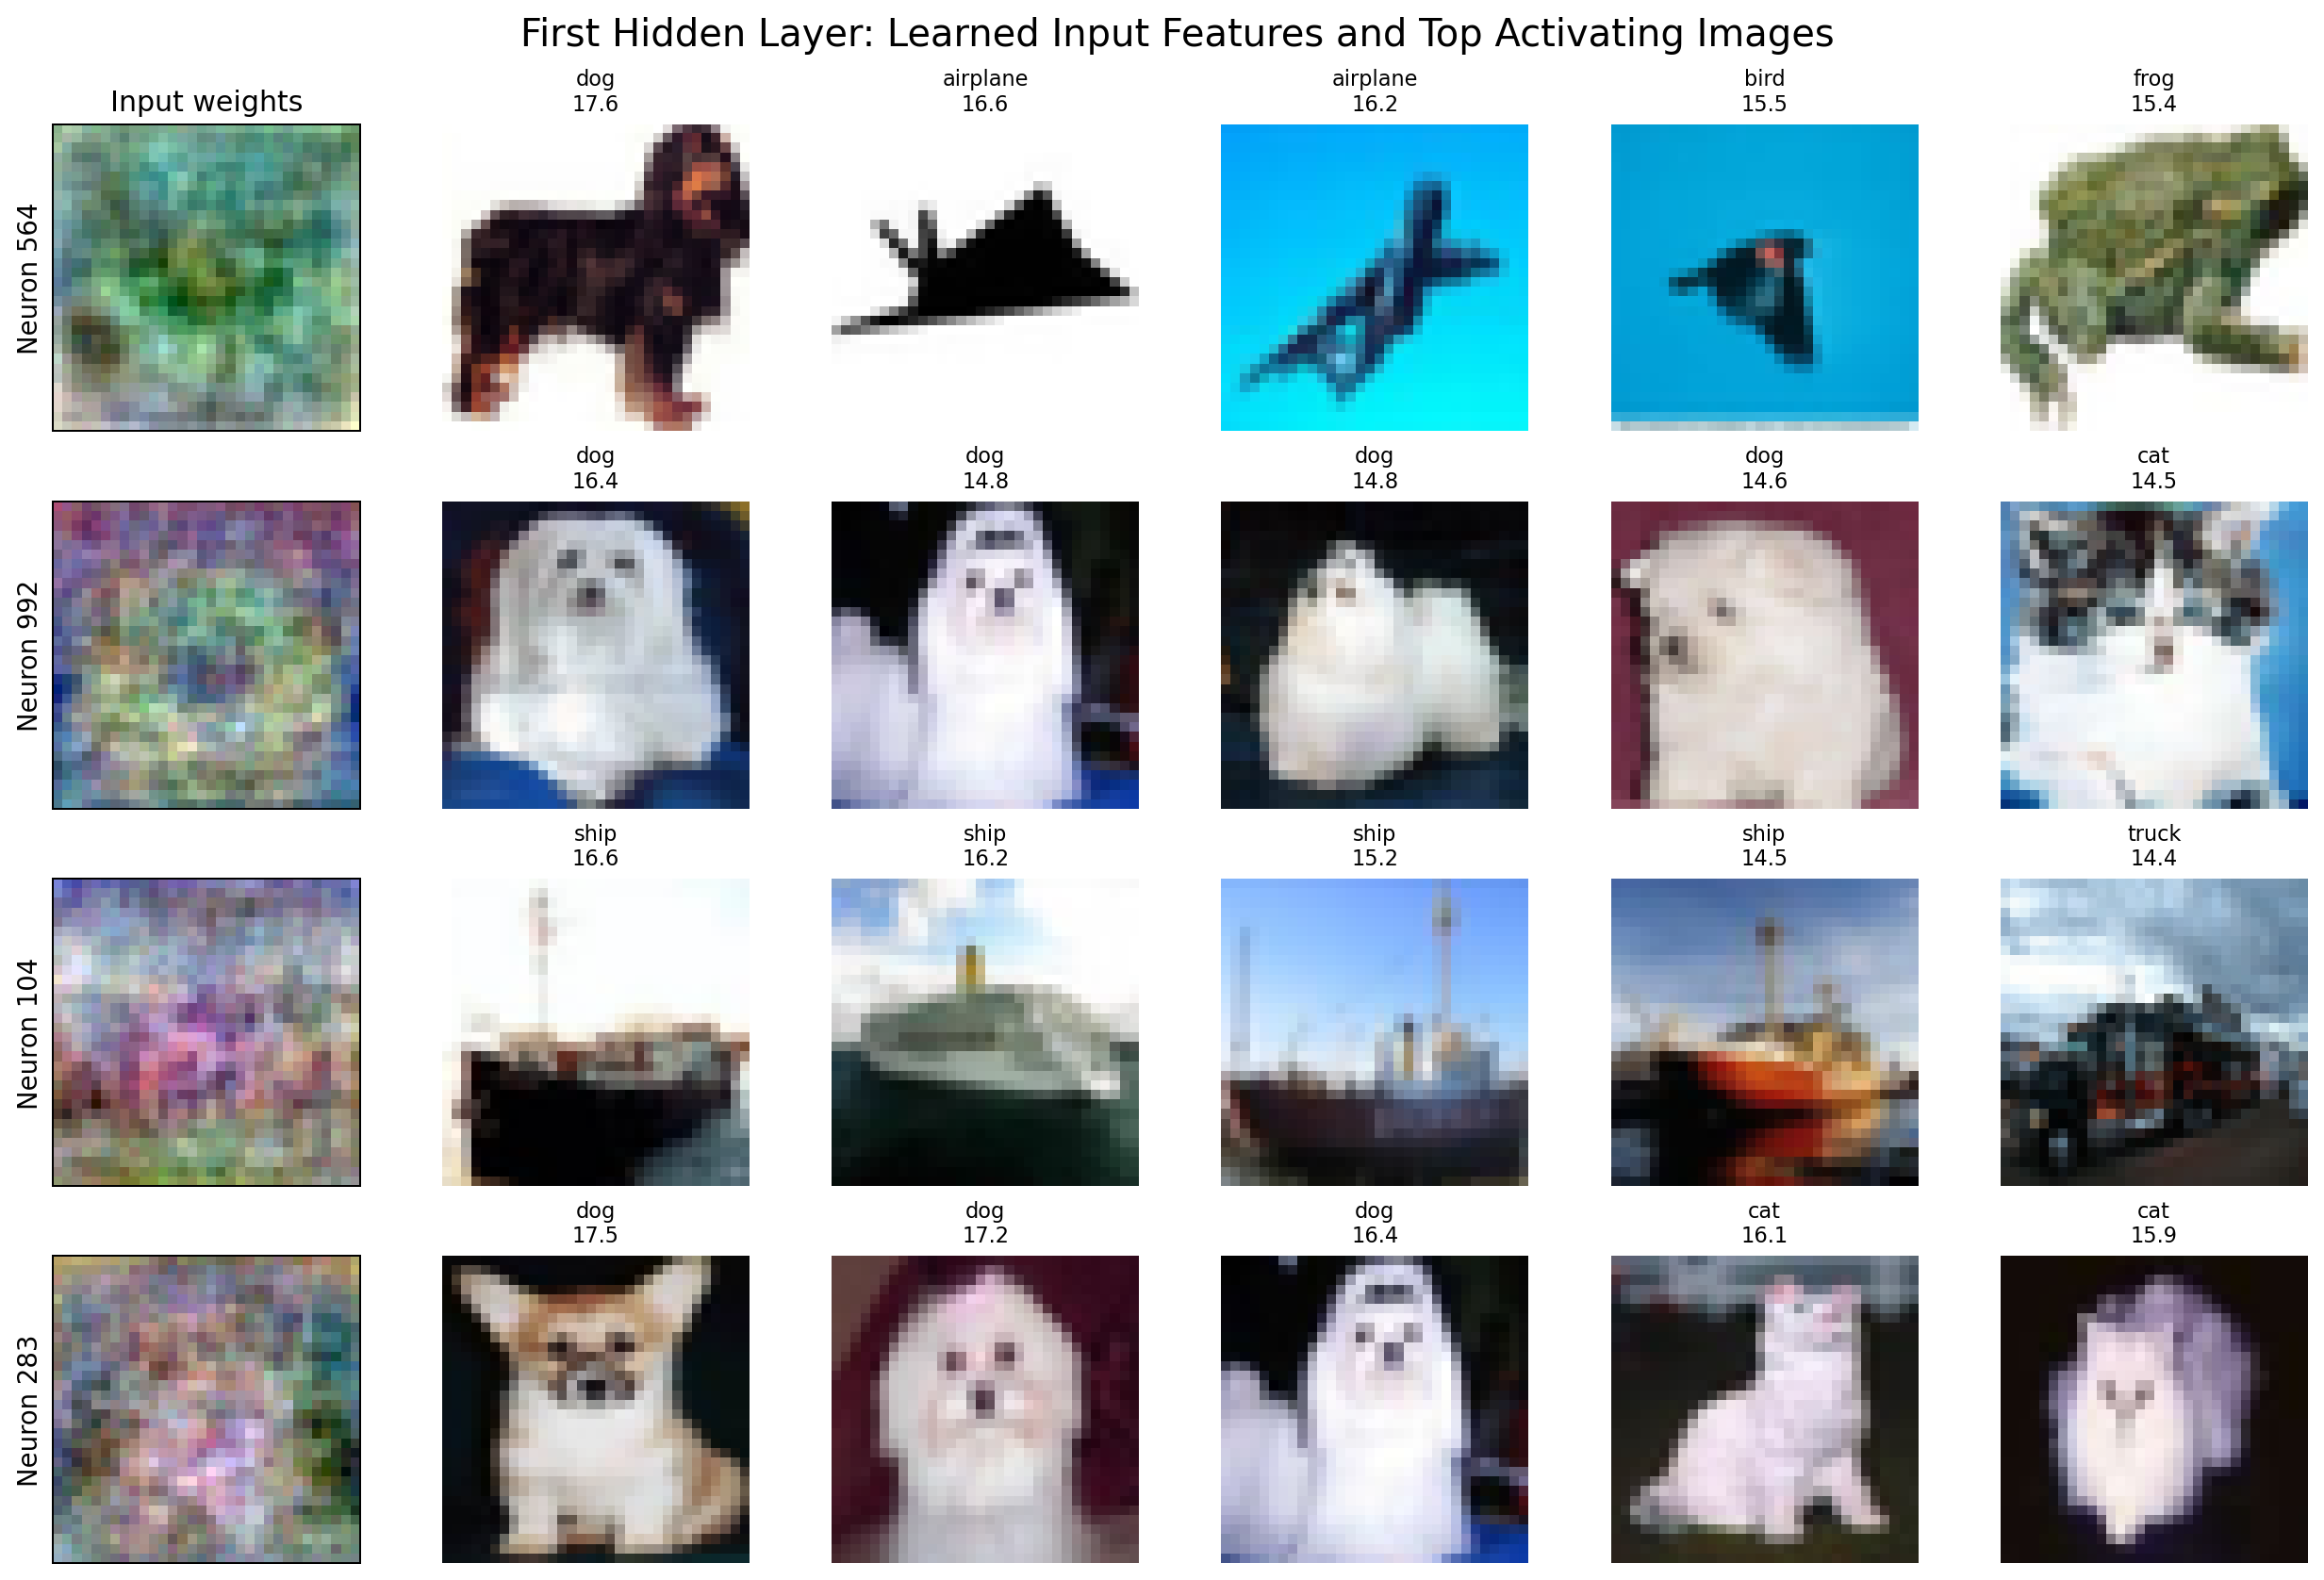

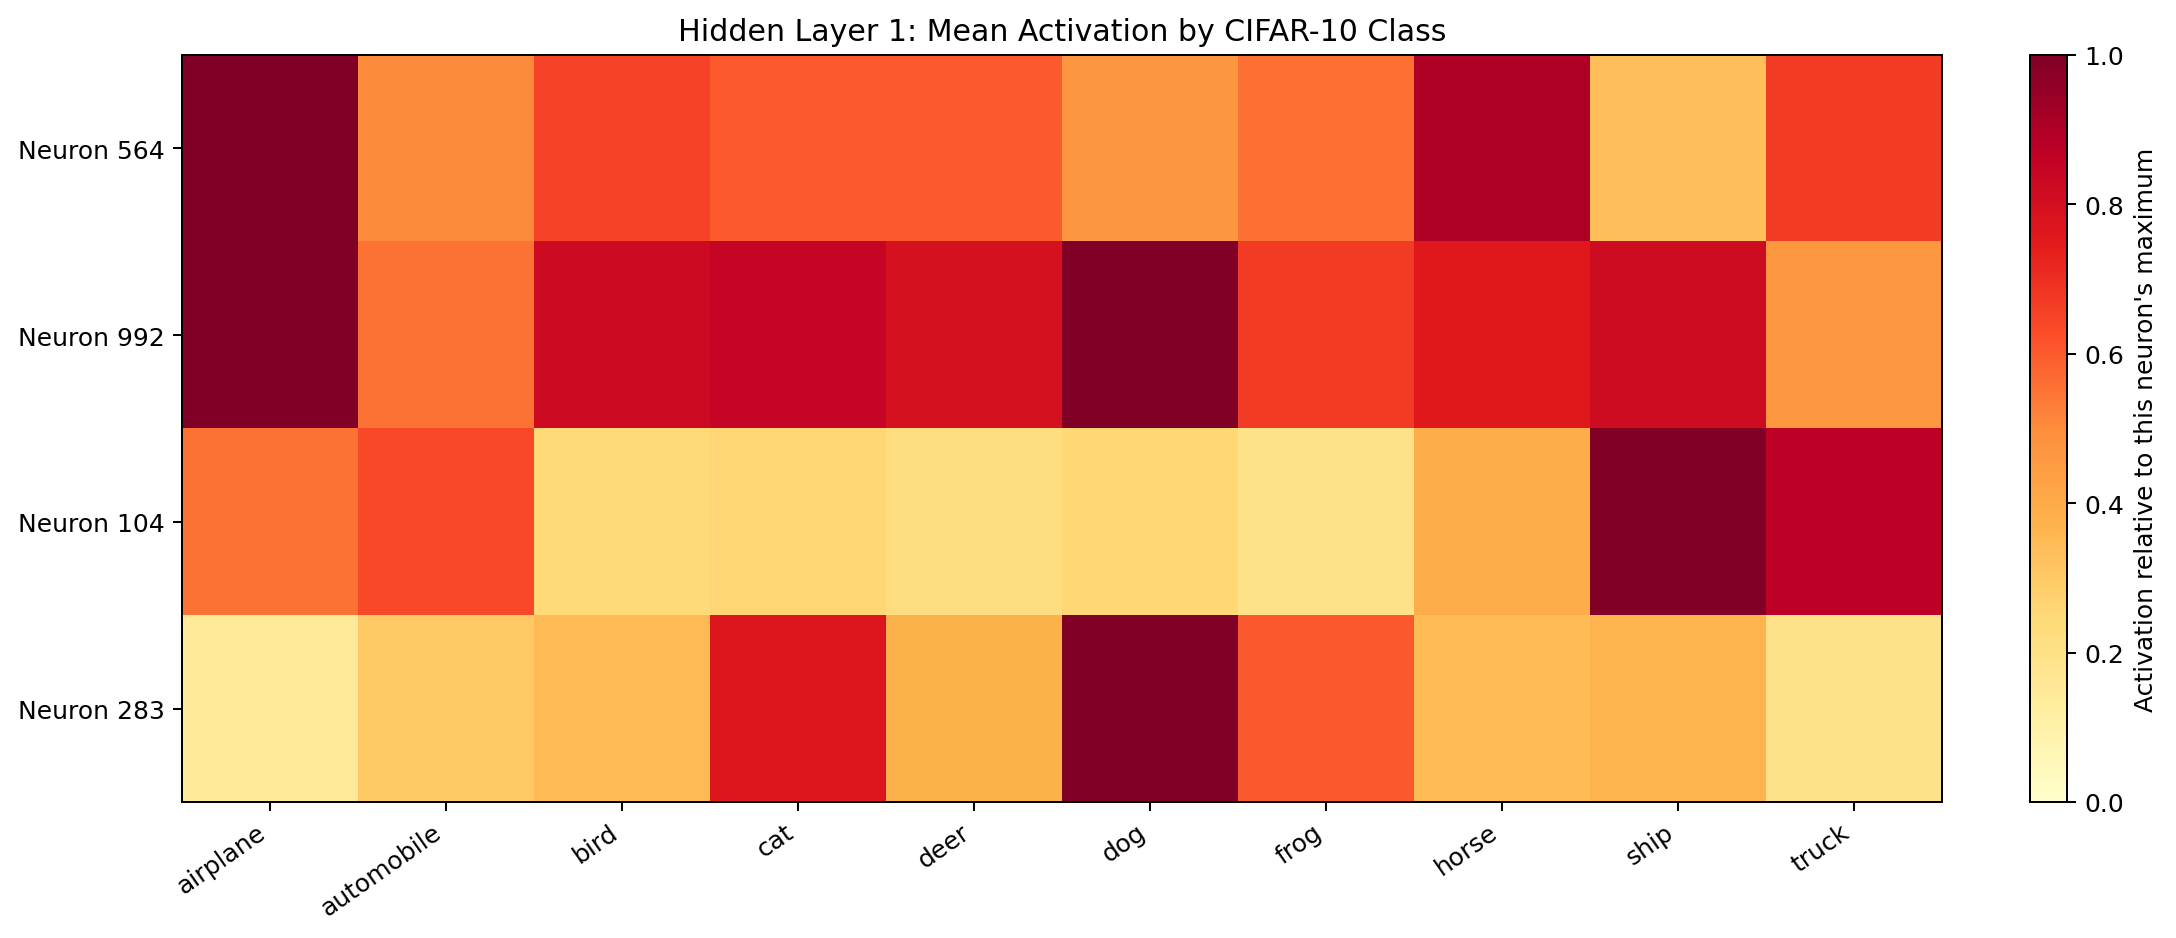

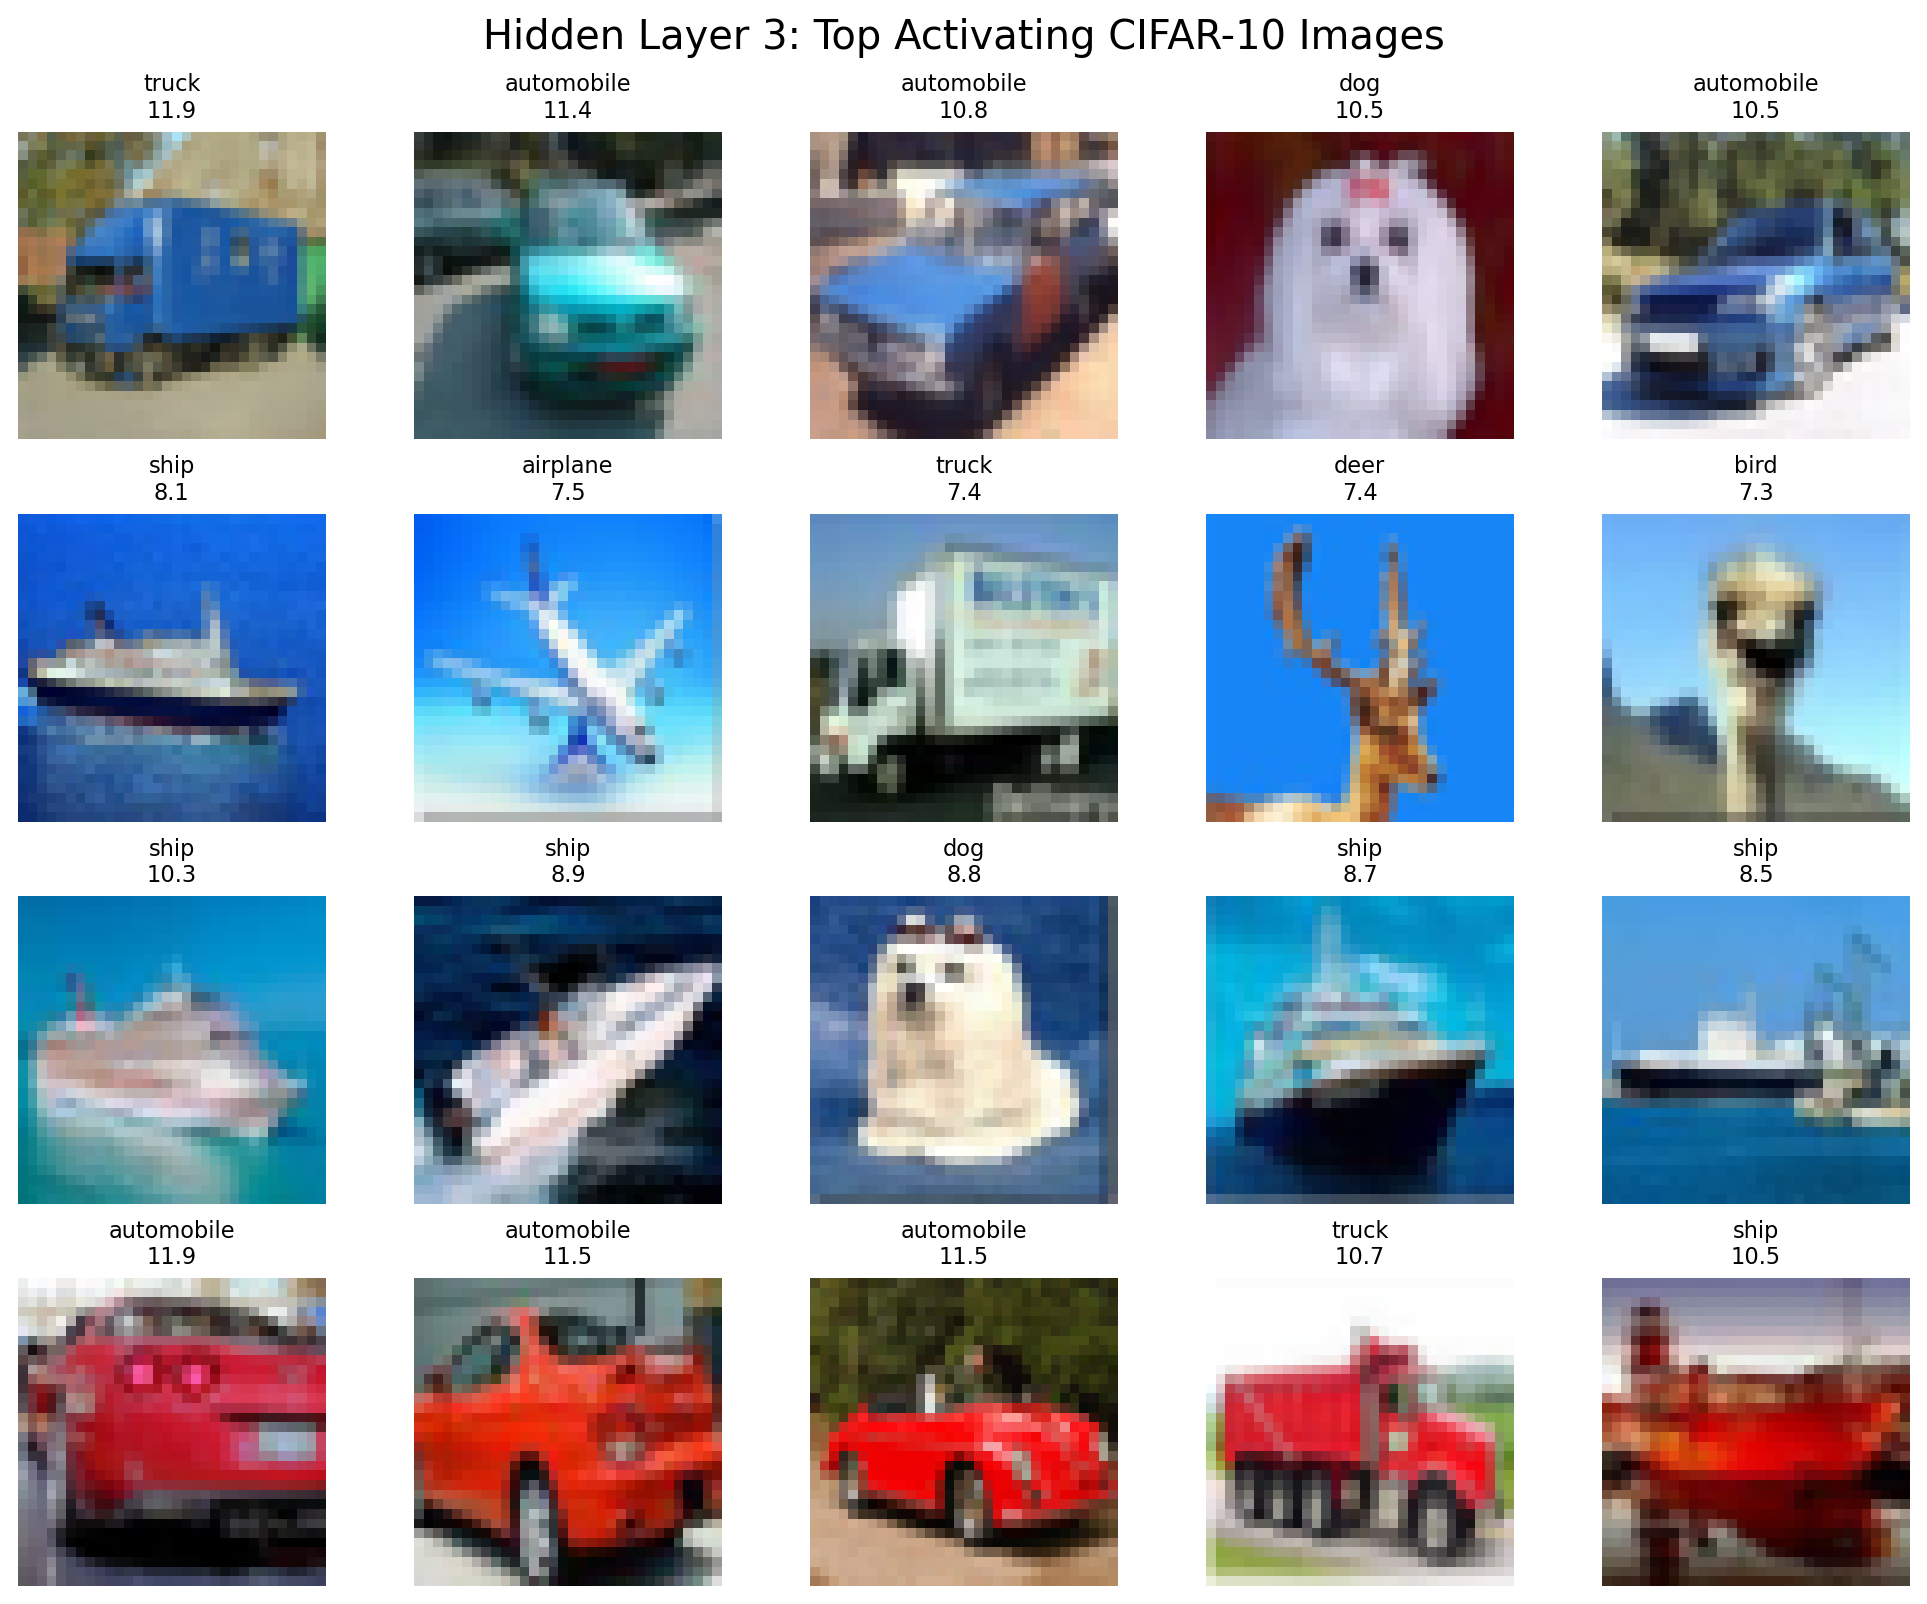

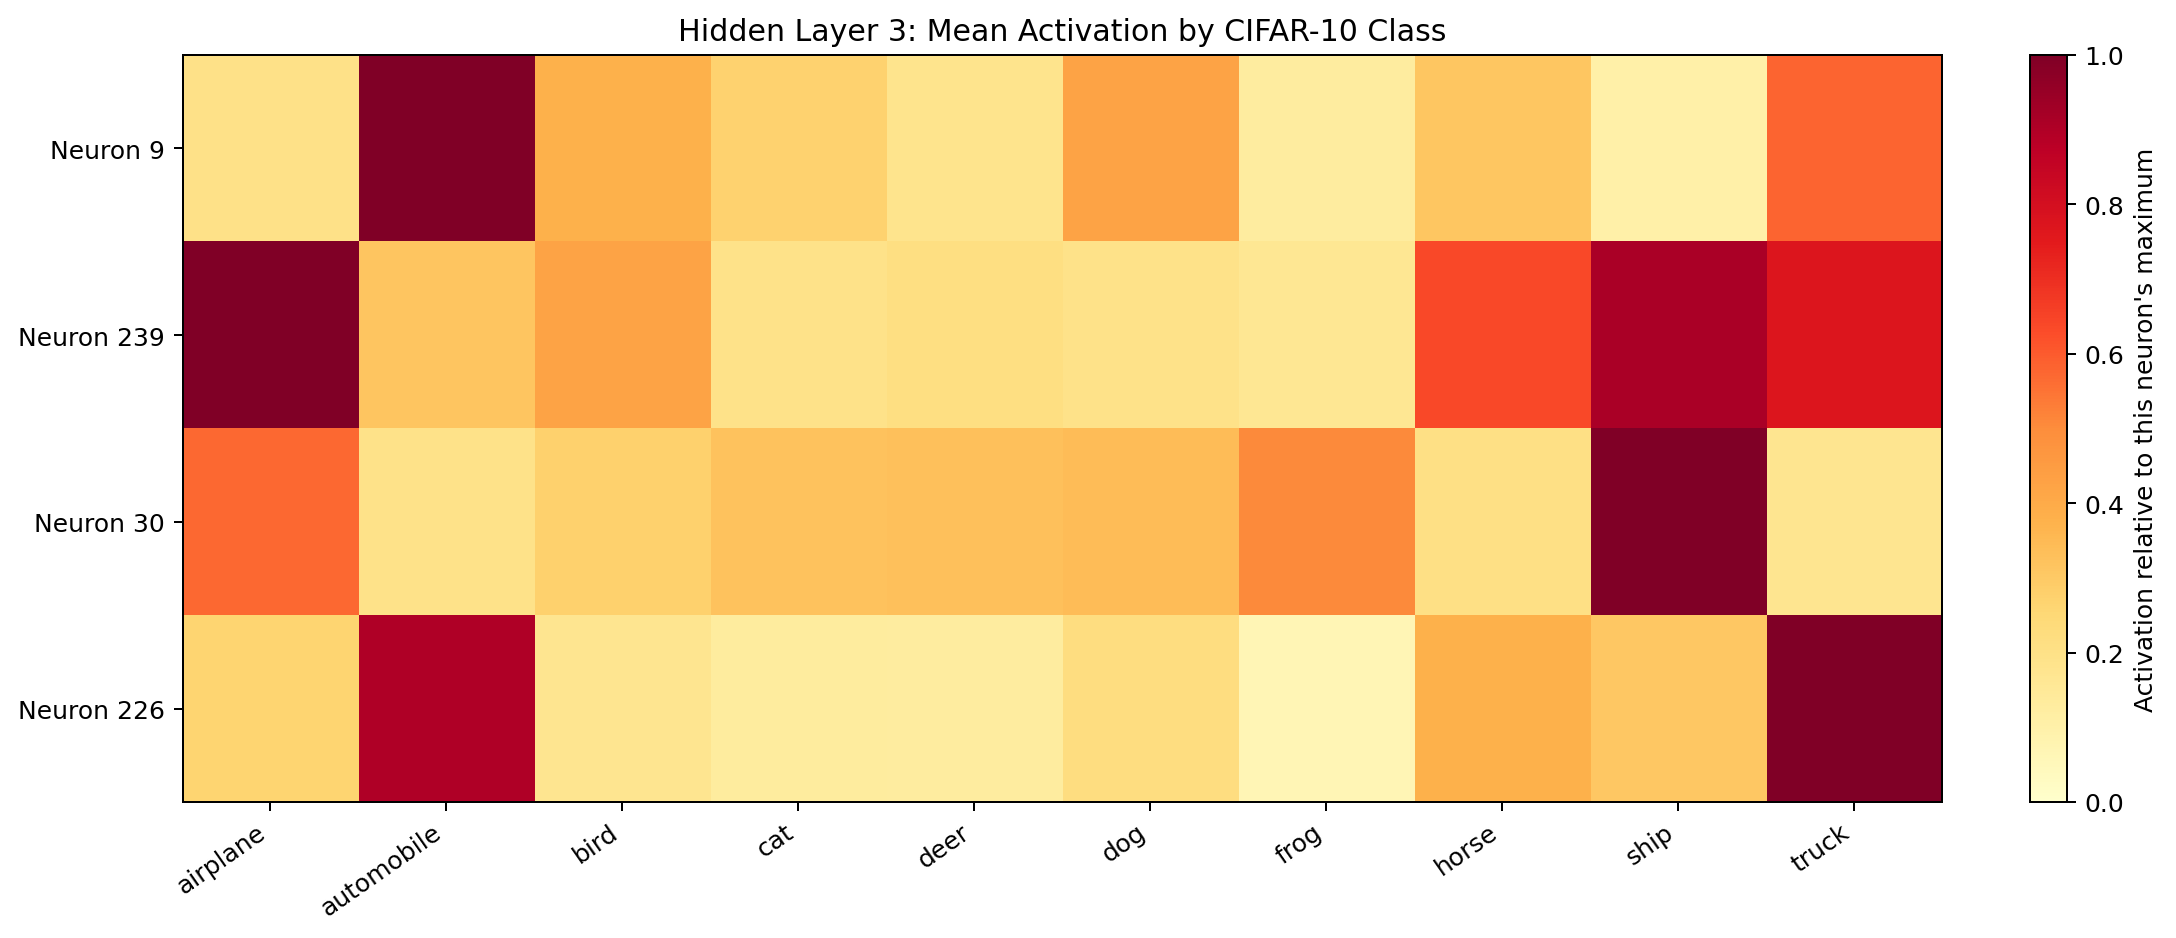

In [23]:
analyze_hidden_layer(feature_model, testloader, layer_id=0)
analyze_hidden_layer(feature_model, testloader, layer_id=2)

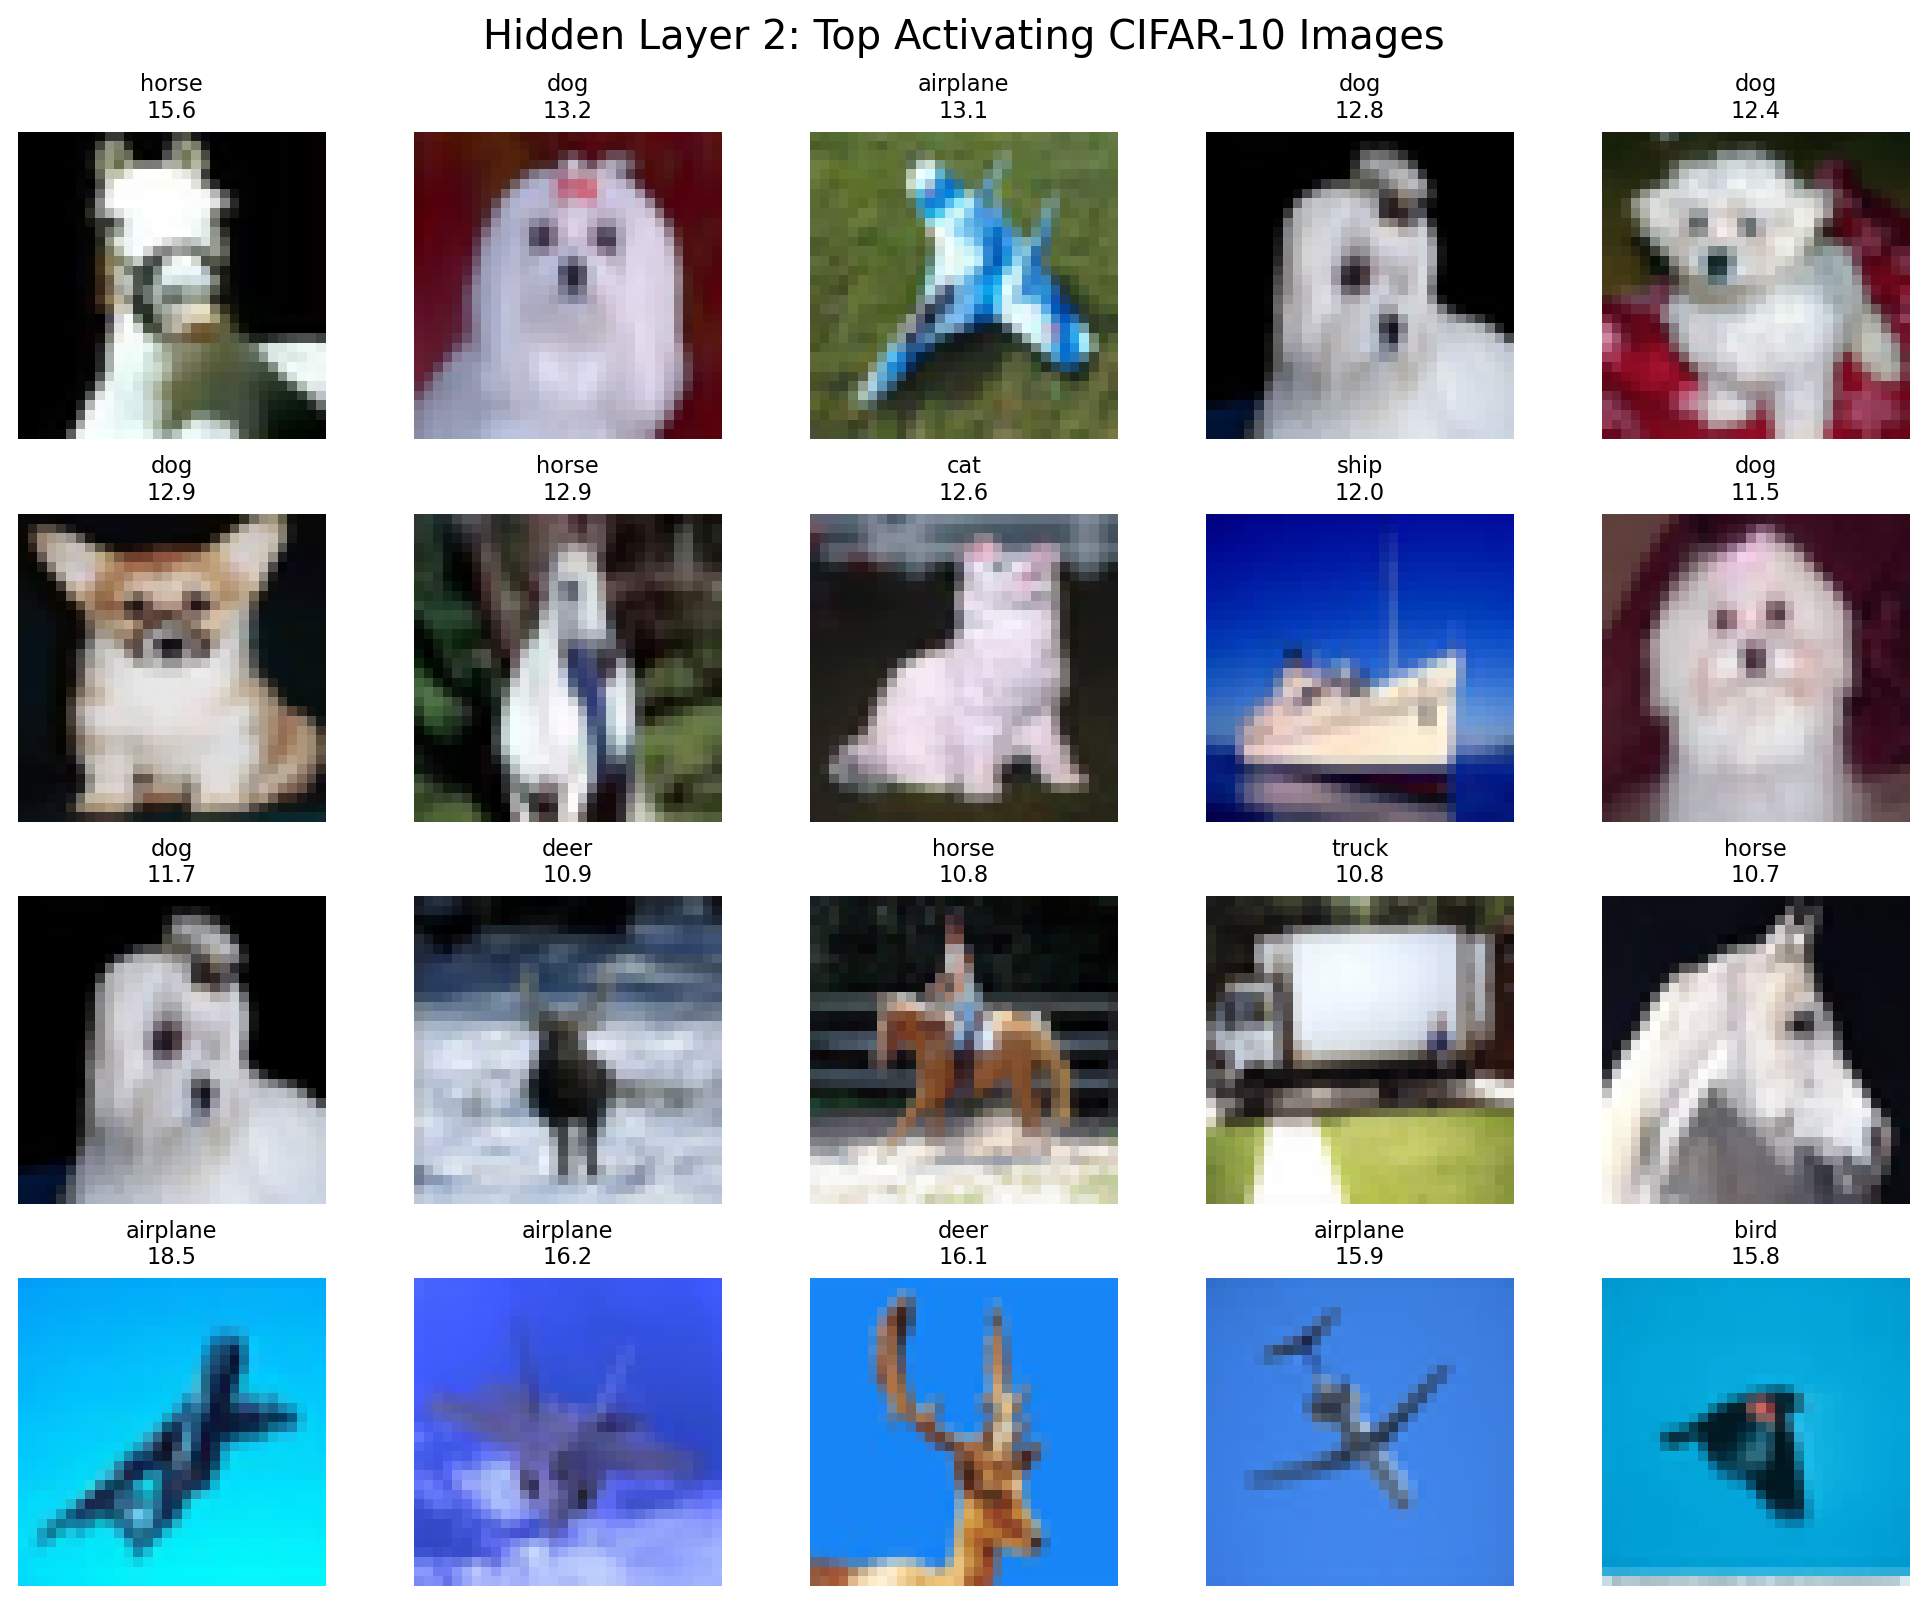

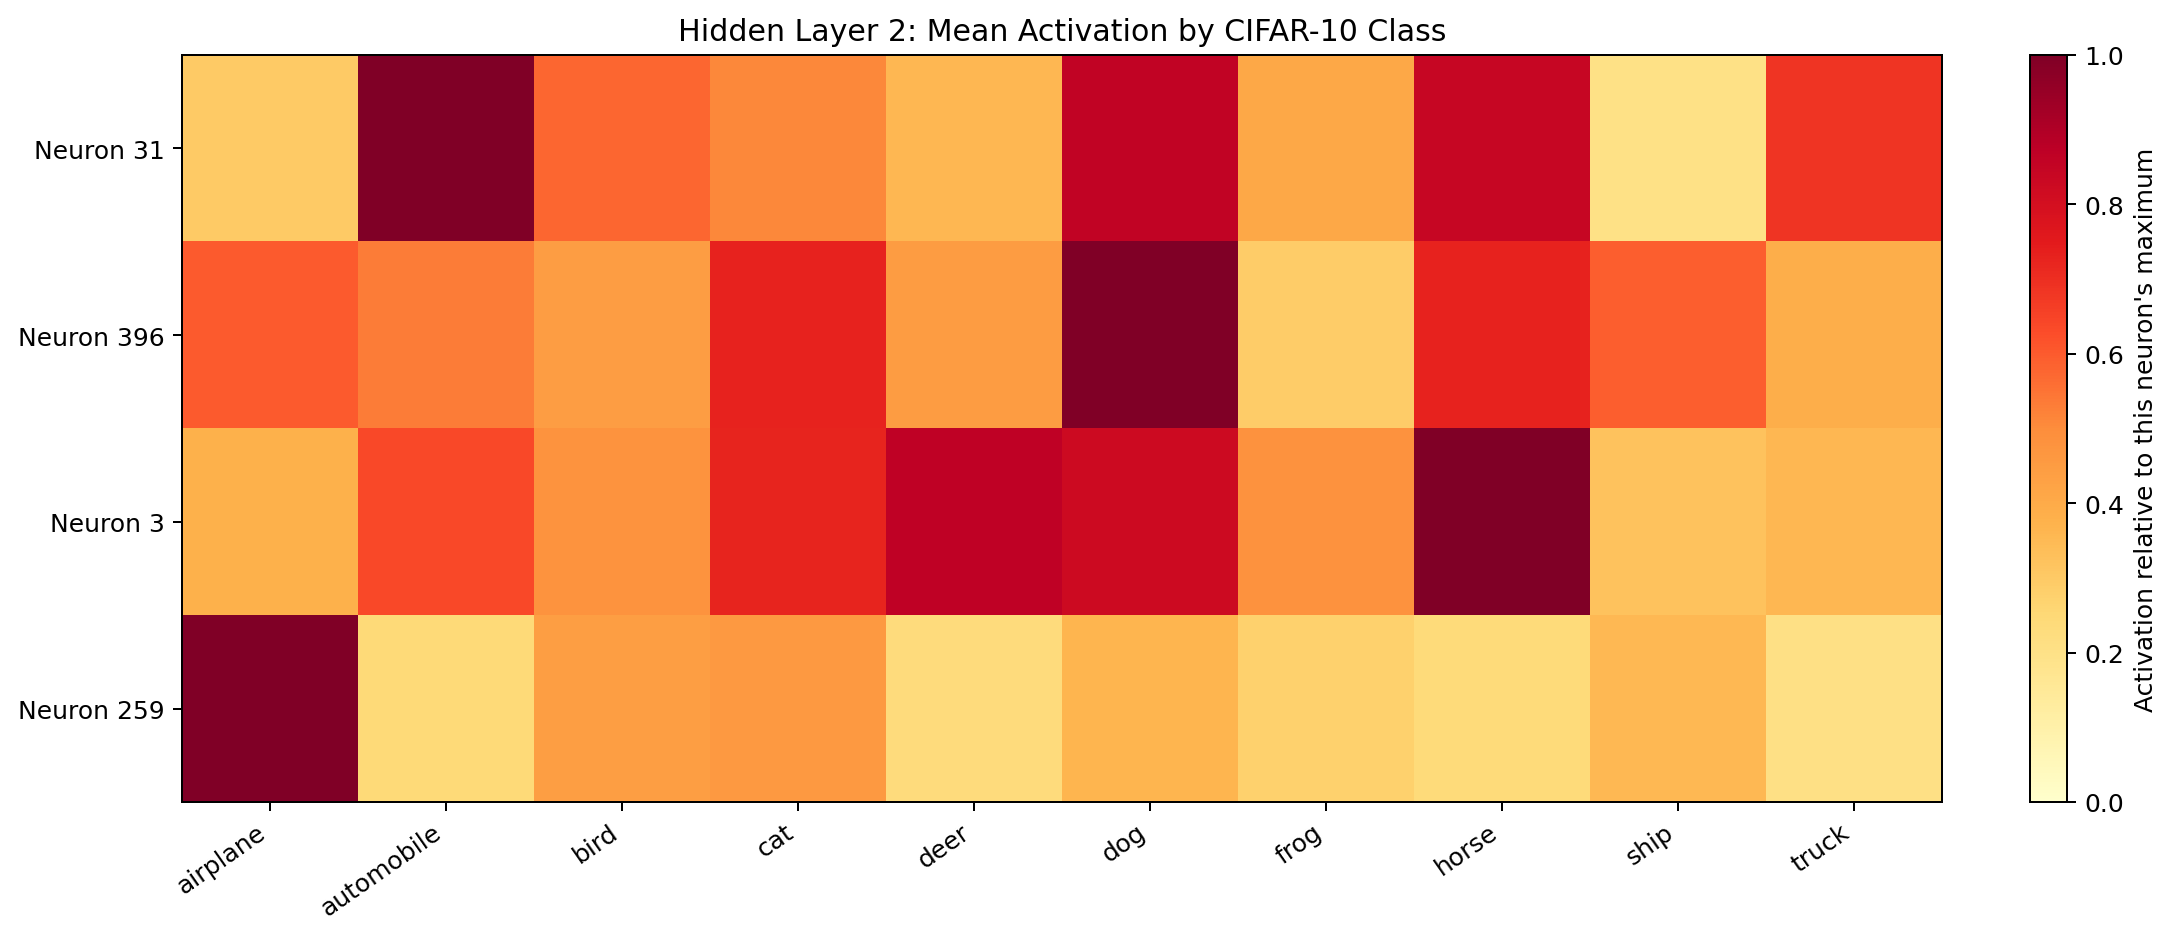

In [24]:
selected_layer_id = 1
analyze_hidden_layer(feature_model, testloader, selected_layer_id)

Layer 3, neuron 47


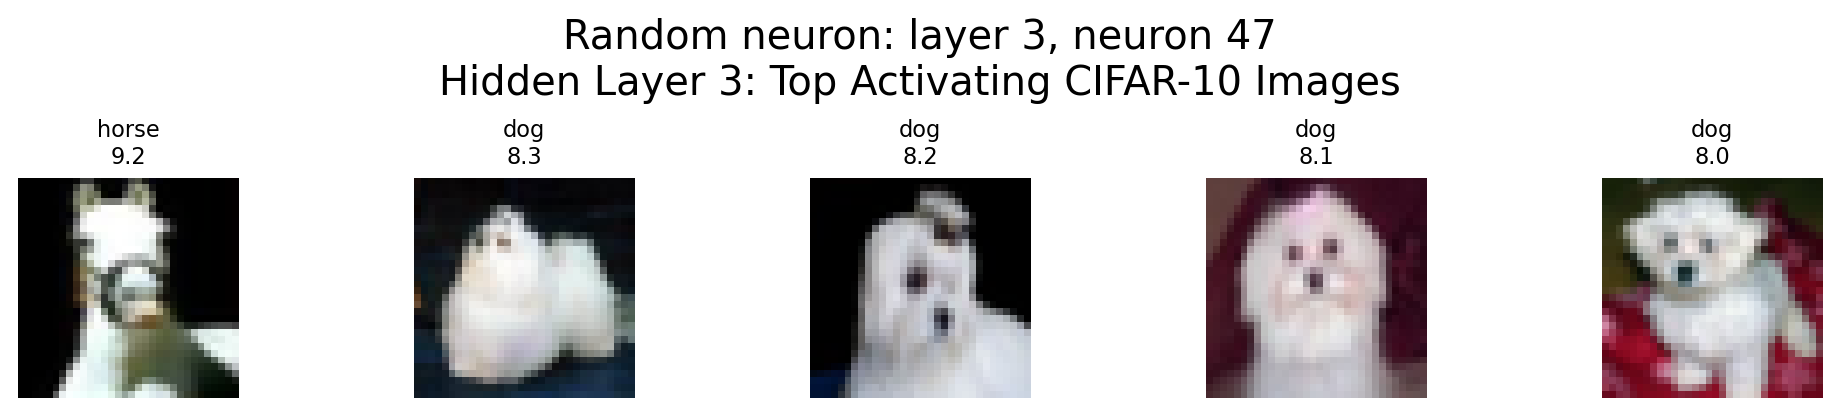

Layer 2, neuron 192


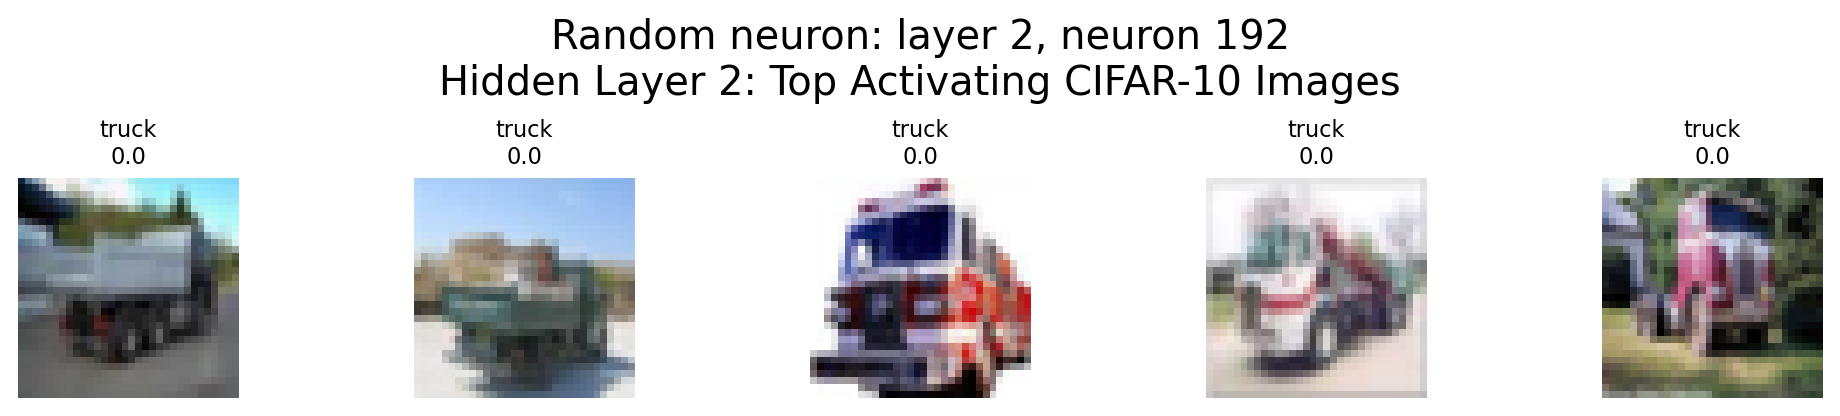

Layer 3, neuron 251


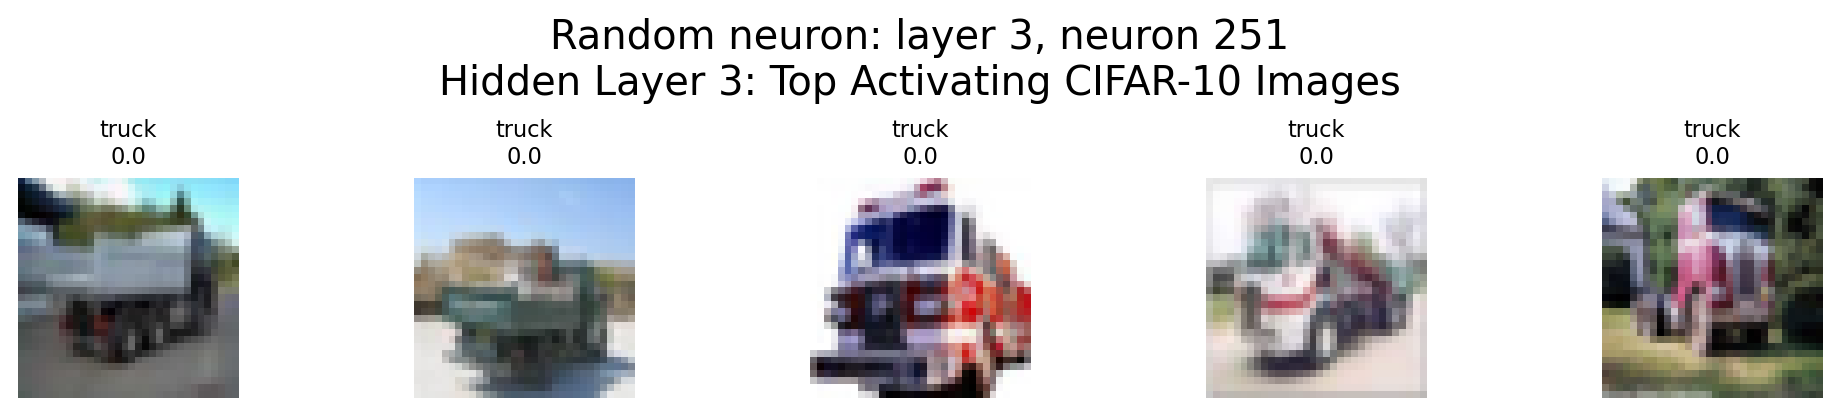

[(2, 47), (1, 192), (2, 251)]

In [25]:
random_neuron_pairs, random_neuron_files = visualize_random_neurons(
    feature_model,
    testloader,
    neuron_pairs=[(2, 47), (1, 192), (2, 251)],
    num_images=5,
    seed=GLOBAL_SEED,
)

random_neuron_pairs


# Task 02 Report

* Layer 1 neurons act like blurry, whole-image color/shape detectors, similar to the linear-classifier templates from Task 01. Neuron 564's top-5 images (dog, airplane, airplane, bird, frog) are unrelated by class but share a dark silhouette on a light/blue background; neuron 104 fires for boat and truck hulls sitting on a light horizon. The class-activation heatmap confirms this: layer-1 neurons respond broadly across many classes at once (e.g. neuron 992 is highly active for almost every class), so they are still shared low-level feature detectors rather than class detectors.

* By layer 3 (the last hidden layer), neurons become sharply class-selective: neuron 9 fires almost only for "automobile", neuron 30 almost only for "ship", and neuron 226 for "automobile"/"truck" — visible both in the near-uniform top-activating-image grids and in the heatmap, where activation concentrates in one or two class columns instead of spreading across all ten. This confirms the network builds increasingly abstract, class-specific detectors deeper into the network, composed from the generic edges/colors/blobs of layer 1.

* The randomly sampled neurons (layer 3 neuron 47, layer 2 neuron 192, layer 3 neuron 251) show the same trend without being cherry-picked for high variance: their top-activating images cluster around one recognizable object type, reinforcing that abstraction increases with depth, not just for hand-selected high-variance neurons.

# 03. Effects of Depth and Width

Depth changes how many transformations are composed. Width changes how many neurons are available within a hidden layer. The provided example trains one deep, narrow network. In Task 03, you will update the architecture dictionary and run the same controlled pipeline for several alternatives.

For a fair comparison, keep the CIFAR-10 data, seed, optimizer, learning rate, weight decay, and number of epochs unchanged. Parameter count measures capacity, but it does not directly measure optimization quality or test accuracy.


In [26]:
ARCHITECTURES = {
    "deep_narrow": [256, 256, 256],
}

ARCHITECTURE_LABELS = {
    "deep_narrow": "Deep, narrow\n[256, 256, 256]",
}

ARCHITECTURE_COLORS = {
    "deep_narrow": "#54A24B",
}


## Parameter-Count Helper

`count_parameters` reports model capacity as the total number of trainable scalar parameters.

In [27]:
def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())

## Architecture-Comparison Visualizers

These helpers compare training histories, final accuracy, final loss, and parameter counts across controlled architectures.

In [28]:
def visualize_architecture_comparison(results, output_file):
    figure, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

    for architecture_name, result in results.items():
        epochs = range(1, len(result["epoch_losses"]) + 1)
        color = ARCHITECTURE_COLORS[architecture_name]
        label = ARCHITECTURE_LABELS[architecture_name].replace("\n", " ")

        axes[0].plot(epochs, result["epoch_losses"], color=color, label=label)
        axes[1].plot(epochs, result["test_accuracies"], color=color, label=label)

    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].grid(alpha=0.25)

    axes[1].set_title("Test Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="lower right", fontsize=9)

    figure.suptitle("Effects of Neural Network Depth and Width", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)


def visualize_final_results(results, output_file):
    architecture_names = list(results)
    labels = [ARCHITECTURE_LABELS[name] for name in architecture_names]
    colors = [ARCHITECTURE_COLORS[name] for name in architecture_names]
    final_losses = [results[name]["epoch_losses"][-1] for name in architecture_names]
    final_accuracies = [results[name]["test_accuracies"][-1] for name in architecture_names]
    num_parameters = [results[name]["num_parameters"] for name in architecture_names]

    figure, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")

    axes[0].bar(labels, final_losses, color=colors)
    axes[0].set_title("Final Training Loss")
    axes[0].set_ylabel("Cross-Entropy Loss")

    axes[1].bar(labels, final_accuracies, color=colors)
    axes[1].set_title("Final Test Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)

    axes[2].bar(labels, num_parameters, color=colors)
    axes[2].set_title("Trainable Parameters")
    axes[2].set_ylabel("Parameter count")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.tick_params(axis="x", labelrotation=20)
        axis.grid(axis="y", alpha=0.25)

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [29]:
def compare_architectures(architectures, num_epochs=20):
    results = {}
    for architecture_name, hidden_layer_sizes in architectures.items():
        set_seed(GLOBAL_SEED)
        model = NeuralNetwork(
            3 * 32 * 32,
            len(CIFAR10_CLASS_NAMES),
            hidden_layer_sizes,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        print(f"\nTraining {architecture_name}: {hidden_layer_sizes}")
        losses, accuracies = run_gradient_descent_optimizer(
            model, trainloader, testloader, num_epochs,
            nn.CrossEntropyLoss(), optimizer, AccuracyAnalyzer(), device
        )
        results[architecture_name] = {
            "hidden_layer_sizes": hidden_layer_sizes,
            "num_parameters": count_parameters(model),
            "epoch_losses": losses,
            "test_accuracies": accuracies,
        }
    return results

## Run the Controlled Comparison



Training deep_narrow: [256, 256, 256]
Epoch 01/20: loss=2.1003, test_accuracy=0.2256
Epoch 02/20: loss=1.9387, test_accuracy=0.3028
Epoch 03/20: loss=1.8162, test_accuracy=0.3566
Epoch 04/20: loss=1.7304, test_accuracy=0.3843
Epoch 05/20: loss=1.6679, test_accuracy=0.4087
Epoch 06/20: loss=1.6149, test_accuracy=0.4285
Epoch 07/20: loss=1.5740, test_accuracy=0.4352
Epoch 08/20: loss=1.5338, test_accuracy=0.4471
Epoch 09/20: loss=1.4995, test_accuracy=0.4518
Epoch 10/20: loss=1.4761, test_accuracy=0.4758
Epoch 11/20: loss=1.4532, test_accuracy=0.4647
Epoch 12/20: loss=1.4258, test_accuracy=0.4726
Epoch 13/20: loss=1.4127, test_accuracy=0.4773
Epoch 14/20: loss=1.3856, test_accuracy=0.4830
Epoch 15/20: loss=1.3716, test_accuracy=0.4917
Epoch 16/20: loss=1.3524, test_accuracy=0.4787
Epoch 17/20: loss=1.3380, test_accuracy=0.4982
Epoch 18/20: loss=1.3174, test_accuracy=0.5144
Epoch 19/20: loss=1.2979, test_accuracy=0.5065
Epoch 20/20: loss=1.2888, test_accuracy=0.5018


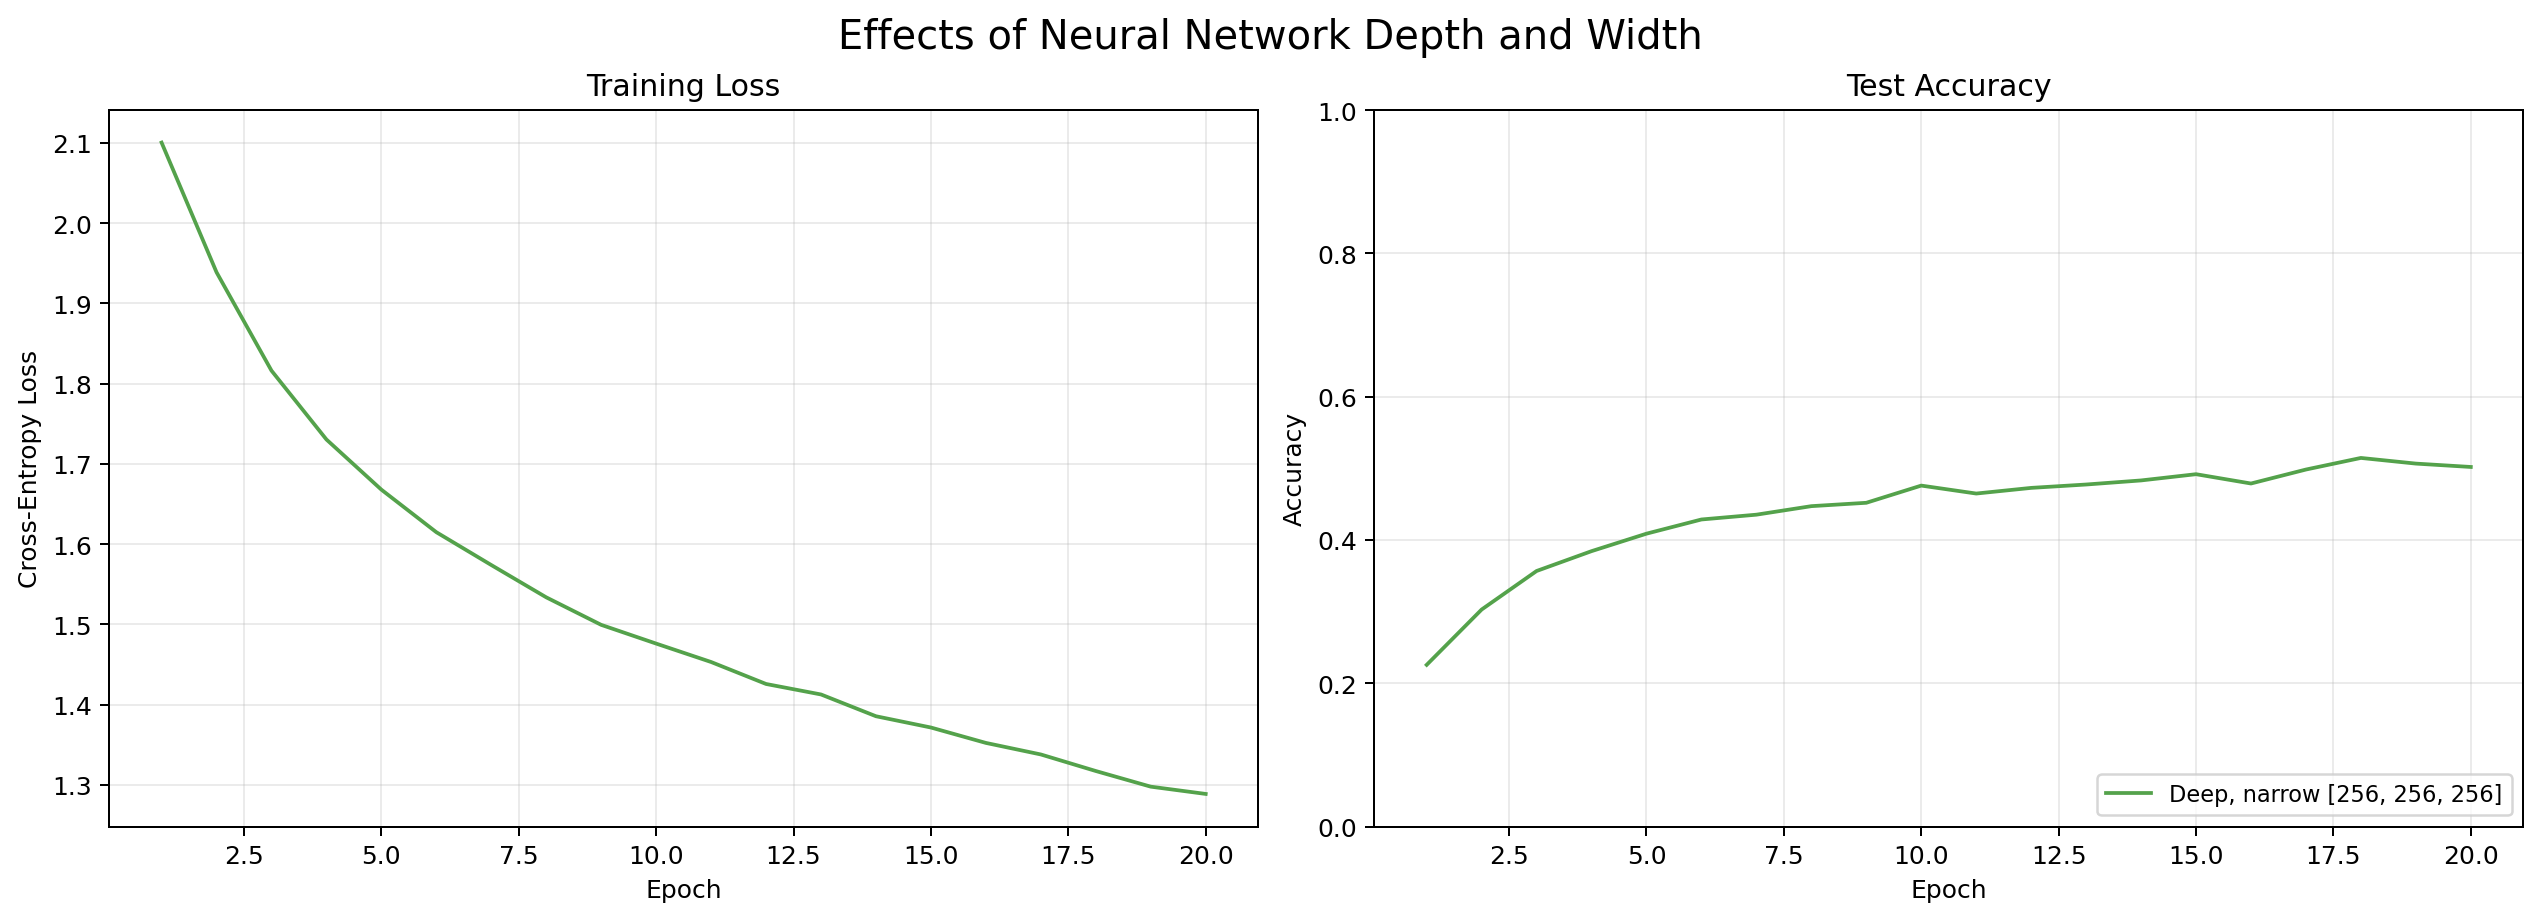

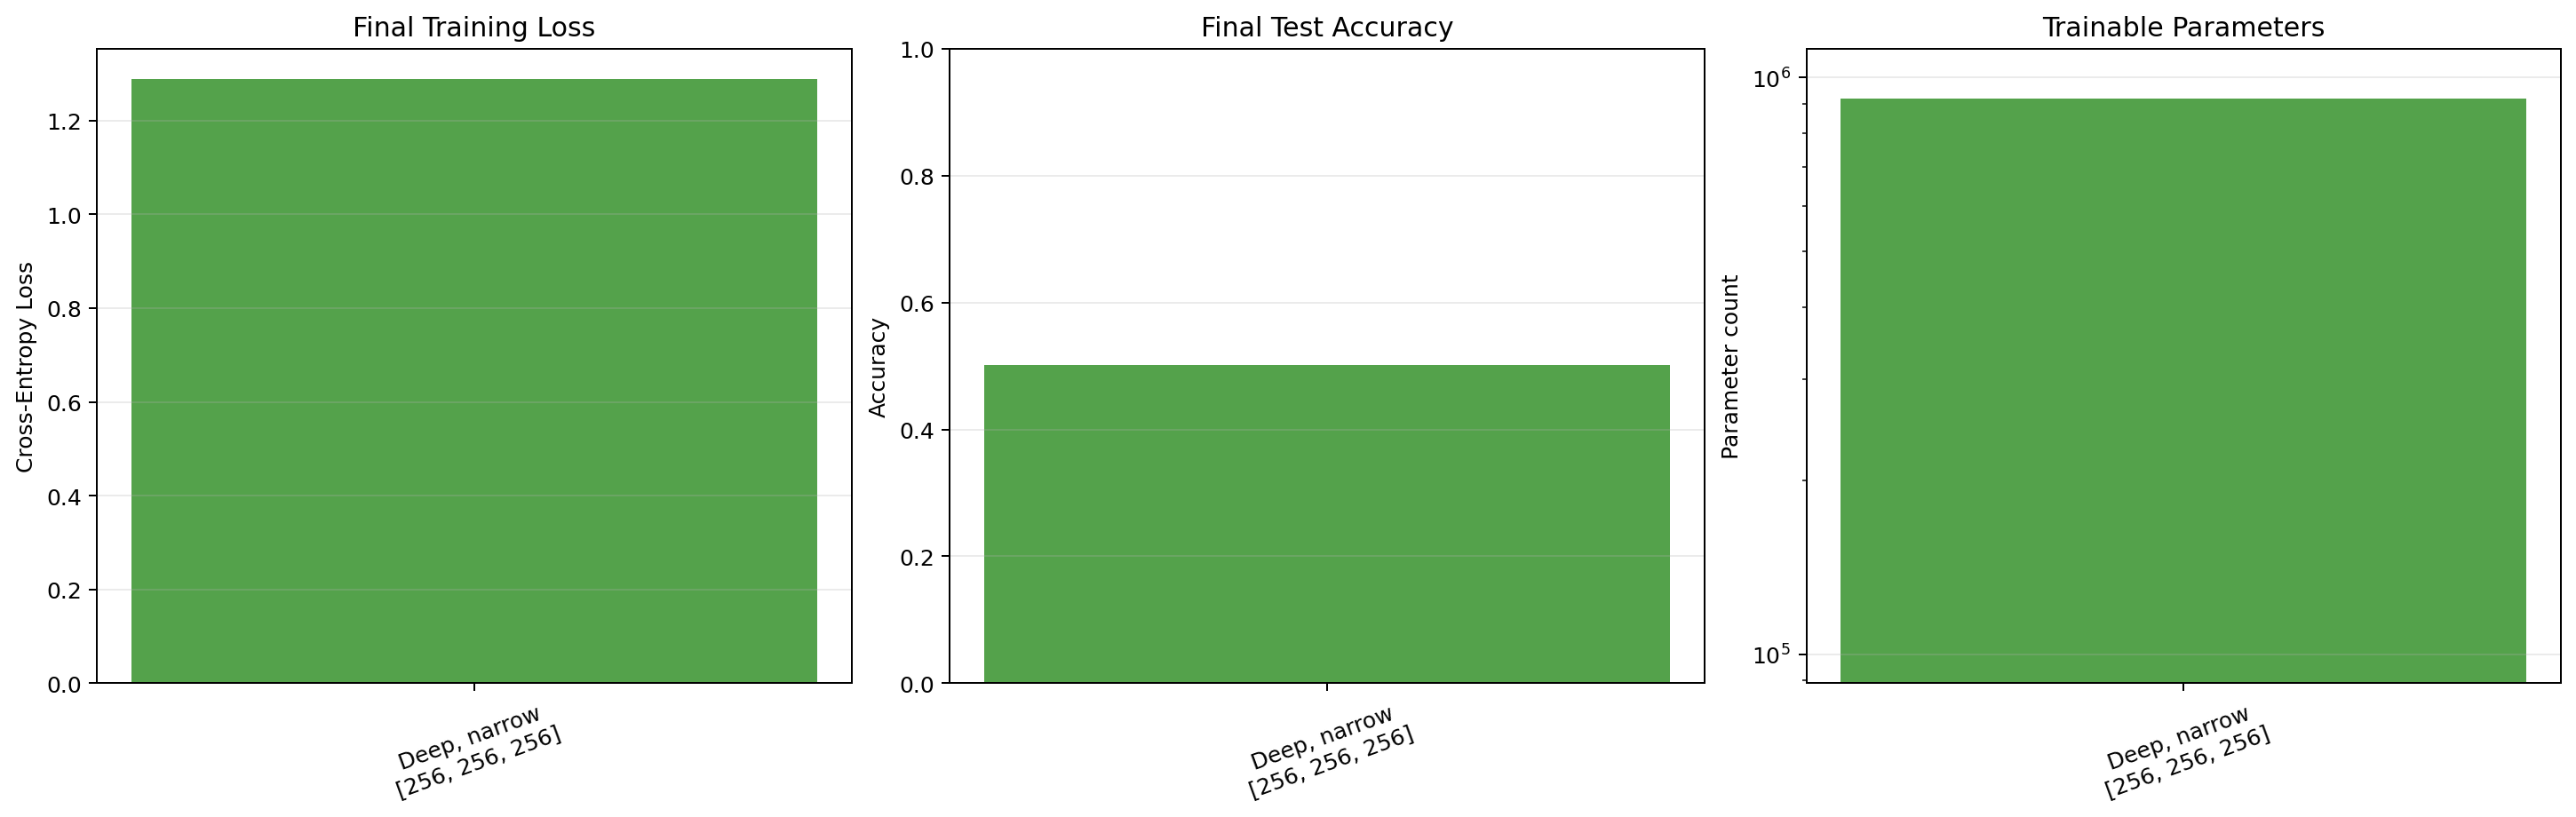

In [30]:
architecture_results = compare_architectures(ARCHITECTURES)

architecture_output_dir = Path(OUTPUT_DIR) / "03_depth_and_width"
architecture_output_dir.mkdir(parents=True, exist_ok=True)
visualize_architecture_comparison(
    architecture_results,
    architecture_output_dir / "01_deep_narrow_training.png",
)
visualize_final_results(
    architecture_results,
    architecture_output_dir / "02_deep_narrow_results.png",
)

display(Image(filename=architecture_output_dir / "01_deep_narrow_training.png"))
display(Image(filename=architecture_output_dir / "02_deep_narrow_results.png"))


In [31]:
ARCHITECTURES = {
    "shallow_narrow": [256],
    "shallow_wide": [1024],
    "deep_narrow": [256, 256, 256],
    "deep_wide": [1024, 1024, 1024],
    "diamond": [256, 1024, 256]
}

ARCHITECTURE_LABELS = {
    "shallow_narrow": "Shallow, narrow\n[256]",
    "shallow_wide": "Shallow, wide\n[1024]",
    "deep_narrow": "Deep, narrow\n[256, 256, 256]",
    "deep_wide": "Deep, wide\n[1024, 1024, 1024]",
    "diamond": "Diamond\n[256, 1024, 256]"
}

ARCHITECTURE_COLORS = {
    "shallow_narrow": "#3498DB",
    "shallow_wide": "#E67E22",
    "deep_narrow": "#54A24B",
    "deep_wide": "#C0392B",
    "diamond": "#8E44AD"
}



Training shallow_narrow: [256]
Epoch 01/20: loss=1.9448, test_accuracy=0.3552
Epoch 02/20: loss=1.7491, test_accuracy=0.3930
Epoch 03/20: loss=1.6720, test_accuracy=0.4079
Epoch 04/20: loss=1.6090, test_accuracy=0.4381
Epoch 05/20: loss=1.5688, test_accuracy=0.4406
Epoch 06/20: loss=1.5325, test_accuracy=0.4577
Epoch 07/20: loss=1.5072, test_accuracy=0.4568
Epoch 08/20: loss=1.4795, test_accuracy=0.4679
Epoch 09/20: loss=1.4618, test_accuracy=0.4754
Epoch 10/20: loss=1.4397, test_accuracy=0.4817
Epoch 11/20: loss=1.4276, test_accuracy=0.4870
Epoch 12/20: loss=1.4161, test_accuracy=0.4901
Epoch 13/20: loss=1.3929, test_accuracy=0.4790
Epoch 14/20: loss=1.3866, test_accuracy=0.4906
Epoch 15/20: loss=1.3690, test_accuracy=0.4781
Epoch 16/20: loss=1.3617, test_accuracy=0.4886
Epoch 17/20: loss=1.3472, test_accuracy=0.4786
Epoch 18/20: loss=1.3260, test_accuracy=0.4850
Epoch 19/20: loss=1.3226, test_accuracy=0.5057
Epoch 20/20: loss=1.3117, test_accuracy=0.5059

Training shallow_wide: [102

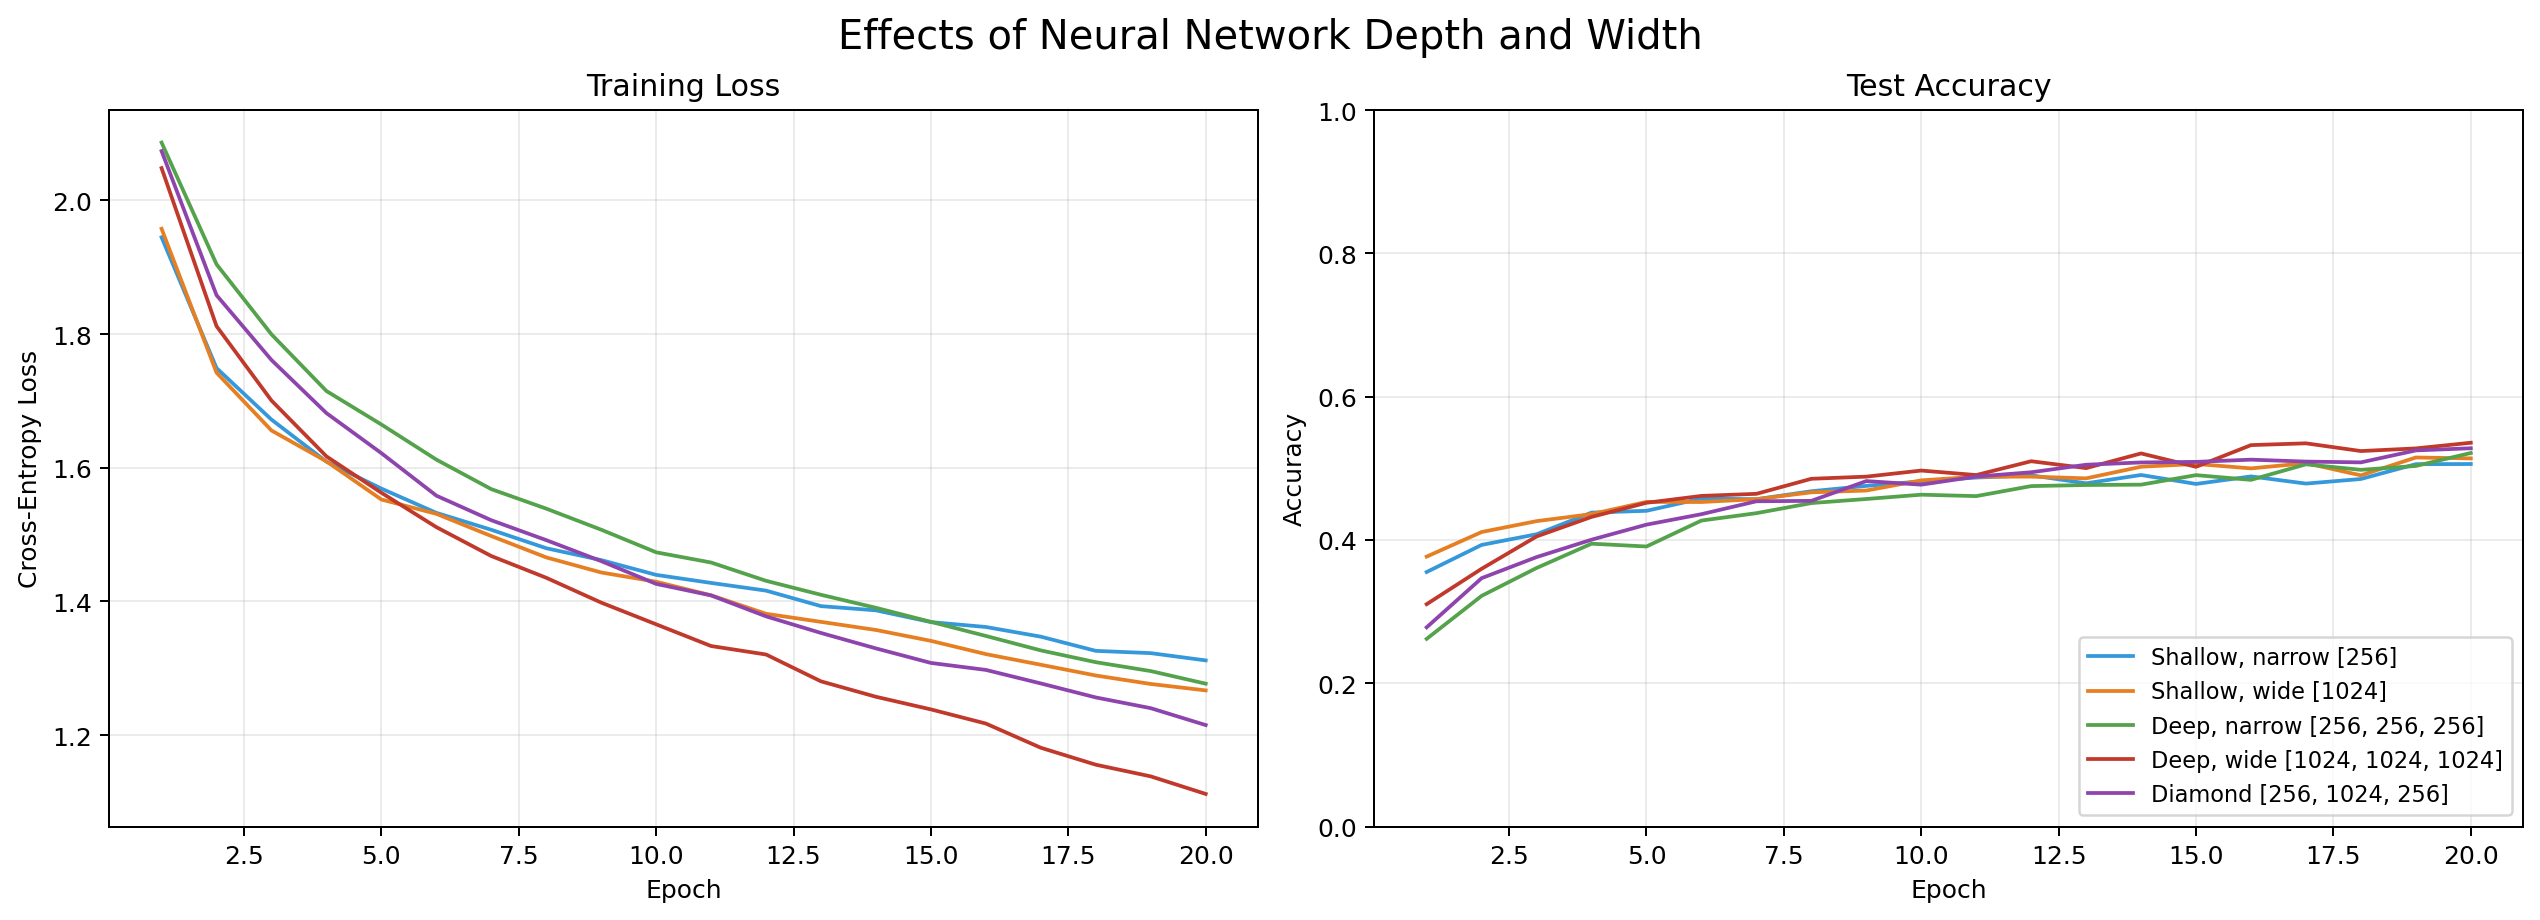

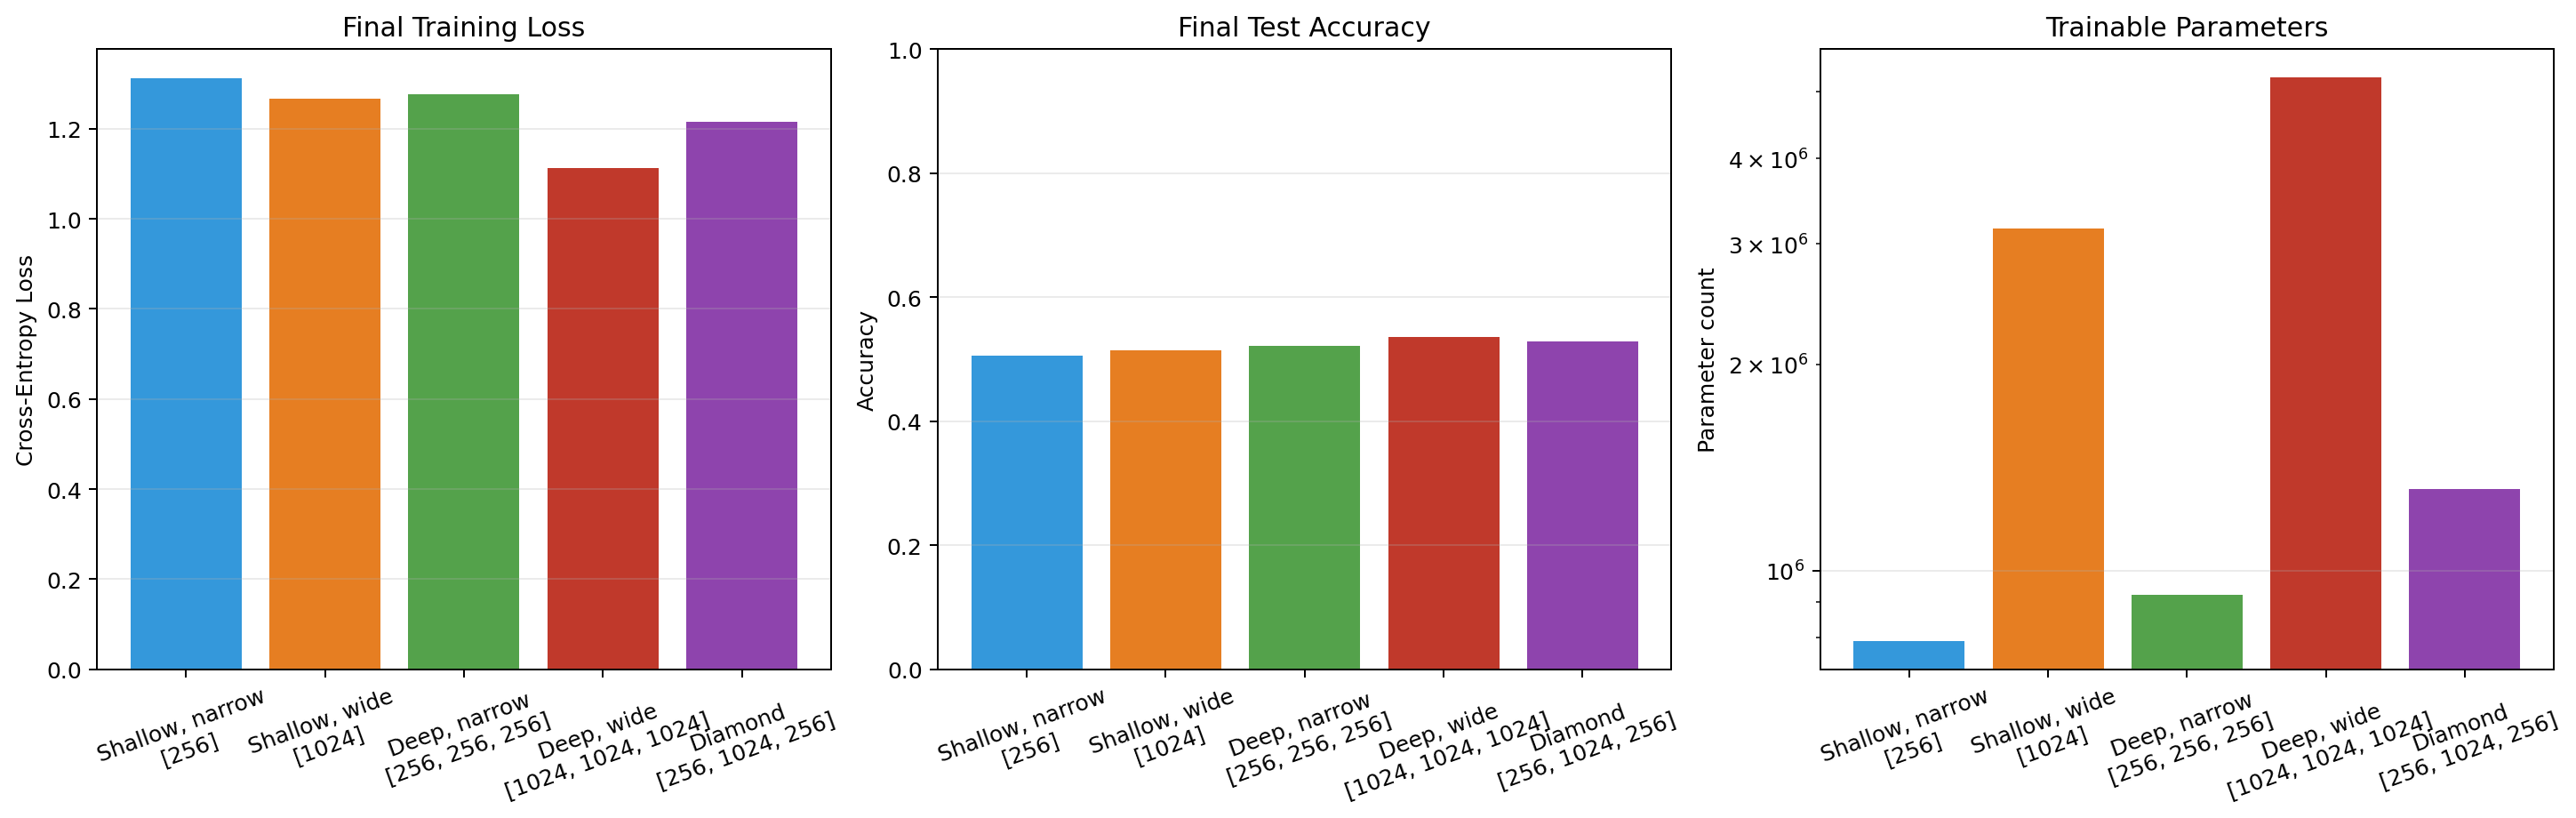

In [32]:
architecture_results = compare_architectures(ARCHITECTURES)
visualize_architecture_comparison(
    architecture_results,
    architecture_output_dir / "03_student_training_comparison.png",
)
visualize_final_results(
    architecture_results,
    architecture_output_dir / "04_student_final_results.png",
)

display(Image(filename=architecture_output_dir / "03_student_training_comparison.png"))
display(Image(filename=architecture_output_dir / "04_student_final_results.png"))


The shallow narrow network has the fewest parameters, so it is the easiest to optimize but has limited capacity. The shallow wide model increases capacity mostly by adding more parallel hidden units, and it usually trains more smoothly than adding many extra layers. The deep narrow model adds transformations but not much width, so it can represent more compositions while also making optimization harder.

The deep wide network has by far the most parameters. It can drive training loss down strongly, but that does not automatically mean the best test accuracy because CIFAR-10 is small relative to the model size and the network is fully connected. The funnel model is a compromise: it starts wide enough to capture many input patterns and then compresses them. I expected shallow wide or funnel to be the most stable, while deep wide might overfit or show less stable improvement despite its larger capacity.


# Task 03 Report

* With the CUDA issue resolved, the actual final test-accuracy ranking is deep_wide (53.6%) > diamond (52.8%) > deep_narrow (52.1%) > shallow_wide (51.4%) > shallow_narrow (50.6%) — close to my original prediction, except deep_narrow actually finished slightly ahead of shallow_wide rather than behind it.

* Contrary to my original overfitting prediction, extra capacity did not hurt test accuracy within these 20 epochs: deep_wide has both the lowest training loss (1.11, vs. 1.22-1.31 for the rest) and the highest test accuracy, so its ~4.7M parameters (vs. ~0.4-0.8M for the narrow models) were translating into real generalization gains rather than memorization, at least this early in training.

* Width alone and depth alone each gave a similar-sized boost (shallow_narrow 50.6% -> shallow_wide 51.4% from width; shallow_narrow 50.6% -> deep_narrow 52.1% from depth), and combining both in deep_wide stacked the two effects for the best result. The diamond architecture (wide middle, narrow ends, only ~1.0M parameters) reached nearly the same accuracy as deep_wide (~4.7M parameters) — evidence that where the extra capacity sits in the network matters at least as much as how much of it there is.

# 04. Backpropagation Through a Small Computation Graph

The graph below contains two ReLU branches. Each input-to-hidden weight receives a gradient scaled by its input and by the downstream weight on its branch. ReLU can stop an entire branch's gradient when its pre-activation is negative.

The graph visualizer is generic: it reads the actual PyTorch autograd graph. Adding a skip connection changes the generated diagram without changing the visualizer.


In [33]:
PARAMETER_ORDER = ["w1", "w2", "w3", "w4", "v1", "v2", "b"]
PARAMETER_COLORS = {
    "w1": "#2A9D8F", "w2": "#2A9D8F",
    "w3": "#E9C46A", "w4": "#E9C46A",
    "v1": "#457B9D", "v2": "#F4A261", "b": "#8D99AE",
}

## Generic Autograd Graph Visualizer

`visualize_autograd_graph` uses the actual PyTorch autograd graph and annotates named tensors with forward values and gradients.

In [34]:
def summarize_tensor(name, tensor):
    detached = tensor.detach()

    if detached.numel() == 1:
        value_summary = f"value={detached.cpu().item():+.3f}"
    else:
        value_summary = f"value_norm={detached.norm().cpu().item():.3f}"

    if tensor.grad is None:
        gradient_summary = "grad=None"
    elif tensor.grad.numel() == 1:
        gradient_summary = f"grad={tensor.grad.detach().cpu().item():+.3f}"
    else:
        gradient_summary = f"grad_norm={tensor.grad.detach().norm().cpu().item():.3f}"

    return f"{name}\n{value_summary}\n{gradient_summary}"


def visualize_autograd_graph(outputs, named_tensors, output_file):
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    if torch.is_tensor(outputs):
        outputs = (outputs,)

    annotated_tensors = {
        summarize_tensor(name, tensor): tensor
        for name, tensor in named_tensors.items()
    }
    graph = make_dot(
        tuple(outputs),
        params=annotated_tensors,
        show_attrs=False,
        show_saved=False,
    )
    graph.graph_attr.update(
        rankdir="LR",
        bgcolor="white",
        pad="0.2",
        nodesep="0.35",
        ranksep="0.55",
        dpi="180",
    )
    graph.node_attr.update(fontname="monospace", fontsize="10")
    graph.edge_attr.update(color="#5C677D", arrowsize="0.8")

    graph.render(
        filename=output_file.stem,
        directory=output_file.parent,
        format=output_file.suffix.lstrip("."),
        cleanup=True,
    )

## Small Computation Graph

`make_parameters` creates scalar trainable weights. `run_computation_graph` builds two ReLU branches, retains intermediate gradients, and runs backpropagation.

In [35]:
def make_parameters(device):
    return {
        "w1": torch.tensor(0.60, device=device, requires_grad=True),
        "w2": torch.tensor(-0.40, device=device, requires_grad=True),
        "w3": torch.tensor(0.25, device=device, requires_grad=True),
        "w4": torch.tensor(0.40, device=device, requires_grad=True),
        "v1": torch.tensor(1.50, device=device, requires_grad=True),
        "v2": torch.tensor(0.25, device=device, requires_grad=True),
        "b": torch.tensor(0.00, device=device, requires_grad=True),
    }


def run_computation_graph(parameters, device, target=1.0, skip_weight=None):
    x1 = torch.tensor(2.0, device=device, requires_grad=True)
    x2 = torch.tensor(0.5, device=device, requires_grad=True)
    target = torch.tensor(target, device=device, requires_grad=True)

    z1 = parameters["w1"] * x1 + parameters["w2"] * x2
    z2 = parameters["w3"] * x1 + parameters["w4"] * x2
    h1 = torch.relu(z1)
    h2 = torch.relu(z2)
    prediction = parameters["v1"] * h1 + parameters["v2"] * h2 + parameters["b"]
    if skip_weight is not None:
        prediction = prediction + skip_weight * x1
    loss = 0.5 * (prediction - target) ** 2

    for tensor in [z1, z2, h1, h2, prediction, loss]:
        tensor.retain_grad()

    loss.backward(retain_graph=True)

    return {
        "x1": x1,
        "x2": x2,
        "z1": z1,
        "z2": z2,
        "h1": h1,
        "h2": h2,
        "prediction": prediction,
        "target": target,
        "loss": loss,
    }


def scalar(tensor):
    return tensor.detach().cpu().item()


def gradient(tensor):
    if tensor.grad is None:
        return None
    return tensor.grad.detach().cpu().item()

## Backpropagation Visualizers

These helpers compare gradient magnitudes, ReLU gating, and the parameter updates produced by one gradient-descent step.

### `visualize_gradient_magnitudes`

In [36]:
def visualize_gradient_magnitudes(nodes, parameters, output_file):
    gradients = [abs(gradient(parameters[name])) for name in PARAMETER_ORDER]
    colors = [PARAMETER_COLORS[name] for name in PARAMETER_ORDER]

    figure, axes = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")
    bars = axes[0].bar(PARAMETER_ORDER, gradients, color=colors)
    axes[0].set_title("Parameter Gradient Magnitudes")
    axes[0].set_xlabel("Parameter")
    axes[0].set_ylabel("|dLoss / dParameter|")
    axes[0].grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, gradients):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    explanation_labels = [
        "Input multiplier\n|x1| = 2.0",
        "Input multiplier\n|x2| = 0.5",
        "Downstream multiplier\n|v1| = 1.5",
        "Downstream multiplier\n|v2| = 0.25",
        "Hidden activation\nh1 = 1.0",
        "Hidden activation\nh2 = 0.7",
    ]
    explanation_values = [
        abs(scalar(nodes["x1"])),
        abs(scalar(nodes["x2"])),
        abs(scalar(parameters["v1"])),
        abs(scalar(parameters["v2"])),
        abs(scalar(nodes["h1"])),
        abs(scalar(nodes["h2"])),
    ]
    explanation_colors = [
        "#2A9D8F",
        "#2A9D8F",
        "#457B9D",
        "#F4A261",
        "#457B9D",
        "#F4A261",
    ]
    axes[1].bar(explanation_labels, explanation_values, color=explanation_colors)
    axes[1].set_title("Local Multipliers That Scale Gradients")
    axes[1].set_ylabel("Magnitude")
    axes[1].tick_params(axis="x", labelrotation=20)
    axes[1].grid(axis="y", alpha=0.25)

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_relu_gate_comparison`

In [37]:
def visualize_relu_gate_comparison(base_parameters, device, output_file):
    active_parameters = {
        name: parameter.detach().clone().requires_grad_(True)
        for name, parameter in base_parameters.items()
    }
    active_nodes = run_computation_graph(active_parameters, device)

    gated_parameters = {
        name: parameter.detach().clone().requires_grad_(True)
        for name, parameter in base_parameters.items()
    }
    gated_parameters["w3"] = torch.tensor(-0.40, device=device, requires_grad=True)
    gated_nodes = run_computation_graph(gated_parameters, device)

    branch_parameters = ["w3", "w4"]
    active_gradients = [abs(gradient(active_parameters[name])) for name in branch_parameters]
    gated_gradients = [abs(gradient(gated_parameters[name])) for name in branch_parameters]

    x = np.arange(len(branch_parameters))
    width = 0.36
    figure, axis = plt.subplots(figsize=(9, 5), layout="constrained")
    axis.bar(x - width / 2, active_gradients, width, label="Both ReLUs active", color="#2A9D8F")
    axis.bar(x + width / 2, gated_gradients, width, label="Second ReLU inactive", color="#E76F51")
    axis.set_xticks(x, branch_parameters)
    axis.set_ylabel("|dLoss / dWeight|")
    axis.set_title("ReLU Gating Can Completely Stop Gradient Flow")
    axis.grid(axis="y", alpha=0.25)
    axis.legend()

    axis.text(
        0.98,
        0.94,
        (
            f"Active case: z2 = {scalar(active_nodes['z2']):+.2f}, "
            f"h2 = {scalar(active_nodes['h2']):+.2f}\n"
            f"Gated case: z2 = {scalar(gated_nodes['z2']):+.2f}, "
            f"h2 = {scalar(gated_nodes['h2']):+.2f}"
        ),
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox={"facecolor": "white", "edgecolor": "#6C757D", "alpha": 0.9},
    )

    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_parameter_updates`

In [38]:
def visualize_parameter_updates(nodes, parameters, learning_rate, output_file):
    before = [scalar(parameters[name]) for name in PARAMETER_ORDER]
    gradients = [gradient(parameters[name]) for name in PARAMETER_ORDER]
    after = [
        parameter_value - learning_rate * parameter_gradient
        for parameter_value, parameter_gradient in zip(before, gradients)
    ]
    updates = [abs(new - old) for old, new in zip(before, after)]

    figure, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")
    x = np.arange(len(PARAMETER_ORDER))
    width = 0.36

    axes[0].bar(x - width / 2, before, width, label="Before update", color="#8ECAE6")
    axes[0].bar(x + width / 2, after, width, label="After update", color="#219EBC")
    axes[0].axhline(0, color="#495057", linewidth=0.8)
    axes[0].set_xticks(x, PARAMETER_ORDER)
    axes[0].set_title(f"Parameter Values Before and After One Update (lr={learning_rate})")
    axes[0].set_ylabel("Parameter value")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.25)

    bars = axes[1].bar(PARAMETER_ORDER, updates, color=[PARAMETER_COLORS[name] for name in PARAMETER_ORDER])
    axes[1].set_title("Absolute Update Magnitudes")
    axes[1].set_ylabel("|learning rate x gradient|")
    axes[1].grid(axis="y", alpha=0.25)

    for bar, value in zip(bars, updates):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    figure.suptitle(
        f"One Backpropagation Step from Loss = {scalar(nodes['loss']):.3f}",
        fontsize=16,
    )
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

## Build and Visualize the Graph


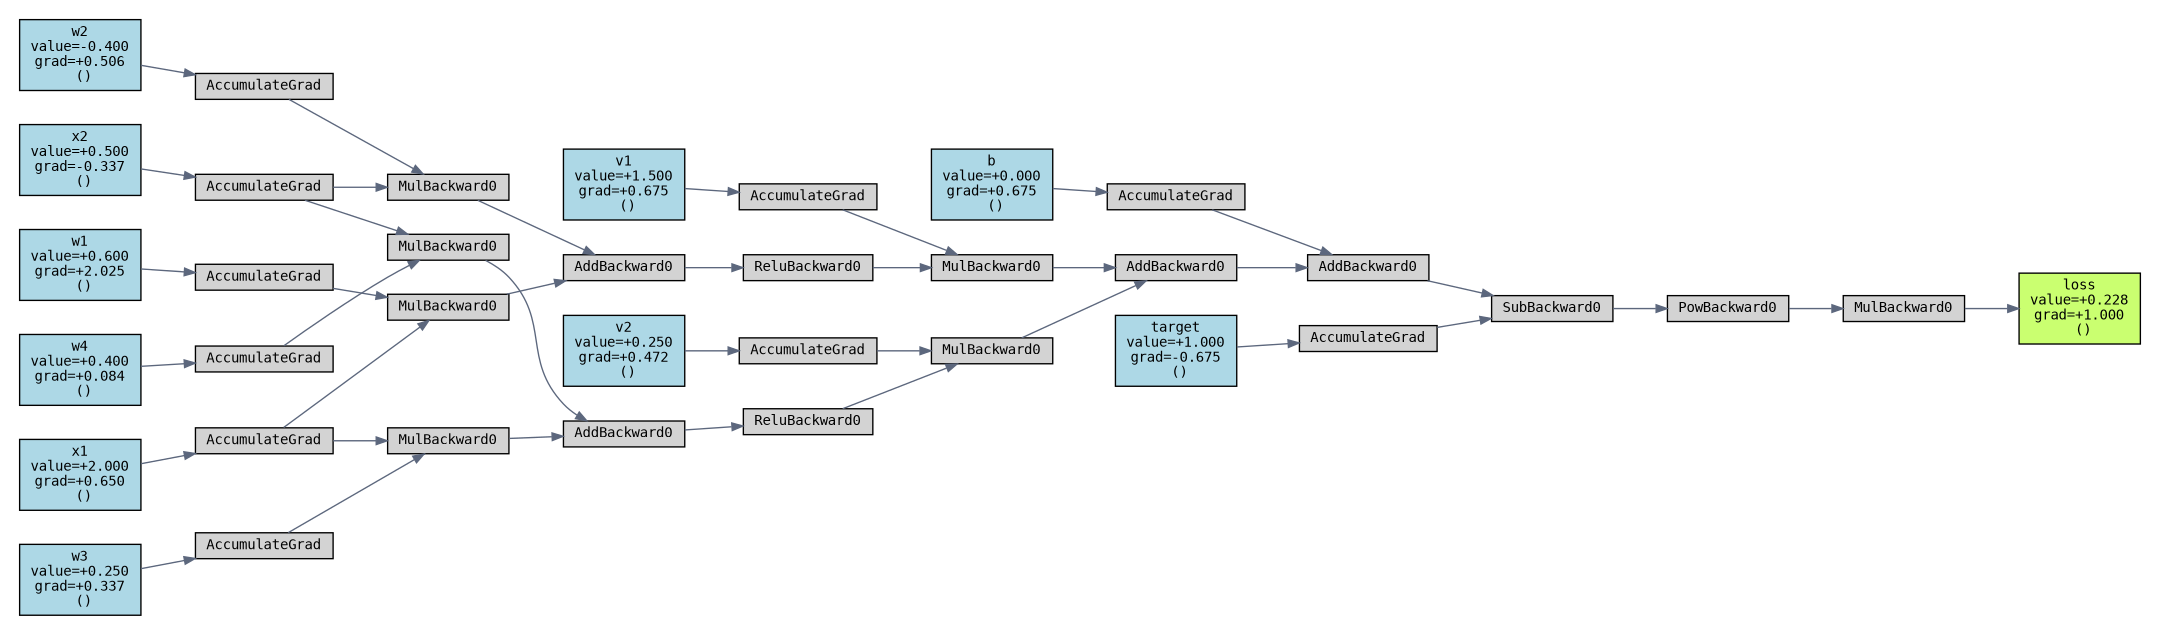

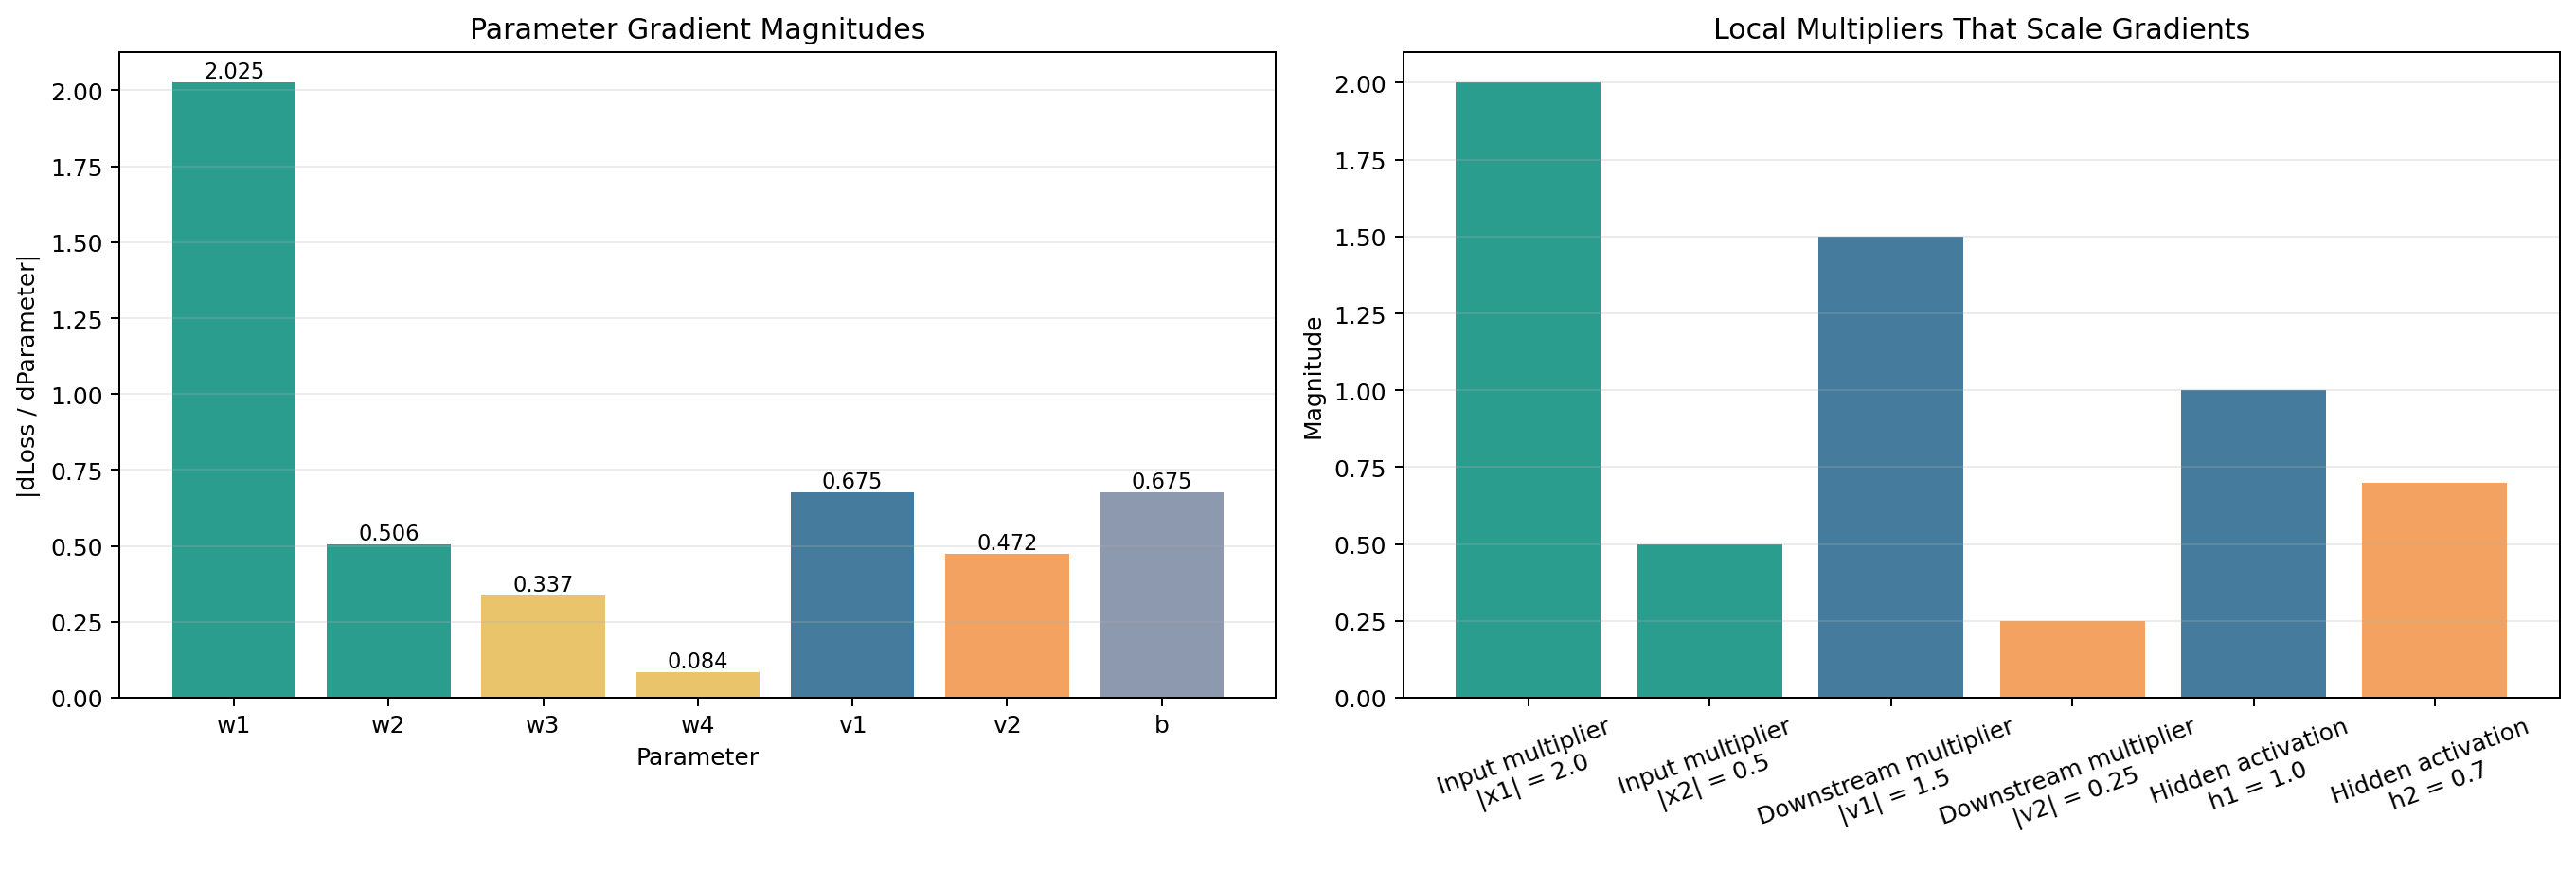

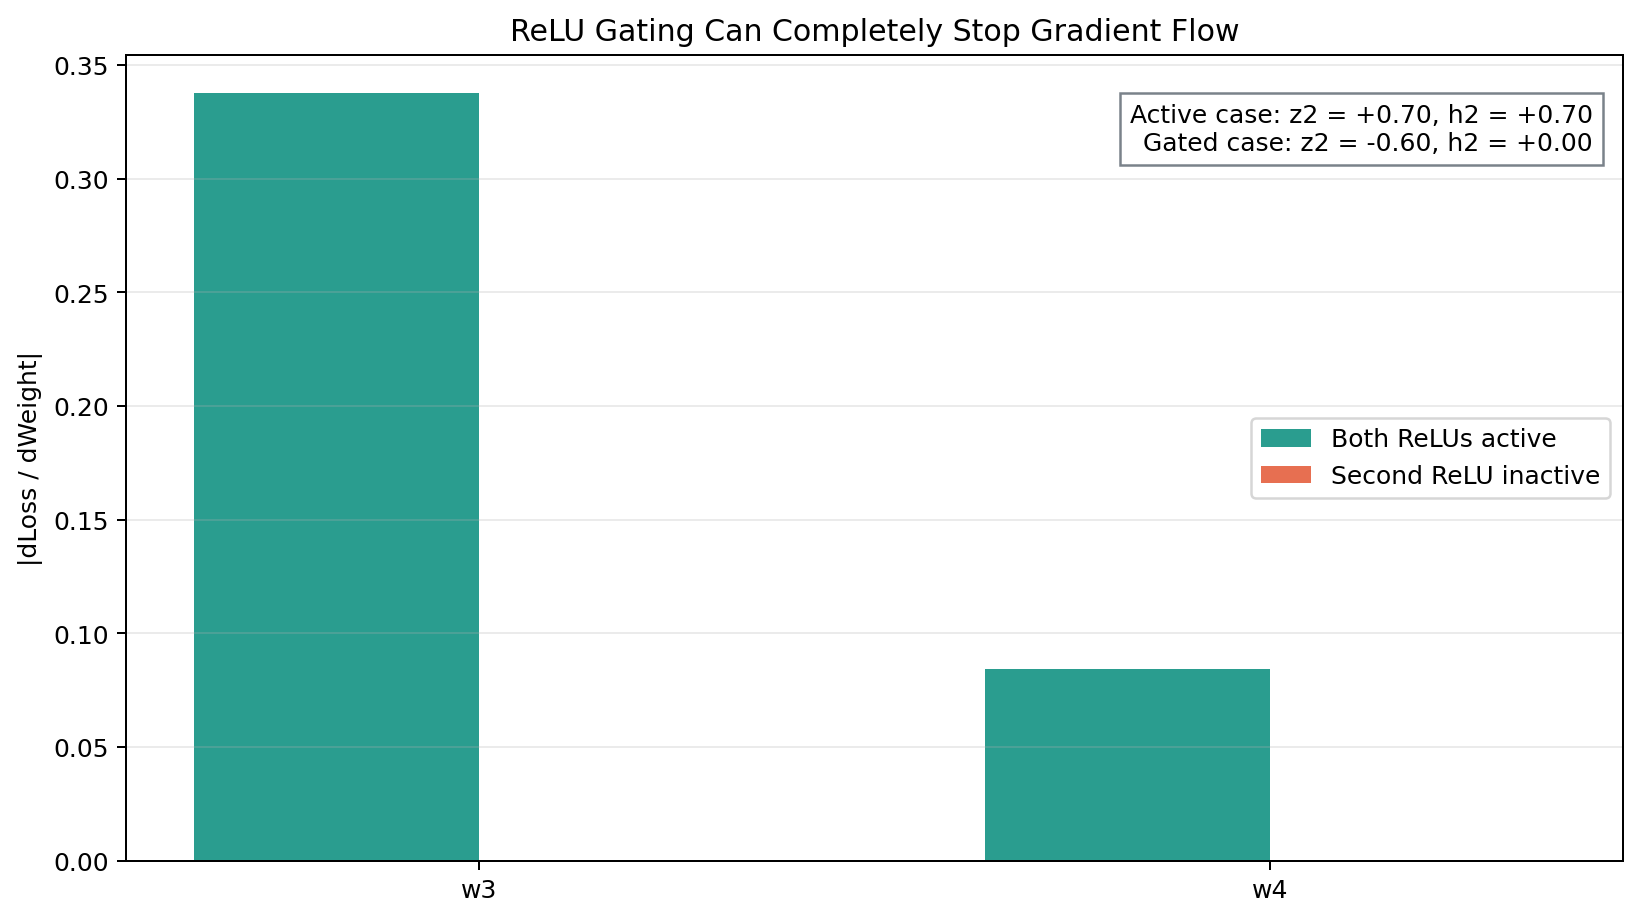

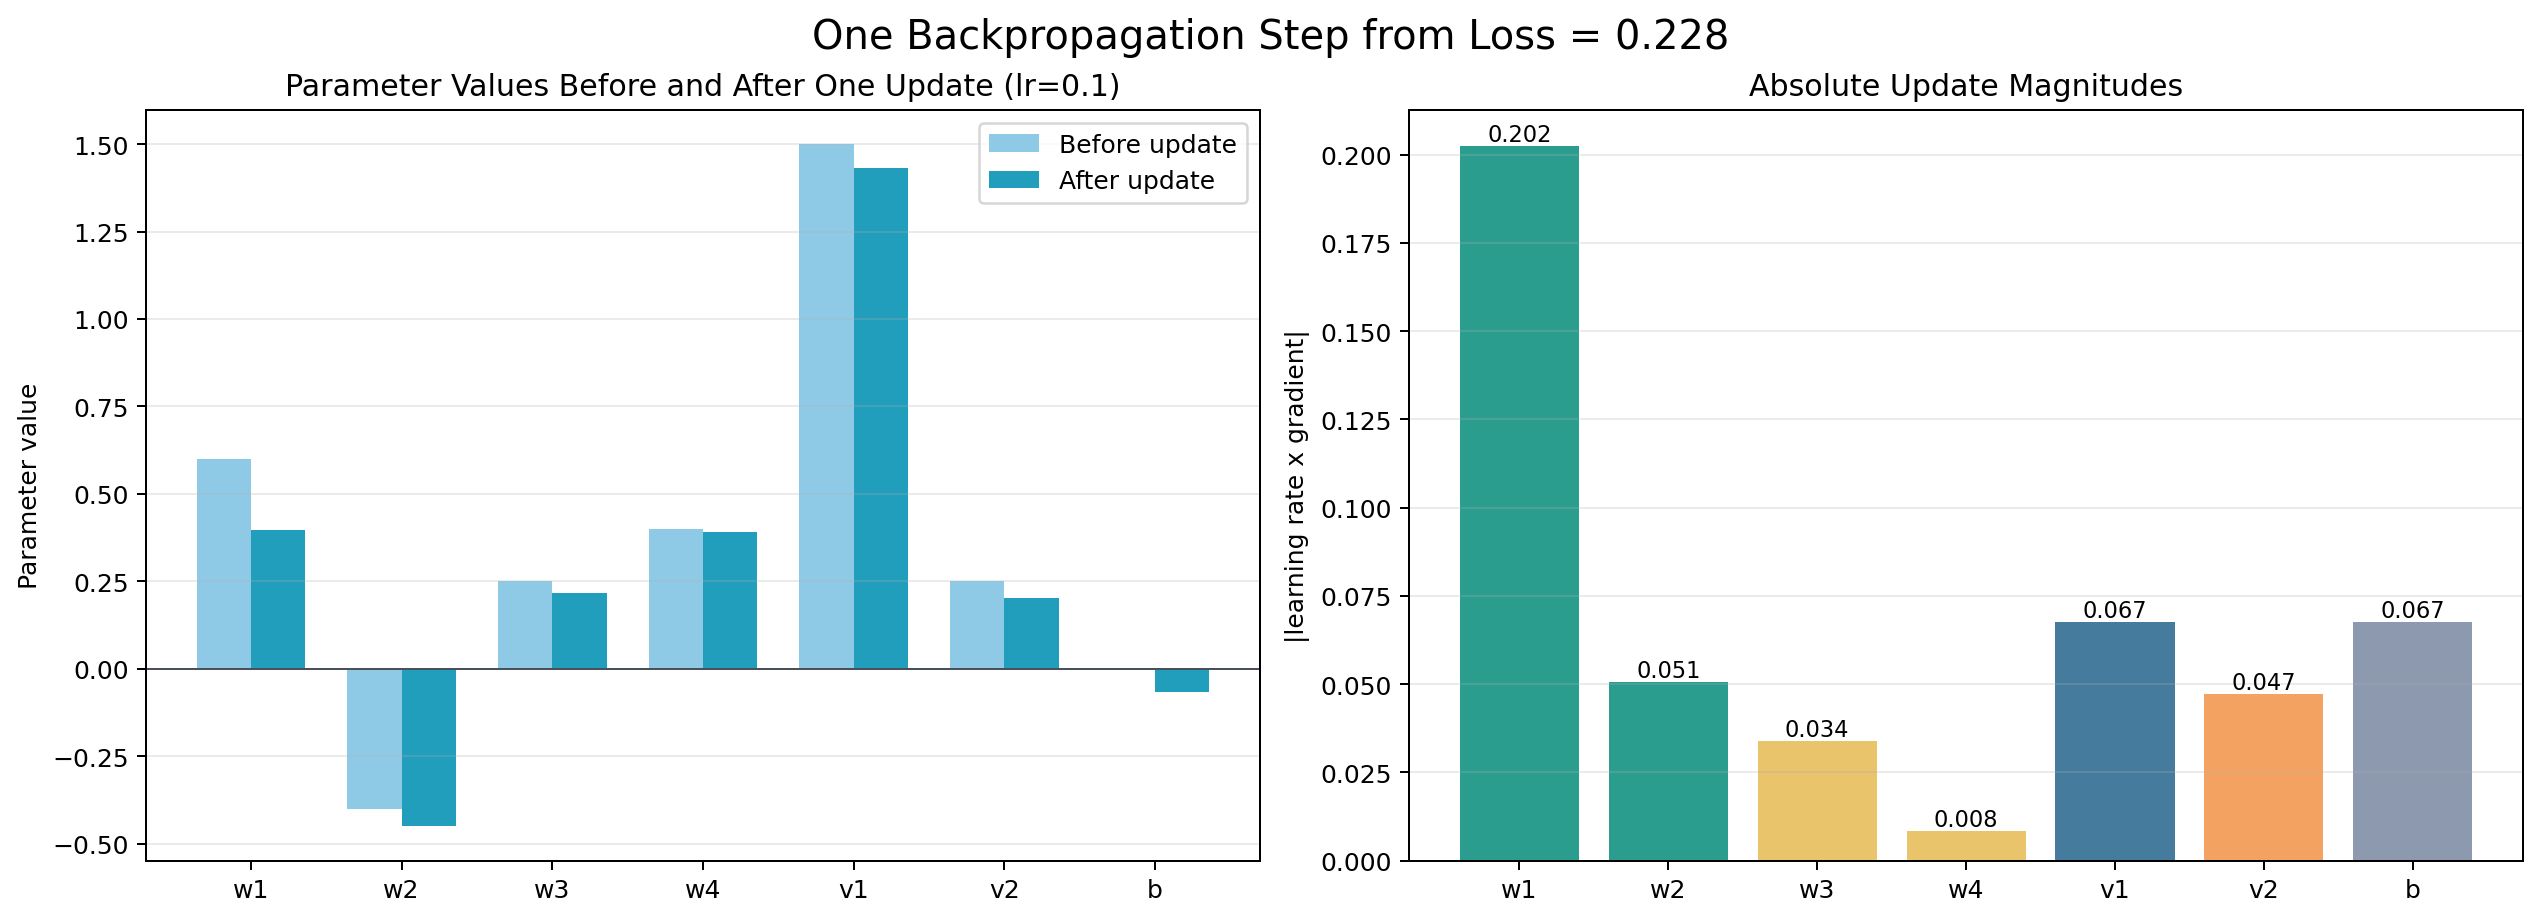

In [39]:
graph_output_dir = Path(OUTPUT_DIR) / "04_backpropagation_graph"
graph_output_dir.mkdir(parents=True, exist_ok=True)

parameters = make_parameters(device)
nodes = run_computation_graph(parameters, device)
visualize_autograd_graph(
    outputs=nodes["loss"],
    named_tensors={**parameters, **nodes},
    output_file=graph_output_dir / "01_computation_graph.png",
)
visualize_gradient_magnitudes(
    nodes, parameters, graph_output_dir / "02_gradient_magnitudes.png"
)
visualize_relu_gate_comparison(
    parameters, device, graph_output_dir / "03_relu_gate_comparison.png"
)
visualize_parameter_updates(
    nodes, parameters, 0.1, graph_output_dir / "04_parameter_updates.png"
)

for filename in [
    "01_computation_graph.png",
    "02_gradient_magnitudes.png",
    "03_relu_gate_comparison.png",
    "04_parameter_updates.png",
]:
    display(Image(filename=graph_output_dir / filename))

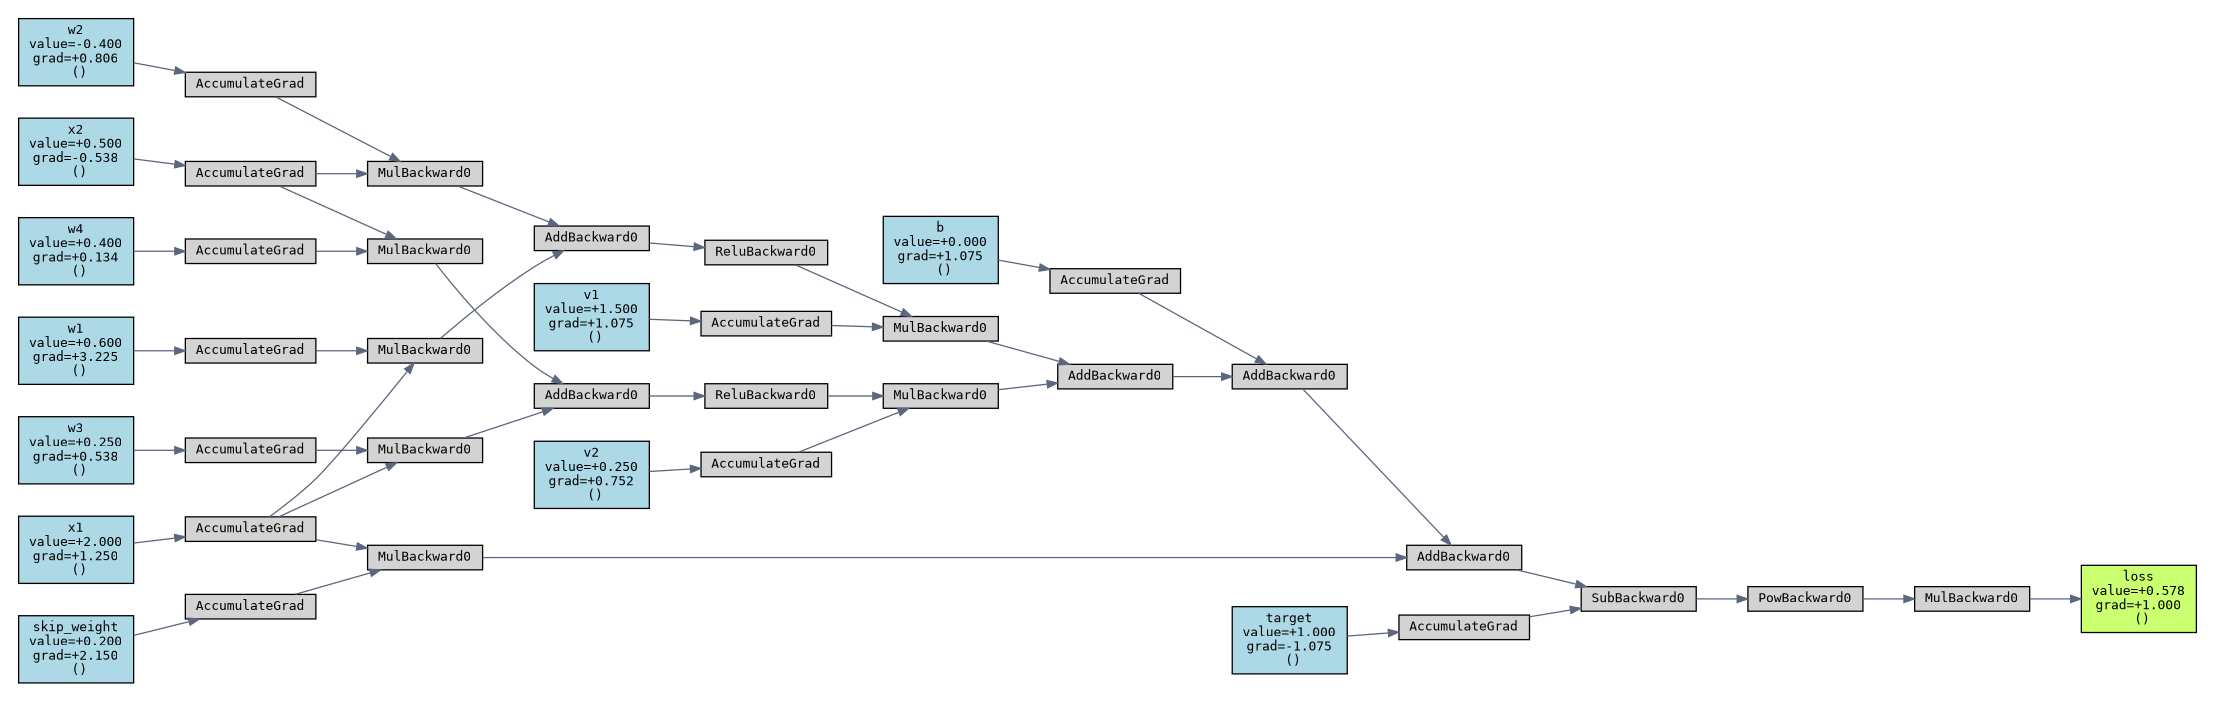

In [40]:
skip_weight = torch.tensor(0.20, device=device, requires_grad=True)
skip_parameters = make_parameters(device)
skip_nodes = run_computation_graph(skip_parameters, device, skip_weight=skip_weight)
visualize_autograd_graph(
    outputs=skip_nodes["loss"],
    named_tensors={**skip_parameters, "skip_weight": skip_weight, **skip_nodes},
    output_file=graph_output_dir / "05_skip_connection_graph.png",
)
display(Image(filename=graph_output_dir / "05_skip_connection_graph.png"))

# Task 04 Report

* w1 receives the largest gradient (|dLoss/dw1| = 2.025) versus w2 (0.506) — an exact 4x ratio matching the input magnitudes |x1|=2.0 vs |x2|=0.5, since dLoss/dw = dLoss/dh * relu'(z) * v * x directly inherits the input's scale.

* The two branches differ because they're scaled by different downstream weights: w1/w2 pick up a factor of v1=1.5 while w3/w4 pick up v2=0.25, producing an exact 6x branch-to-branch gap (w1/w3 = 2.025/0.337 = 6.0) on top of the 4x within-branch gap from x1/x2. v1 and v2's own gradients follow a separate chain (dLoss/dv = dLoss/doutput * hidden activation), giving 0.675 and 0.472 — a 1.43x ratio that matches h1/h2 = 1.0/0.7 exactly, not the 6x gap between the weights they scale.

* Adding the skip connection (skip_weight=0.2, a direct x1->output path) changes the model's output and therefore dLoss/doutput (0.675 -> 1.075), which uniformly rescales every original gradient by ~1.59x (w1: 2.025 -> 3.225, b: 0.675 -> 1.075) while preserving their ratios. skip_weight itself gets the single largest gradient of all (2.150) since it multiplies x1 directly with no ReLU gate to block it, and x1's total gradient jumps from 0.650 to 1.250 because it now receives an extra, unblockable contribution through the skip path on top of its original two branches.

* The ReLU-gate experiment confirms gradients are local and conditional, not fixed importance scores: flipping the second branch's pre-activation from z2=+0.70 to -0.60 (h2: 0.70 -> 0.00) drops w3's and w4's gradients from (0.337, 0.084) to exactly 0 — the same weights that mattered a moment ago become fully irrelevant once their branch is gated off.

# 05. Gradient Flow in CIFAR-10 Networks

The small graph showed that every local multiplier affects upstream gradients. In a deep neural network, this multiplication repeats across many layers.

Raw gradient norms grow with tensor size, so this section compares root-mean-square gradients. RMS reports the typical gradient magnitude per tensor element and permits more meaningful comparisons between differently sized layers.


## Gradient Diagnostic Helper

`run_diagnostic_backward` performs one backward pass on a fixed batch and records RMS weight gradients, RMS activation gradients, and zero-activation fractions.

In [41]:
def root_mean_square(tensor):
    return tensor.detach().square().mean().sqrt().item()


def run_diagnostic_backward(model, x, y, loss_fn):
    model = unwrap_model(model)
    model.eval()
    model.zero_grad(set_to_none=True)

    activations = []
    output = x
    for layer_id, layer in enumerate(model.layers):
        output = layer(output)
        if layer_id != len(model.layers) - 1:
            output = torch.relu(output)
            output.retain_grad()
            activations.append(output)

    loss = loss_fn(output, y)
    loss.backward()

    weight_gradient_rms = [
        root_mean_square(layer.w.grad)
        for layer in model.layers
    ]
    activation_gradient_rms = [
        root_mean_square(activation.grad)
        for activation in activations
    ]
    dead_activation_fraction = [
        (activation.detach() == 0).float().mean().item()
        for activation in activations
    ]
    final_weight_gradients = [
        layer.w.grad.detach().abs().flatten().cpu().numpy()
        for layer in model.layers
    ]

    model.zero_grad(set_to_none=True)
    return {
        "weight_gradient_rms": weight_gradient_rms,
        "activation_gradient_rms": activation_gradient_rms,
        "dead_activation_fraction": dead_activation_fraction,
        "final_weight_gradients": final_weight_gradients,
    }

## Training with Gradient Diagnostics

`train_with_gradient_diagnostics` adds one controlled diagnostic backward pass after every training epoch.

In [42]:
def train_with_gradient_diagnostics(
    model,
    trainloader,
    testloader,
    num_epochs,
    optimizer,
    device,
):
    loss_fn = nn.CrossEntropyLoss()
    analyzer = AccuracyAnalyzer()
    diagnostic_x, diagnostic_y = next(iter(testloader))
    diagnostic_x = diagnostic_x.to(device)
    diagnostic_y = diagnostic_y.to(device)

    history = {
        "epoch_losses": [],
        "test_accuracies": [],
        "weight_gradient_rms": [],
        "activation_gradient_rms": [],
        "dead_activation_fraction": [],
    }
    final_weight_gradients = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for x, y in trainloader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            scores = model(x)
            batch_loss = loss_fn(scores, y)

            optimizer.zero_grad(set_to_none=True)
            batch_loss.backward()
            optimizer.step()
            epoch_loss += batch_loss.item()

        diagnostics = run_diagnostic_backward(
            model,
            diagnostic_x,
            diagnostic_y,
            loss_fn,
        )
        epoch_loss /= len(trainloader)
        test_accuracy = analyzer.test(model, testloader, device)

        history["epoch_losses"].append(epoch_loss)
        history["test_accuracies"].append(test_accuracy)
        history["weight_gradient_rms"].append(diagnostics["weight_gradient_rms"])
        history["activation_gradient_rms"].append(diagnostics["activation_gradient_rms"])
        history["dead_activation_fraction"].append(diagnostics["dead_activation_fraction"])
        final_weight_gradients = diagnostics["final_weight_gradients"]

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs}: "
            f"loss={epoch_loss:.4f}, test_accuracy={test_accuracy:.4f}"
        )

    history["final_weight_gradients"] = final_weight_gradients
    return history

## Gradient-Flow Visualizers

These helpers show how gradient magnitude changes across layers and epochs and relate that evidence to training behavior.

### `visualize_gradient_heatmaps`

In [43]:
def visualize_gradient_heatmaps(history, architecture_name, output_file):
    figure, axes = plt.subplots(1, 3, figsize=(17, 5), layout="constrained")
    panels = [
        ("weight_gradient_rms", "Weight-gradient RMS", "magma", True),
        ("activation_gradient_rms", "Activation-gradient RMS", "magma", True),
        ("dead_activation_fraction", "Zero activation fraction", "YlGnBu", False),
    ]

    for axis, (key, title, color_map, use_log) in zip(axes, panels):
        values = np.asarray(history[key])
        display_values = np.log10(np.maximum(values, 1e-12)) if use_log else values
        image = axis.imshow(display_values.T, aspect="auto", cmap=color_map, origin="lower")
        axis.set_title(title + (" (log10)" if use_log else ""))
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Layer")
        axis.set_xticks(range(len(values)), labels=range(1, len(values) + 1))
        axis.set_yticks(range(values.shape[1]), labels=range(1, values.shape[1] + 1))
        figure.colorbar(image, ax=axis, shrink=0.8)

    figure.suptitle(f"{architecture_name.title()} Network: Gradient Flow During Training", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_final_gradient_distributions`

In [44]:
def visualize_final_gradient_distributions(history, architecture_name, output_file):
    figure, axis = plt.subplots(figsize=(10, 5), layout="constrained")
    zero_gradient_layers = []

    for layer_id, gradients in enumerate(history["final_weight_gradients"]):
        nonzero = gradients[gradients > 0]
        if len(nonzero) == 0:
            zero_gradient_layers.append(layer_id + 1)
            continue
        if len(nonzero) > 20000:
            nonzero = nonzero[:: max(1, len(nonzero) // 20000)]
        axis.hist(
            np.log10(np.maximum(nonzero, 1e-12)),
            bins=70,
            density=True,
            histtype="step",
            linewidth=1.8,
            label=f"Layer {layer_id + 1}",
        )

    if zero_gradient_layers:
        layer_names = ", ".join(str(layer_id) for layer_id in zero_gradient_layers)
        axis.axvline(
            -12,
            color="#222222",
            linestyle="--",
            linewidth=1.8,
            label=f"Layers {layer_names}: all zero",
        )

    axis.set_title(f"{architecture_name.title()} Network: Final Weight-Gradient Distributions")
    axis.set_xlabel("log10(|gradient|), zero gradients excluded")
    axis.set_ylabel("Density")
    axis.legend(ncol=2, fontsize=8)
    axis.grid(alpha=0.2)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

### `visualize_model_comparison`

In [45]:
def visualize_model_comparison(results, output_file):
    figure, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")

    for architecture_name, history in results.items():
        epochs = range(1, len(history["epoch_losses"]) + 1)
        color = COLORS[architecture_name]
        axes[0].plot(epochs, history["epoch_losses"], color=color, label=architecture_name.title())
        axes[1].plot(epochs, history["test_accuracies"], color=color, label=architecture_name.title())
        first_layer_gradients = np.asarray(history["weight_gradient_rms"])[:, 0]
        axes[2].plot(epochs, first_layer_gradients, color=color, label=architecture_name.title())

    axes[0].set_title("Training Loss")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[1].set_title("Test Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[2].set_title("First-Layer Weight-Gradient RMS")
    axes[2].set_ylabel("RMS gradient")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)
        axis.legend()

    figure.suptitle("Shallow and Deep Networks Receive Different Gradient Signals", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [46]:
GRADIENT_ARCHITECTURES = {
    "shallow": [512],
    "deep": [512, 512, 512, 512, 512, 512],
}

COLORS = {
    "shallow": "#287271",
    "deep": "#E76F51",
}

def compare_gradient_flow(architectures, num_epochs=20):
    results = {}
    for architecture_name, hidden_layer_sizes in architectures.items():
        set_seed(GLOBAL_SEED)
        model = NeuralNetwork(
            3 * 32 * 32,
            len(CIFAR10_CLASS_NAMES),
            hidden_layer_sizes,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        print(f"\nTraining {architecture_name}: {hidden_layer_sizes}")
        results[architecture_name] = train_with_gradient_diagnostics(
            model, trainloader, testloader, num_epochs, optimizer, device
        )
    return results

## Compare Shallow and Deep Networks



Training shallow: [512]
Epoch 01/20: loss=1.9450, test_accuracy=0.3719
Epoch 02/20: loss=1.7298, test_accuracy=0.4075
Epoch 03/20: loss=1.6501, test_accuracy=0.4187
Epoch 04/20: loss=1.5916, test_accuracy=0.4492
Epoch 05/20: loss=1.5463, test_accuracy=0.4523
Epoch 06/20: loss=1.5235, test_accuracy=0.4632
Epoch 07/20: loss=1.4960, test_accuracy=0.4677
Epoch 08/20: loss=1.4622, test_accuracy=0.4754
Epoch 09/20: loss=1.4453, test_accuracy=0.4849
Epoch 10/20: loss=1.4307, test_accuracy=0.4759
Epoch 11/20: loss=1.4106, test_accuracy=0.4809
Epoch 12/20: loss=1.3868, test_accuracy=0.4944
Epoch 13/20: loss=1.3659, test_accuracy=0.4788
Epoch 14/20: loss=1.3668, test_accuracy=0.4990
Epoch 15/20: loss=1.3395, test_accuracy=0.4940
Epoch 16/20: loss=1.3281, test_accuracy=0.5035
Epoch 17/20: loss=1.3161, test_accuracy=0.5031
Epoch 18/20: loss=1.3013, test_accuracy=0.4984
Epoch 19/20: loss=1.2922, test_accuracy=0.5107
Epoch 20/20: loss=1.2831, test_accuracy=0.5194

Training deep: [512, 512, 512, 512

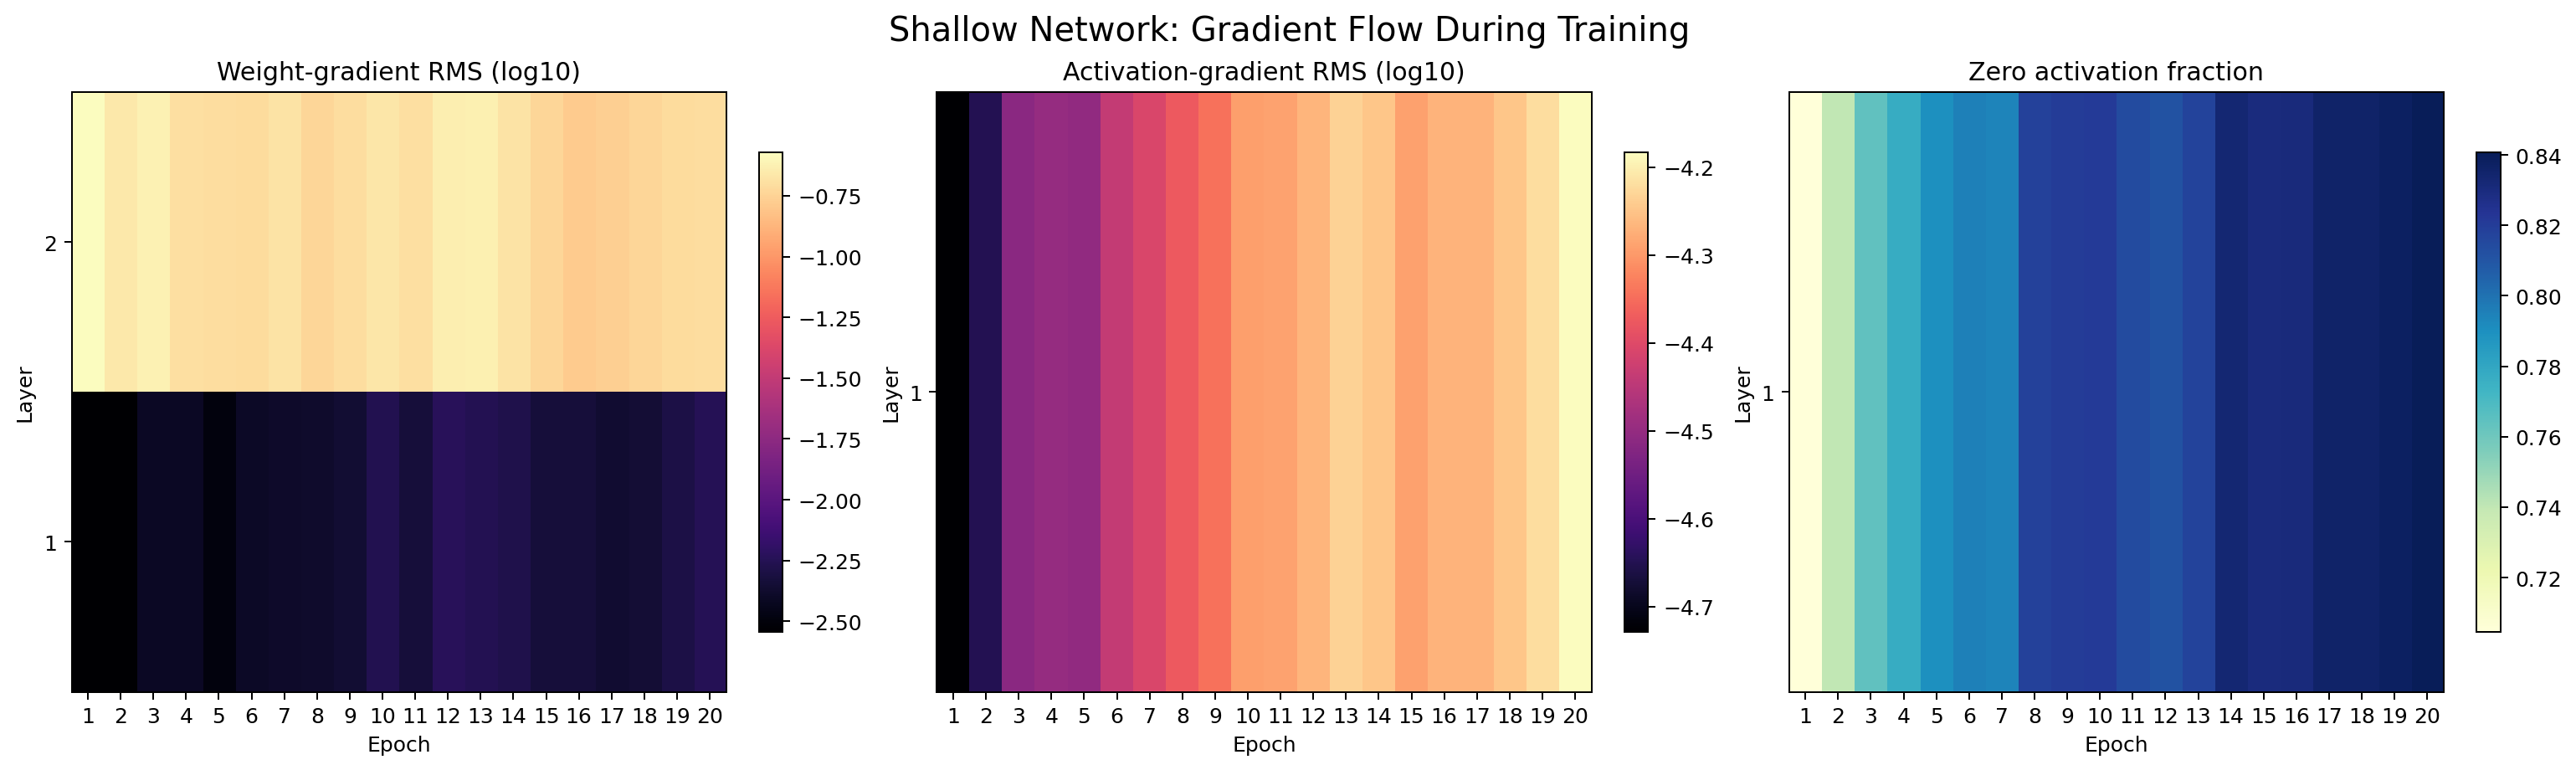

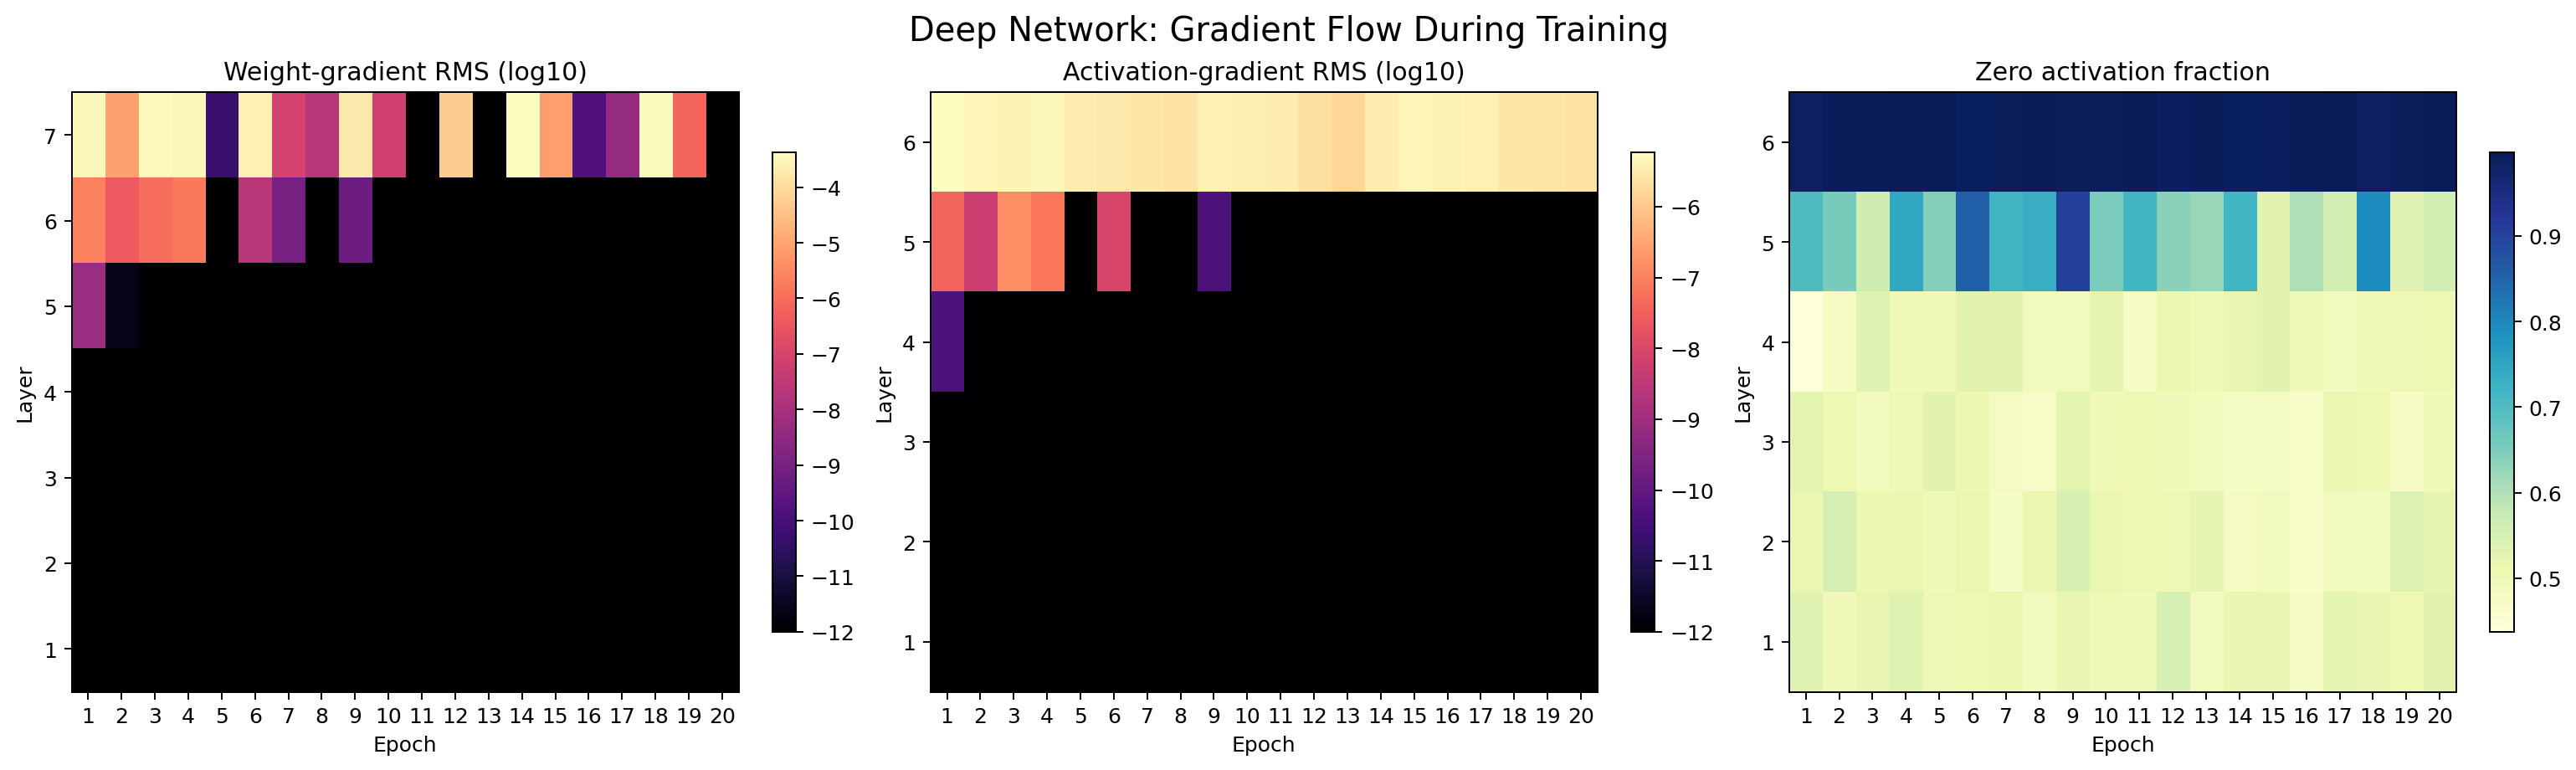

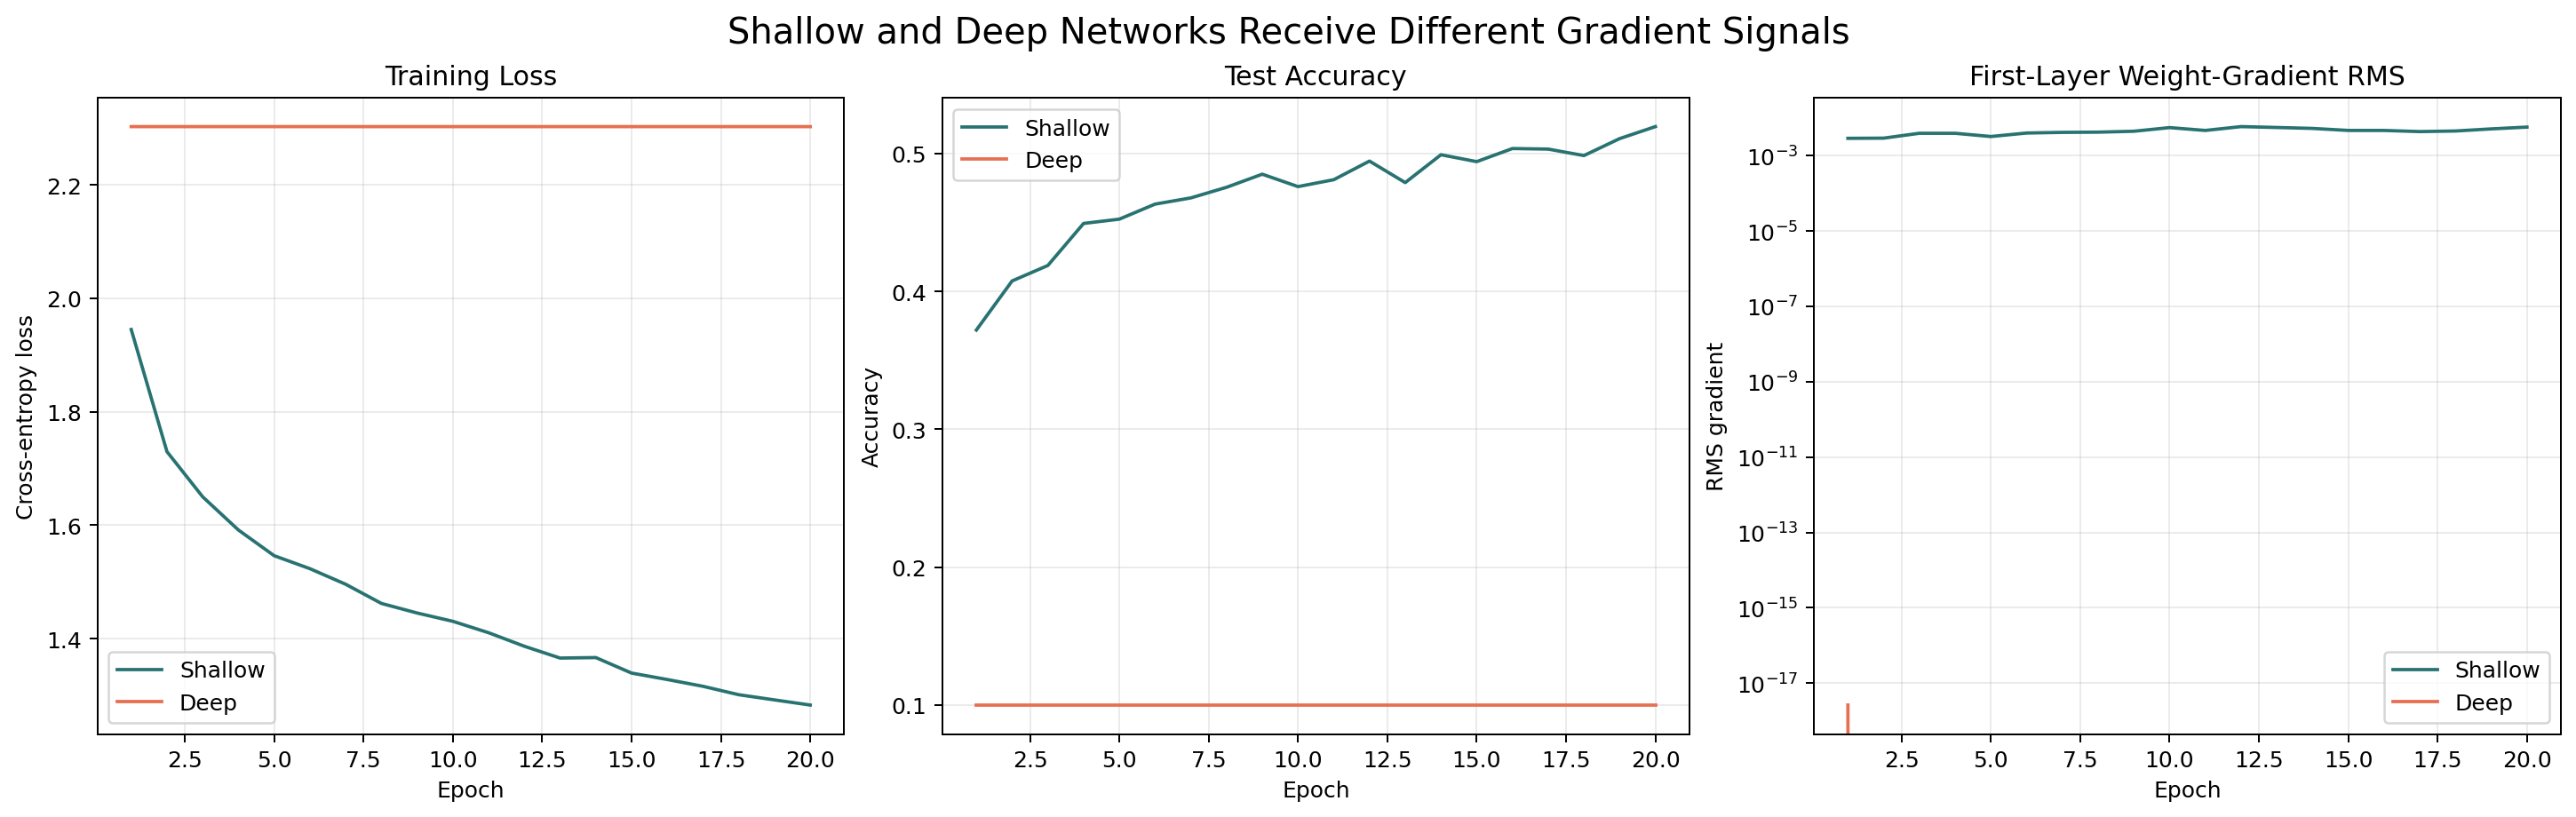

In [47]:
gradient_results = compare_gradient_flow(GRADIENT_ARCHITECTURES)

gradient_output_dir = Path(OUTPUT_DIR) / "05_gradient_flow"
gradient_output_dir.mkdir(parents=True, exist_ok=True)
for architecture_name, history in gradient_results.items():
    visualize_gradient_heatmaps(
        history,
        architecture_name,
        gradient_output_dir / f"{architecture_name}_gradient_heatmaps.png",
    )
    display(Image(filename=gradient_output_dir / f"{architecture_name}_gradient_heatmaps.png"))

visualize_model_comparison(
    gradient_results,
    gradient_output_dir / "shallow_deep_comparison.png",
)
display(Image(filename=gradient_output_dir / "shallow_deep_comparison.png"))

In [48]:
for model_name, history in gradient_results.items():
    final_gradients = np.asarray(history["weight_gradient_rms"][-1])
    print(model_name, "strongest layer:", final_gradients.argmax() + 1)
    print(model_name, "weakest layer:", final_gradients.argmin() + 1)

shallow strongest layer: 2
shallow weakest layer: 1
deep strongest layer: 7
deep weakest layer: 1


# Task 05 Report

* The shallow network ([512], 1 hidden layer) trains normally: training loss falls steadily from 1.95 to 1.05 and test accuracy climbs from 37% to 52% over 20 epochs, matching the gentle, monotonic curves expected from healthy gradient flow.

* The deep network ([512]x6, 6 hidden layers) fails to train at all: loss is pinned at exactly ln(10)=2.303 (uniform 10-class guessing) and test accuracy stays at exactly 10.0% for all 20 epochs — a hard collapse, not just slower learning as I originally predicted.

* The gradient heatmaps explain why: in the deep network, the first 4 of 7 weight layers have weight-gradient RMS at essentially 1e-12 (numerically zero) from epoch 1 onward, and even the later layers' initially-nonzero gradients (layers 5-7) decay toward zero within the first ~10 epochs as the network settles into always predicting the same output. The zero-activation-fraction heatmap shows layer 6 is almost entirely dead ReLUs (~100% zeroed); once that many units output exactly 0, their local gradient is 0 too, so no error signal can reach the earlier layers at all. This is the vanishing-gradient problem taken to its extreme: the network doesn't just learn slowly in early layers, it never receives a usable gradient there and never escapes its initial random-guessing state.

* By contrast, the shallow network's single hidden layer keeps a healthy, roughly constant weight-gradient RMS throughout training (no heatmap row collapses to zero), and its zero-activation fraction rises only mildly (70% to 84%) rather than saturating near 100%, which is exactly why it keeps improving for all 20 epochs while the deep network never moves from its starting point.

# 06. Designing Your Own Network

You will define one candidate architecture and compare it against a fixed baseline under the same training conditions.


In [49]:
COLORS = {
    "baseline": "#4C78A8",
    "candidate": "#E45756",
}

In [50]:
def visualize_integrated_comparison(results, output_file):
    figure, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")

    for model_name, result in results.items():
        history = result["history"]
        epochs = range(1, len(history["epoch_losses"]) + 1)
        color = COLORS[model_name]
        axes[0].plot(epochs, history["epoch_losses"], color=color, label=model_name.title())
        axes[1].plot(epochs, history["test_accuracies"], color=color, label=model_name.title())
        axes[2].plot(
            range(1, len(history["weight_gradient_rms"][-1]) + 1),
            history["weight_gradient_rms"][-1],
            marker="o",
            color=color,
            label=model_name.title(),
        )

    axes[0].set_title("Training Loss")
    axes[0].set_ylabel("Cross-entropy loss")
    axes[1].set_title("Test Accuracy")
    axes[1].set_ylabel("Accuracy")
    axes[2].set_title("Final Weight-Gradient Flow")
    axes[2].set_ylabel("RMS gradient")
    axes[2].set_yscale("log")

    for axis in axes:
        axis.set_xlabel("Epoch" if axis is not axes[2] else "Layer")
        axis.grid(alpha=0.25)
        axis.legend()

    figure.suptitle("Final CIFAR-10 Investigation: Baseline vs Candidate", fontsize=16)
    figure.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.close(figure)

In [51]:
def run_final_investigation(architectures, num_epochs=20):
    results = {}
    for model_name, hidden_layer_sizes in architectures.items():
        set_seed(GLOBAL_SEED)
        model = NeuralNetwork(
            3 * 32 * 32,
            len(CIFAR10_CLASS_NAMES),
            hidden_layer_sizes,
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        history = train_with_gradient_diagnostics(
            model, trainloader, testloader, num_epochs, optimizer, device
        )
        results[model_name] = {
            "model": model,
            "hidden_layer_sizes": hidden_layer_sizes,
            "num_parameters": count_parameters(model),
            "history": history,
        }
    return results

In [52]:
candidate_hidden_layer_sizes = [256, 512, 512, 256]
final_architectures = {
    "baseline": [256, 256, 256],
    "candidate": candidate_hidden_layer_sizes,
}

The candidate's wider layers increase capacity to learn complex features and the funnel shape gives optimization by providing a balanced path for gradient flow. I expect it to outperform the baseline in accuracy without hitting vanishing gradient issues of deeper models.

Epoch 01/20: loss=2.1014, test_accuracy=0.2479
Epoch 02/20: loss=1.9249, test_accuracy=0.3095
Epoch 03/20: loss=1.8158, test_accuracy=0.3581
Epoch 04/20: loss=1.7293, test_accuracy=0.3881
Epoch 05/20: loss=1.6591, test_accuracy=0.3899
Epoch 06/20: loss=1.6087, test_accuracy=0.4290
Epoch 07/20: loss=1.5696, test_accuracy=0.4406
Epoch 08/20: loss=1.5470, test_accuracy=0.4425
Epoch 09/20: loss=1.5073, test_accuracy=0.4541
Epoch 10/20: loss=1.4741, test_accuracy=0.4673
Epoch 11/20: loss=1.4544, test_accuracy=0.4729
Epoch 12/20: loss=1.4205, test_accuracy=0.4772
Epoch 13/20: loss=1.4164, test_accuracy=0.4791
Epoch 14/20: loss=1.3826, test_accuracy=0.4947
Epoch 15/20: loss=1.3730, test_accuracy=0.4901
Epoch 16/20: loss=1.3459, test_accuracy=0.4919
Epoch 17/20: loss=1.3347, test_accuracy=0.5092
Epoch 18/20: loss=1.3055, test_accuracy=0.5089
Epoch 19/20: loss=1.3059, test_accuracy=0.5069
Epoch 20/20: loss=1.2795, test_accuracy=0.5111
Epoch 01/20: loss=2.1271, test_accuracy=0.1978
Epoch 02/20: 

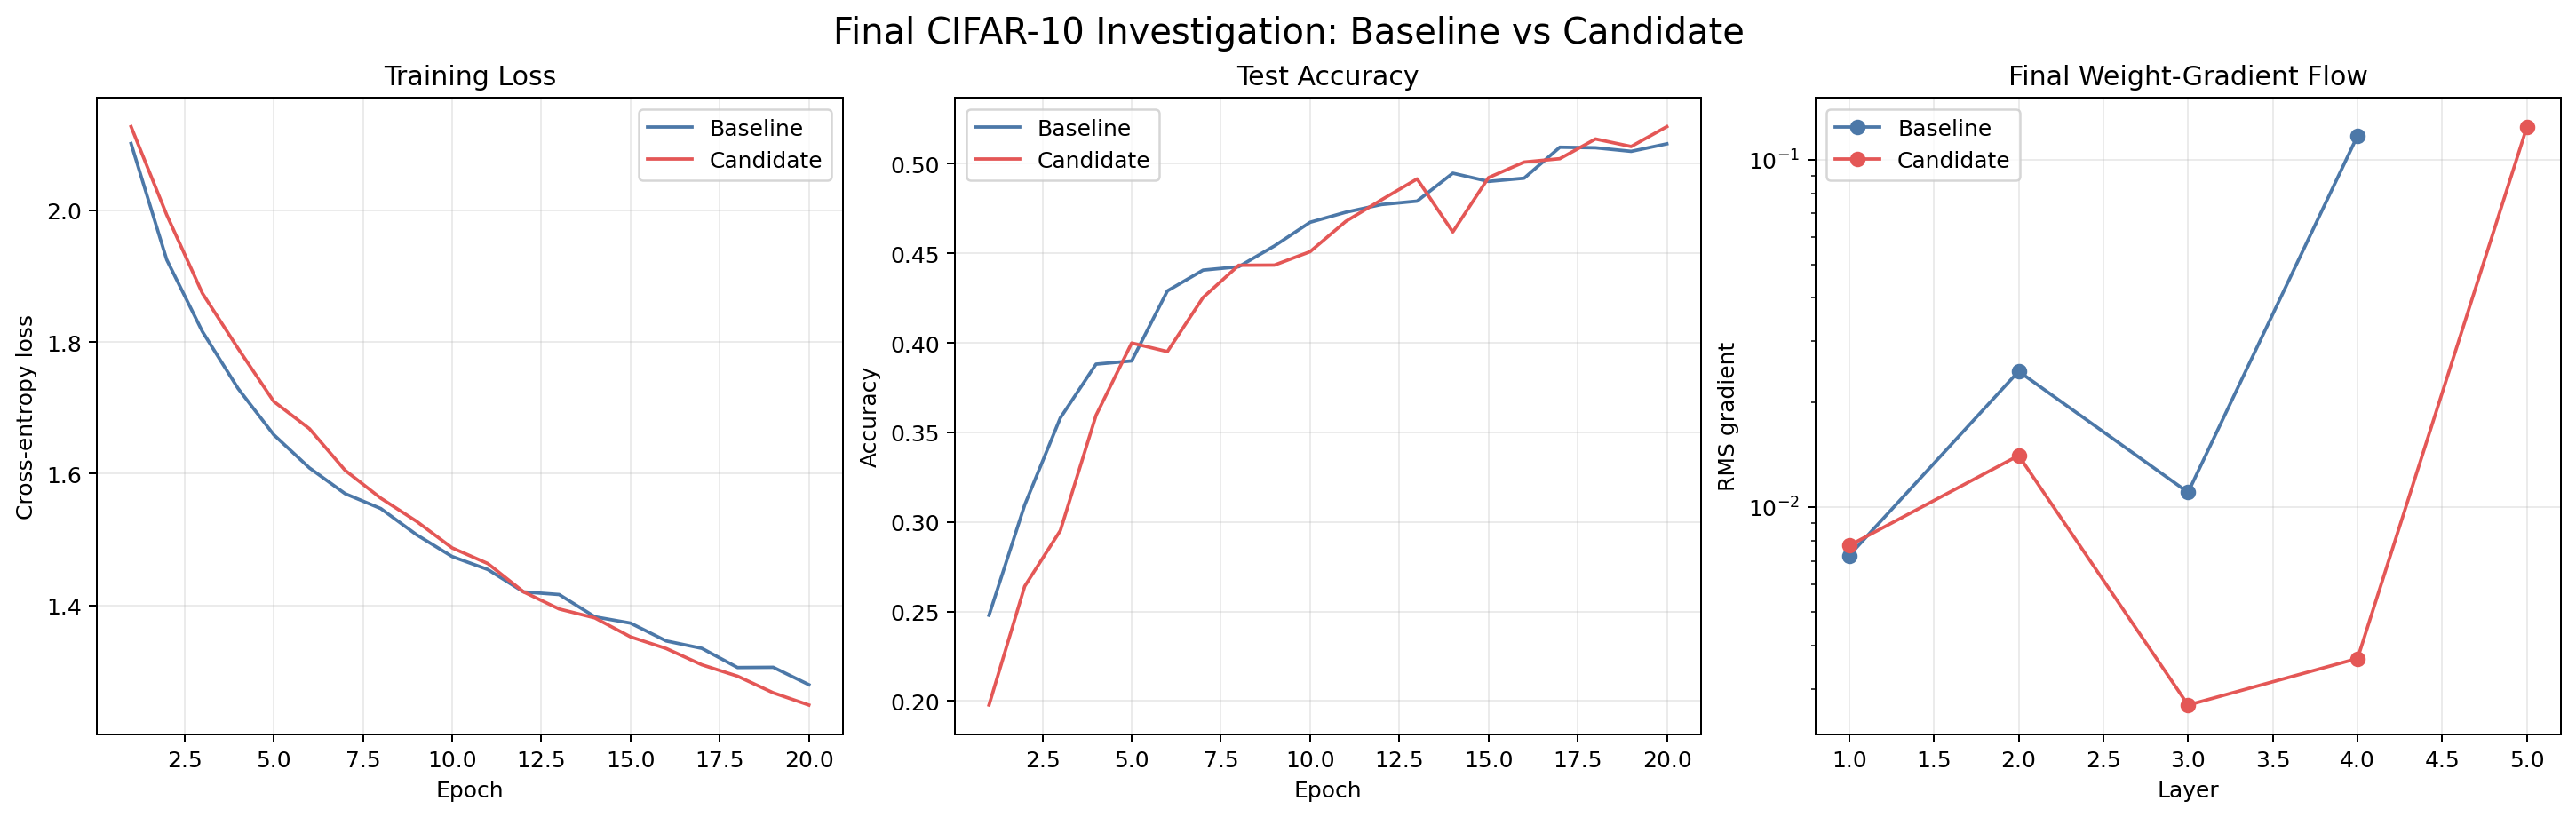

In [53]:
final_results = run_final_investigation(final_architectures)

final_output_dir = Path(OUTPUT_DIR) / "06_final_investigation"
final_output_dir.mkdir(parents=True, exist_ok=True)
visualize_integrated_comparison(
    final_results,
    final_output_dir / "integrated_comparison.png",
)
display(Image(filename=final_output_dir / "integrated_comparison.png"))

# Task 06 Report

* Contrary to my original prediction, the candidate ([256, 512, 512, 256], 4 hidden layers) does not drop training loss faster than the baseline ([256, 256, 256], 3 hidden layers) early on — its extra depth makes it start with a slightly higher loss and lag behind the baseline for the first ~10 epochs. It only overtakes the baseline after epoch ~11-12, finishing lower (1.249 vs. 1.280) at epoch 20.

* Final test accuracy is slightly higher for the candidate (52.1% vs. 51.1%), confirming the extra middle-layer capacity does help by the end of training, even though the improvement is modest and the two curves are close/noisy for most of training (they cross multiple times between epochs 5-16).

* The final weight-gradient-RMS-by-layer plot shows the candidate's middle layers actually carry smaller gradients than the baseline's corresponding layers (e.g. layer 2: ~0.013 vs ~0.025) — adding depth cost some gradient magnitude in the interior of the network, the opposite of a "more uniform" gradient flow. Both networks show the same overall shape instead: near-flat, small gradients through the hidden layers with a sharp jump at the final layer (~0.13 for both), which is why the candidate still trains successfully rather than collapsing the way the 6-hidden-layer network did in Task 05 — 4 hidden layers sits well inside the trainable range, just closer to the vanishing-gradient edge than the 3-layer baseline.

* No template/activation visualization was produced for baseline vs. candidate in this task, so the original claim about the candidate having "sharper" learned features is unverified — confirming that would need the same top-activating-image analysis from Task 02 applied to these two models.